# 1 Análise Exploratória dos Dados (Exploratory Data Analysis)
## Fonte
- `data/[aeroporto]_metar_[ano].parquet`: METAR decodificado no notebook `0_1`.
- `data/[aeroporto]_cgna_[ano].parquet`: movimentos de Congonhas, voo a voo, baixado pelo notebook `0_2`.


In [1]:
# pip install pandas
# pip install numpy
# pip install pyarrow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parametros

In [3]:
ANO = 2025
AEROPORTO = "cgh"
TZ = "America/Sao_Paulo"

SRC_CGNA = f"data/{str.lower(AEROPORTO)}_cgna_{ANO}.parquet"
SRC_METAR = F"data/{str.lower(AEROPORTO)}_metar_{ANO}.parquet"

OUT = f"data/{str.lower(AEROPORTO)}_taxi_features_{ANO}.parquet"

# Largura do bloco de horário, em minutos.
BLOCO_MIN = 30

# Rumo magnético das cabeceiras e declinação magnética (graus para oeste).
# O vento do METAR vem em graus verdadeiros.
QFU_MAG = {"17": 169, "35": 349}
DECL_W = 21

# Posições e tipos de aeronave com menos partidas que isto viram uma categoria só.
MIN_PARTIDAS = 50

# Companhia e data da mudança no registro da desocupação da posição.
GOL_REGISTRO_ANTIGO = "2025-02-01"

# Registro Aeronáutico Brasileiro (RAB).
RAB_URL = "https://sistemas.anac.gov.br/dadosabertos/Aeronaves/RAB/dados_aeronaves.csv"

#Estações do ano
ESTACAO_ANO = {12: "Verão", 1: "Verão", 2: "Verão", 3: "Outono", 4: "Outono", 5: "Outono",
           6: "Inverno", 7: "Inverno", 8: "Inverno", 9: "Primavera", 10: "Primavera", 11: "Primavera"}
ORDEM_ESTACAO_ANO = ["Verão", "Outono", "Inverno", "Primavera"]
CORES_ESTACAO_ANO = {"Verão": "#c0392b", "Outono": "#e67e22", "Inverno": "#1f4e79", "Primavera": "#27ae60"}



## 1.0 Leitura e janela de plausibilidade

A janela tira registros inconsistentes, não valores atípicos. A decolagem antes da
desocupação da posição e as repetições já saíram no download.

In [4]:
cgna = pd.read_parquet(SRC_CGNA)
metar = pd.read_parquet(SRC_METAR)

print(f"partidas no arquivo: {len(cgna)}")
print(f"mensagens METAR e SPECI: {len(metar)}")

partidas no arquivo: 92508
mensagens METAR e SPECI: 11410


In [5]:
# Janela de plausibilidade do tempo de táxi de saída, em minutos.
TAXI_MIN = 3
TAXI_MAX = 90

In [6]:
# Fica só quem está entre TAXI_MIN e TAXI_MAX minutos.
dentro_da_janela = (cgna["taxi_out"] >= TAXI_MIN) & (cgna["taxi_out"] <= TAXI_MAX)
print(f"fora da janela: {len(cgna) - dentro_da_janela.sum()}")
fora_da_janela = cgna[~dentro_da_janela].copy()
cgna = cgna[dentro_da_janela].copy()
cgna["log_taxi"] = np.log(cgna["taxi_out"])
print(f"partidas para análise: {len(cgna)}")
print("--------------------------------")
print(f"partidas fora da janela: {fora_da_janela.describe()}")

fora da janela: 27
partidas para análise: 92481
--------------------------------
partidas fora da janela:         taxi_out
count  27.000000
mean    1.409877
std     0.817468
min     0.166667
25%     0.808333
50%     1.316667
75%     2.066667
max     2.866667


### 1.0.1 - Colunas do dataframe do CGNA

- `taxi_out`: tempo de táxi de saída, em minutos (diferença entre ATOT e AOBT).
- `indicativo`: indicativo de chamada do voo. As 3 primeiras letras são o código da companhia.
- `pista`: pista da decolagem, com o L ou R (17R, 35L, 17L, 35R).
- `box`: posição de estacionamento de onde a aeronave saiu.
- `AOBT`: hora de desocupação da posição de estacionamento, em UTC.
- `ATOT`: hora de decolagem, em UTC.
- `companhia`: código ICAO da companhia aérea (ex.: GLO, TAM, AZU).
- `matricula`: matrícula da aeronave, sem hífen (ex.: PRXBM).

Os horários vêm em UTC. Para a análise por dia e por hora, será convertido para o horário de Brasília.

In [7]:
cgna.info()

<class 'pandas.DataFrame'>
Index: 92481 entries, 0 to 92507
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   taxi_out    92481 non-null  float64            
 1   indicativo  92481 non-null  str                
 2   pista       92481 non-null  category           
 3   box         92481 non-null  category           
 4   AOBT        92481 non-null  datetime64[ms, UTC]
 5   ATOT        92481 non-null  datetime64[ms, UTC]
 6   companhia   92481 non-null  category           
 7   matricula   92481 non-null  category           
 8   log_taxi    92481 non-null  float64            
dtypes: category(4), datetime64[ms, UTC](2), float64(2), str(1)
memory usage: 5.3 MB


#### 1.0.1.1 Distribuição da variável taxi_out

In [8]:
cgna["taxi_out"].describe().round(2)

count    92481.00
mean        14.72
std          5.19
min          3.07
25%         11.03
50%         13.68
75%         17.35
max         76.22
Name: taxi_out, dtype: float64

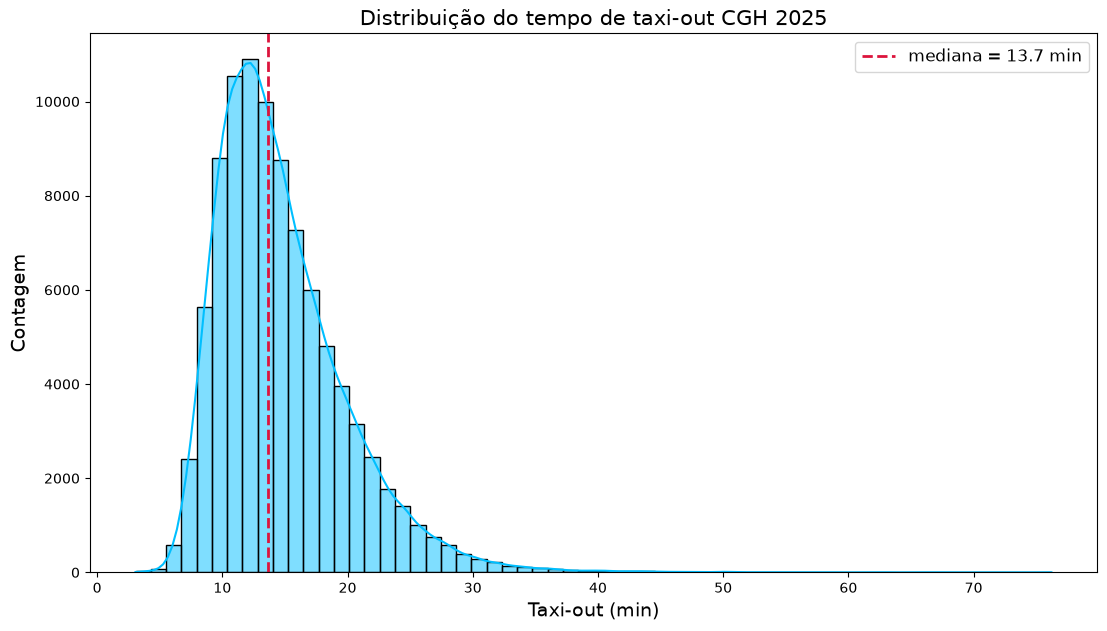

In [9]:
plt.figure(figsize=(13, 7))
sns.histplot(cgna["taxi_out"], kde=True, bins=60, color="deepskyblue")
plt.axvline(cgna["taxi_out"].median(), color="crimson", ls="--", lw=2,
            label=f"mediana = {cgna['taxi_out'].median():.1f} min")
plt.xlabel("Taxi-out (min)", fontsize=14)
plt.ylabel("Contagem", fontsize=14)
plt.title(f"Distribuição do tempo de taxi-out {AEROPORTO.upper()} {ANO}", fontsize=15)
plt.legend(fontsize=12)
plt.show()

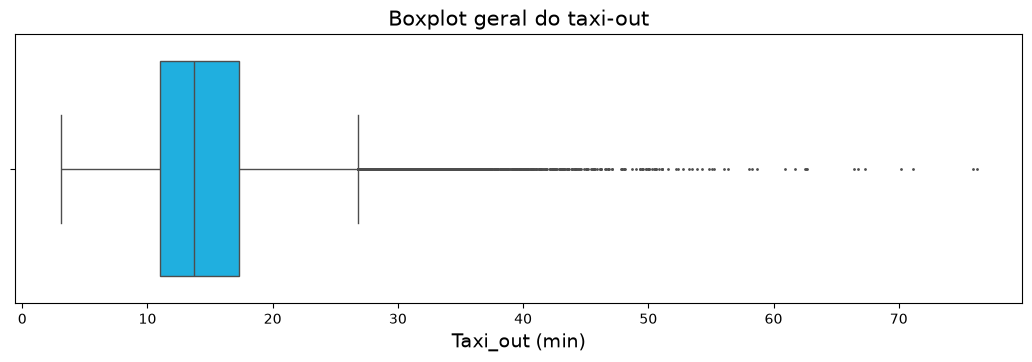

In [10]:
plt.figure(figsize=(13, 3.5))
sns.boxplot(x=cgna["taxi_out"], color="deepskyblue", fliersize=1)
plt.xlabel("Taxi_out (min)", fontsize=14)
plt.title("Boxplot geral do taxi-out", fontsize=15)
plt.show()

### 1.0.2 - Colunas do dataframe do METAR

Cada linha é uma mensagem METAR ou SPECI, decodificada com a MetPy. O índice é o
horário da observação, em UTC.

- `station_id`: código ICAO da estação (CGH/SBSP).
- `latitude`, `longitude`, `elevation`: localização e altitude da estação.
- `wind_direction`: direção de onde vem o vento, em graus verdadeiros (vazio quando VRB ou calmo).
- `wind_speed`: intensidade média do vento, em nós.
- `wind_gust`: rajada, em nós (vazio quando não há rajada).
- `visibility`: visibilidade horizontal, em metros.
- `current_wx1`, `current_wx2`, `current_wx3`: grupos de tempo presente (ex.: -RA, TSRA, BR).
- `current_wx1_symbol` a `current_wx3_symbol`: os mesmos grupos em código numérico, usado para gráficos.
- `low_cloud_type` / `low_cloud_level`: cobertura (FEW, SCT, BKN, OVC) e altura, em pés, da primeira camada de nuvens.
- `medium_cloud_*`, `high_cloud_*`, `highest_cloud_*`: o mesmo para a segunda, terceira e quarta camadas.
- `cloud_coverage`: cobertura total do céu, em oitavos.
- `air_temperature`, `dew_point_temperature`: temperatura e ponto de orvalho, em °C.
- `altimeter`: ajuste do altímetro (QNH), em polegadas de mercúrio.
- `altimeter_hpa`: o mesmo QNH, em hPa.
- `air_pressure_at_sea_level`: pressão ao nível do mar calculada pela MetPy, em hPa.
- `eastward_wind`, `northward_wind`: componentes leste e norte do vento, em nós.
- `remarks`: grupo de observações (RMK), quando existe.
- `mens`: texto original da mensagem.
- `cb`, `tcu`: 1 quando a mensagem informa cumulonimbus ou cumulus congestus. Extraídos do texto original, porque a MetPy descarta essa indicação.

In [11]:
metar.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 11410 entries, 2025-01-01 00:00:00 to 2026-01-01 03:00:00
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   station_id                 11410 non-null  str    
 1   latitude                   11410 non-null  float64
 2   longitude                  11410 non-null  float64
 3   elevation                  11410 non-null  int64  
 4   wind_direction             10641 non-null  float64
 5   wind_speed                 11393 non-null  float64
 6   wind_gust                  237 non-null    float64
 7   visibility                 11391 non-null  float64
 8   current_wx1                1349 non-null   str    
 9   current_wx2                141 non-null    str    
 10  current_wx3                0 non-null      float64
 11  low_cloud_type             8274 non-null   str    
 12  low_cloud_level            7986 non-null   float64
 13  medium_cloud_type     

## 1.1 Junção METAR → partida

Cada partida recebe a mensagem, METAR ou SPECI, mais próxima da hora de
desocupação da posição, antes ou depois dela, com no máximo 120 minutos de
diferença. As variáveis meteorológicas medem o tempo que fazia quando o táxi
começou. A tripulação conhece essa condição pela observação direta e pelo ATIS, e a
mensagem mais próxima é a que melhor a representa. É também o que o piloto informa
na ferramenta: o tempo daquele momento.


In [12]:
# Códigos de chuva no tempo presente do METAR. Moderada e forte ficam juntas.
CHUVA_LEVE = ["-DZ", "DZ", "+DZ", "-RA", "-TSRA"]
CHUVA_MOD_FORTE = ["RA", "SHRA", "TSRA", "+RA", "+TSRA"]

# Horas de memória da chuva moderada ou forte.
CHUVA_MEMORIA_H = 4

# Diferença máxima, antes ou depois, entre a mensagem METAR e a desocupação da posição, em minutos.
JANELA_METAR_MIN = 120

In [13]:
# O horário do METAR vem em UTC, sem fuso declarado.
metar = metar.sort_index()
metar["dt"] = metar.index.tz_localize("UTC")

In [14]:
# Marca com 1 as mensagens com chuva moderada ou forte, olhando os três grupos de tempo presente.
metar["chuva_mod_forte"] = 0
for coluna in ["current_wx1", "current_wx2", "current_wx3"]:
    tem_chuva = metar[coluna].isin(CHUVA_MOD_FORTE)
    metar.loc[tem_chuva, "chuva_mod_forte"] = 1

print(f"mensagens com chuva moderada ou forte: {metar['chuva_mod_forte'].sum()}")

# Percorre as mensagens em ordem. Para cada uma, olha quando foi a última chuva
# moderada ou forte ANTES dela. A própria mensagem só é guardada depois.
memoria = pd.Timedelta(hours=CHUVA_MEMORIA_H)
ultima_chuva = None
chuva_anterior = []

for momento, choveu in zip(metar["dt"], metar["chuva_mod_forte"]):
    if ultima_chuva is not None and momento - ultima_chuva < memoria:
        chuva_anterior.append(1)
    else:
        chuva_anterior.append(0)
    if choveu == 1:
        ultima_chuva = momento

metar["chuva_anterior"] = chuva_anterior
print(f"mensagens com chuva nas {CHUVA_MEMORIA_H} h anteriores: {metar['chuva_anterior'].sum()}")

mensagens com chuva moderada ou forte: 239
mensagens com chuva nas 4 h anteriores: 750


In [15]:
COLUNAS_METAR = ["dt", "current_wx1", "current_wx2", "current_wx3",
                 "visibility",
                 "low_cloud_type", "low_cloud_level",
                 "medium_cloud_type", "medium_cloud_level",
                 "high_cloud_type", "high_cloud_level",
                 "highest_cloud_type", "highest_cloud_level",
                 "wind_direction", "wind_speed", "wind_gust",
                 "cb", "tcu", "chuva_anterior"]

# O merge_asof pede os dois horários na mesma precisão.
cgna["aobt_us"] = cgna["AOBT"].astype("datetime64[us, UTC]")
metar["dt"] = metar["dt"].astype("datetime64[us, UTC]")

cgna = cgna.sort_values("aobt_us")
metar = metar.sort_values("dt")

# Para cada partida, a mensagem mais próxima, antes ou depois, em até JANELA_METAR_MIN minutos.
base = pd.merge_asof(cgna, metar[COLUNAS_METAR],
                     left_on="aobt_us", right_on="dt",
                     direction="nearest",
                     tolerance=pd.Timedelta(minutes=JANELA_METAR_MIN))

In [16]:
sem_metar = base["dt"].isna()
print(f"partidas sem mensagem a menos de {JANELA_METAR_MIN} min: {sem_metar.sum()}")

base = base[~sem_metar].copy()
print(f"partidas com mensagem: {len(base)}")

partidas sem mensagem a menos de 120 min: 0
partidas com mensagem: 92481


## 1.2 Calendário

As variáveis de calendário usam a hora de desocupação da posição no horário de
Brasília. Mês e dia da semana entram como categorias. O horário é agrupado em
blocos de 30 minutos. O primeiro bloco é o das 05h30, com as partidas que deixam a
posição pouco antes da abertura do aeroporto. O último é o das 22h30.

Só entram os feriados em dia útil. São duas variáveis: o próprio feriado e o dia seguinte, que
muitas vezes é sexta-feira de emenda. A véspera e o domingo seguinte foram
testados e não se diferenciaram de um dia comum.

Fontes dos feriados de 2025:
- Nacionais e pontos facultativos: Portaria MGI nº 9.783, de 27/12/2024
  <https://www.gov.br/previc/pt-br/acesso-a-informacao-1/institucional/normas/portarias-1/2025/portaria-mgi-no-9-783-de-27-de-dezembro-de-2024.pdf>
- Estado de São Paulo (9 de julho): Lei estadual nº 9.497, de 05/03/1997
  <https://www.al.sp.gov.br/repositorio/legislacao/lei/1997/lei-9497-05.03.1997.html>
- Cidade de São Paulo (25 de janeiro e Corpus Christi): Lei municipal nº 14.485, de 19/07/2007
  <https://legislacao.prefeitura.sp.gov.br/lei-20000-de-19-de-julho-de-2007>

### 1.2.1 Dia da Semana e Mês

In [17]:
local = base["AOBT"].dt.tz_convert(TZ)

base["data"] = local.dt.date.astype(str)
base["mes"] = local.dt.month

#### 1.2.1.1 Dia da semana

In [18]:
DIAS = {"Monday": "Segunda", "Tuesday": "Terça", "Wednesday": "Quarta",
        "Thursday": "Quinta", "Friday": "Sexta", "Saturday": "Sábado", "Sunday": "Domingo"}

dia_em_ingles = local.dt.day_name()
dia_em_portugues = dia_em_ingles.map(DIAS)
base["dia_semana"] = pd.Categorical(dia_em_portugues, categories=list(DIAS.values()))

print(base["dia_semana"].value_counts(sort=False).to_dict())

{'Segunda': 14111, 'Terça': 14163, 'Quarta': 14312, 'Quinta': 14159, 'Sexta': 14084, 'Sábado': 9446, 'Domingo': 12206}


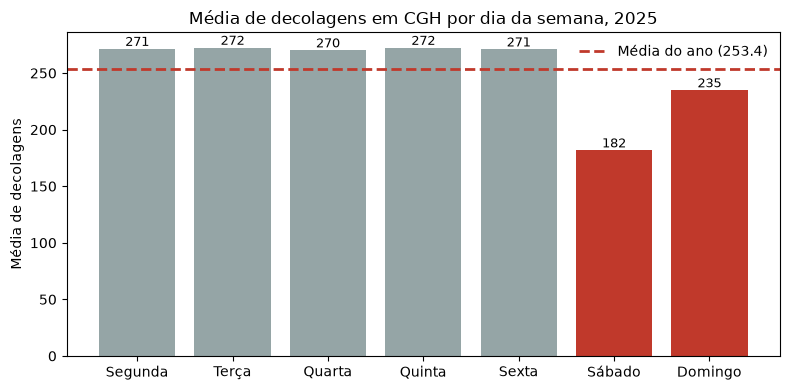

In [19]:
# Decolagens por dia, dia da semana.
partidas_por_dia = base.groupby("data").size()
dow_cada_data = base.groupby("data")["dia_semana"].first()
media_dia = partidas_por_dia.mean()

# Média de decolagens para cada dia da semana (segunda a domingo).
media_por_dia_semana = partidas_por_dia.groupby(dow_cada_data, observed=True).mean()
dias_semana = list(media_por_dia_semana.index)

cores_dow = ["#c0392b" if d in ("Sábado", "Domingo") else "#95a5a6" for d in dias_semana]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dias_semana, media_por_dia_semana.values, color=cores_dow)
ax.set_ylabel("Média de decolagens")
ax.set_title(f"Média de decolagens em {AEROPORTO.upper()} por dia da semana, {ANO}")
for d, v in zip(dias_semana, media_por_dia_semana.values):
    ax.text(d, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
ax.axhline(
    media_dia, color="#c0392b", linewidth=2, linestyle="--",
    label=f"Média do ano ({media_dia:.1f})",
)
ax.legend(loc="upper right", ncol=2, frameon=False)
plt.tight_layout()
plt.show()

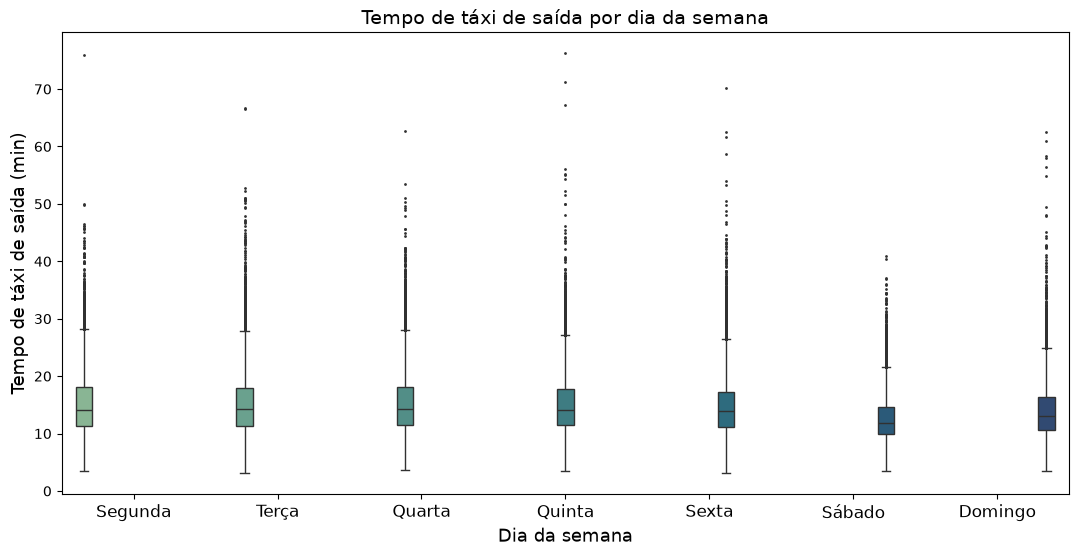

,count,median,mean
dia_semana,,,
Segunda,14111,14.17,15.18
Terça,14163,14.20,15.20
Quarta,14312,14.25,15.27
Quinta,14159,14.13,15.09
Sexta,14084,13.85,14.80
Sábado,9446,11.88,12.67
Domingo,12206,13.02,14.05


In [20]:
DIAS_ORDEM = list(base["dia_semana"].cat.categories)

plt.figure(figsize=(13, 6))
sns.boxplot(data=base, x="dia_semana", y="taxi_out", order=DIAS_ORDEM,
            palette="crest", fliersize=1, hue="dia_semana", legend=False)
plt.xticks(fontsize=12)
plt.xlabel("Dia da semana", fontsize=13)
plt.ylabel("Tempo de táxi de saída (min)", fontsize=13)
plt.title("Tempo de táxi de saída por dia da semana", fontsize=14)
plt.show()

base.groupby("dia_semana", observed=True)["taxi_out"].agg(["count", "median", "mean"]).round(2)

#### 1.2.1.2 Mês

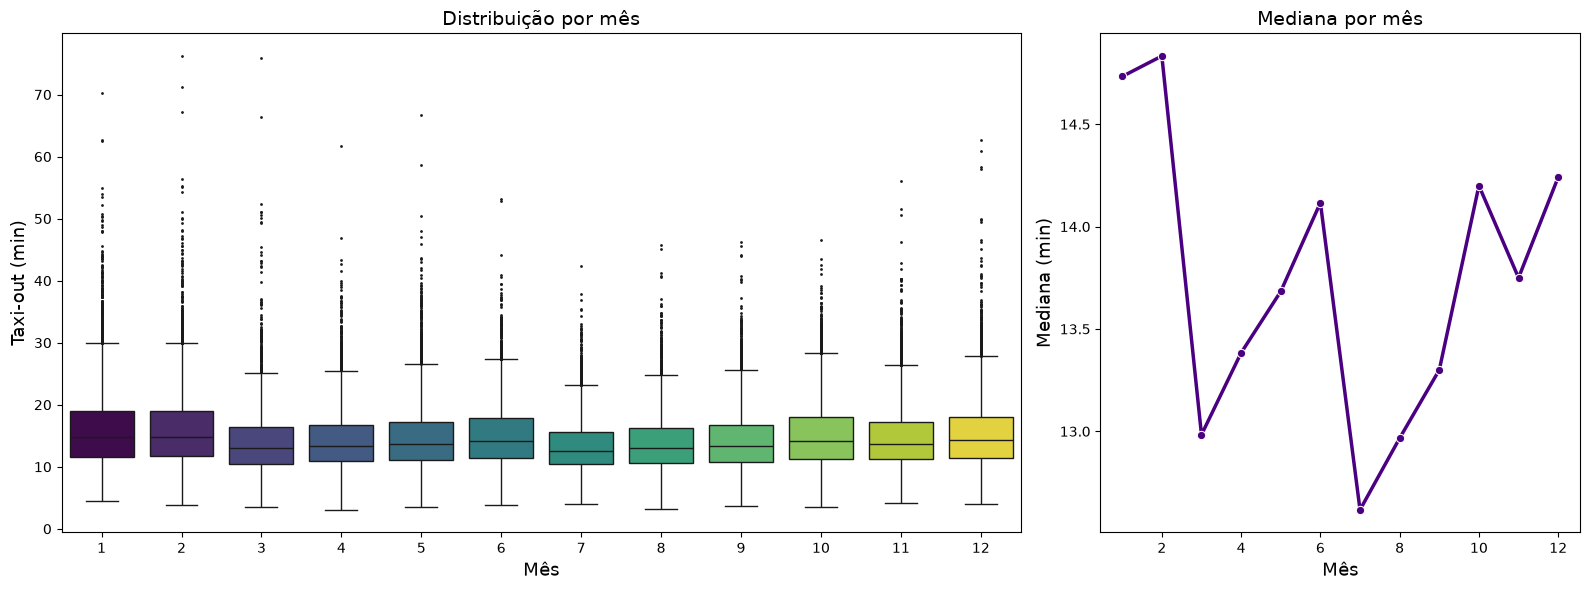

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [2, 1]})
sns.boxplot(data=base, x="mes", y="taxi_out", ax=ax[0], palette="viridis",
            fliersize=1, hue="mes", legend=False)
ax[0].set_xlabel("Mês", fontsize=13); ax[0].set_ylabel("Taxi-out (min)", fontsize=13)
ax[0].set_title("Distribuição por mês", fontsize=14)

med = base.groupby("mes", observed=True)["taxi_out"].median()
sns.lineplot(x=med.index, y=med.values, marker="o", color="indigo", lw=2.5, ax=ax[1])
ax[1].set_xlabel("Mês", fontsize=13); ax[1].set_ylabel("Mediana (min)", fontsize=13)
ax[1].set_title("Mediana por mês", fontsize=14)
plt.tight_layout()
plt.show()

### 1.2.2 - Bloco de horarios

In [22]:
# Bloco de horário: a hora arredondada para baixo em blocos de BLOCO_MIN minutos.
bloco = local.dt.floor(f"{BLOCO_MIN}min").dt.strftime("%H:%M")

# Depois das 23h00 são poucas partidas, que saíram com atraso.
# Elas entram no último bloco, o das 22h30.
depois_das_23h = local.dt.hour >= 23
bloco[depois_das_23h] = "22:30"
base["bloco"] = bloco

print(f"blocos: {base['bloco'].nunique()}")
print(f"primeiro bloco: {bloco.min()} | último bloco: {bloco.max()}")
print(f"partidas depois das 23h00, levadas para o bloco das 22h30: {depois_das_23h.sum()}")

blocos: 35
primeiro bloco: 05:30 | último bloco: 22:30
partidas depois das 23h00, levadas para o bloco das 22h30: 32


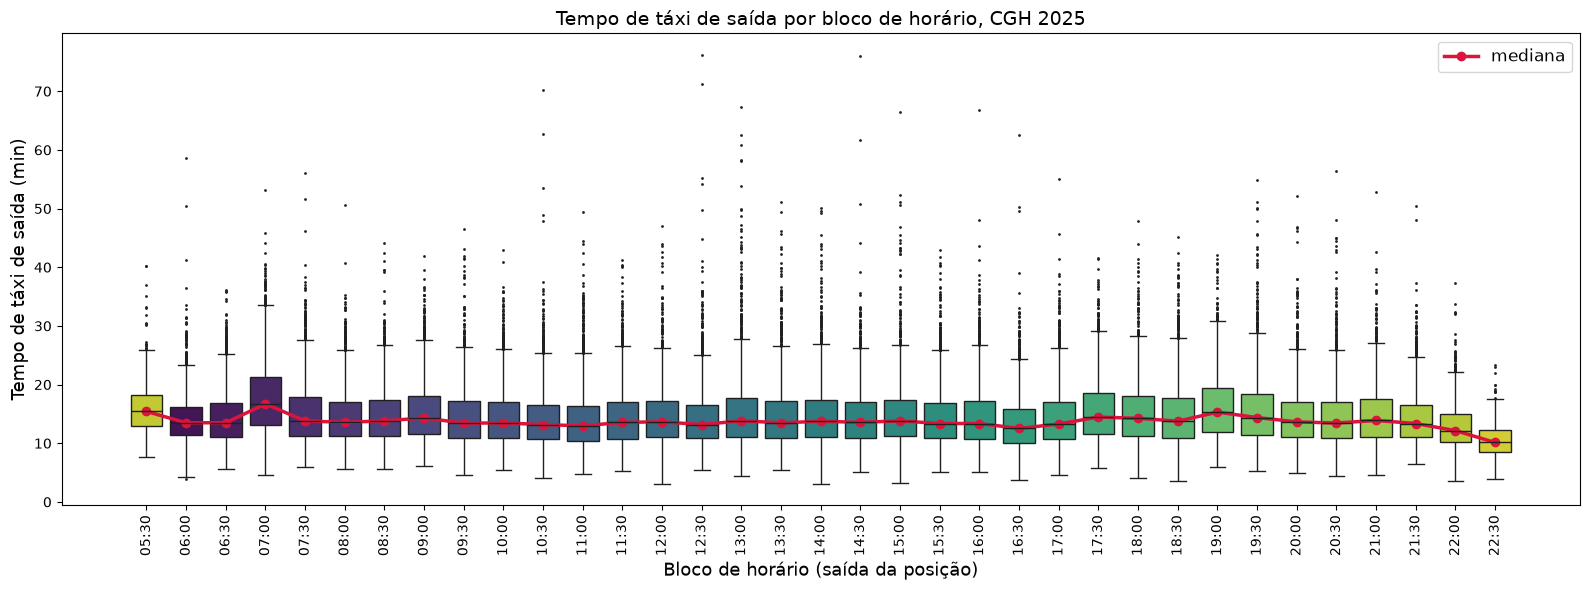

In [23]:
ordem = sorted(base["bloco"].unique())

plt.figure(figsize=(16, 6))
sns.boxplot(data=base, x="bloco", y="taxi_out", order=ordem,
            palette="viridis", fliersize=1, hue="bloco", legend=False)

mediana_por_bloco = base.groupby("bloco")["taxi_out"].median().reindex(ordem)
plt.plot(range(len(ordem)), mediana_por_bloco.values, color="crimson", lw=2.5, marker="o",
         label="mediana")

plt.xticks(rotation=90, fontsize=10)
plt.xlabel("Bloco de horário (saída da posição)", fontsize=13)
plt.ylabel("Tempo de táxi de saída (min)", fontsize=13)
plt.title(f"Tempo de táxi de saída por bloco de horário, {AEROPORTO.upper()} {ANO}", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 1.2.2.1 Mapa de Calor: bloco de horario x dia da semana

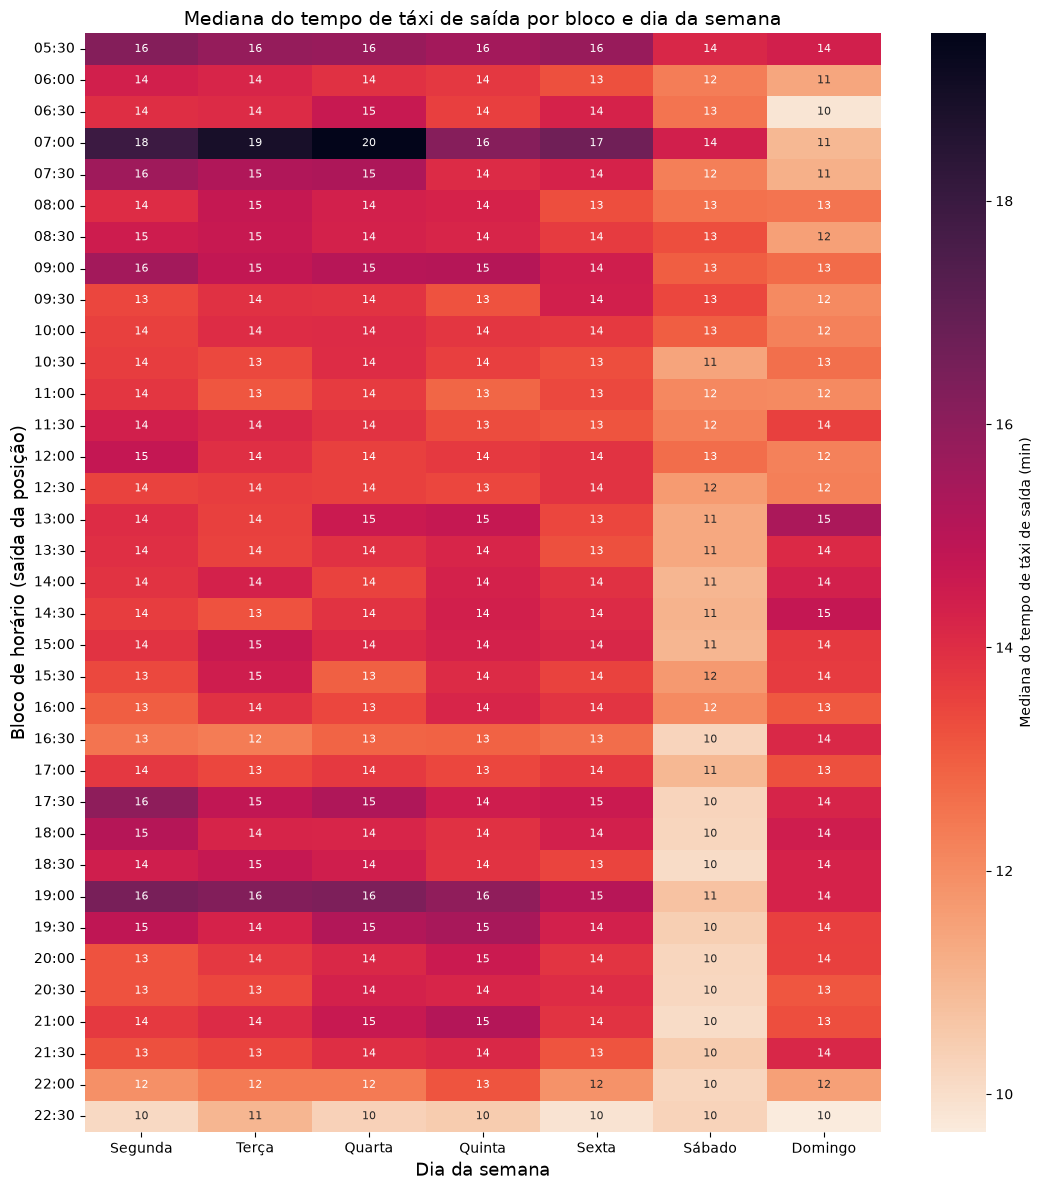

In [24]:
tabela = base.pivot_table(index="bloco", columns="dia_semana", values="taxi_out",
                          aggfunc="median", observed=True).reindex(ordem)

plt.figure(figsize=(11, 12))
sns.heatmap(tabela, cmap="rocket_r", annot=True, fmt=".0f", annot_kws={"size": 8},
            cbar_kws={"label": "Mediana do tempo de táxi de saída (min)"})
plt.xticks(rotation=0)
plt.xlabel("Dia da semana", fontsize=13)
plt.ylabel("Bloco de horário (saída da posição)", fontsize=13)
plt.title("Mediana do tempo de táxi de saída por bloco e dia da semana", fontsize=14)
plt.tight_layout()
plt.show()

### 1.2.3 - Feriados

In [25]:
FERIADOS = {
    "2025-01-01": "Confraternização Universal",
    "2025-01-25": "Aniversário de São Paulo",       # municipal
    "2025-03-03": "Carnaval",                       # ponto facultativo federal
    "2025-03-04": "Carnaval",                       # ponto facultativo federal
    "2025-04-18": "Paixão de Cristo",
    "2025-04-21": "Tiradentes",
    "2025-05-01": "Dia do Trabalho",
    "2025-06-19": "Corpus Christi",                 # feriado municipal em São Paulo
    "2025-07-09": "Revolução Constitucionalista",   # estadual
    "2025-09-07": "Independência",
    "2025-10-12": "Nossa Senhora Aparecida",
    "2025-11-02": "Finados",
    "2025-11-15": "Proclamação da República",
    "2025-11-20": "Consciência Negra",
    "2025-12-25": "Natal",
}

feriados = pd.to_datetime(list(FERIADOS.keys()))

# Só os feriados de segunda a sexta (dayofweek de 0 a 4).
feriados_uteis = feriados[feriados.dayofweek < 5]
print(f"feriados no ano: {len(feriados)}")
print(f"feriados em dia útil: {len(feriados_uteis)}")

data = pd.to_datetime(base["data"])
ontem = data - pd.Timedelta(days=1)

eh_feriado = data.isin(feriados_uteis)
base["feriado"] = eh_feriado.astype(int)

# Dia seguinte a feriado, desde que o próprio dia não seja feriado
# (a terça de Carnaval é feriado, e não dia seguinte da segunda).
eh_dia_seguinte = ontem.isin(feriados_uteis) & ~eh_feriado
base["dia_seguinte_feriado"] = eh_dia_seguinte.astype(int)

print(f"partidas em feriado: {base['feriado'].sum()}")
print(f"partidas no dia seguinte a feriado: {base['dia_seguinte_feriado'].sum()}")

feriados no ano: 15
feriados em dia útil: 10
partidas em feriado: 2348
partidas no dia seguinte a feriado: 2096


,n,media,mediana,dp,p25,p75
tipo_dia,,,,,,
Dia normal,88037,14.79,13.75,5.20,11.08,17.43
Feriado,2348,13.37,12.39,4.83,10.12,15.52
Dia seguinte ao feriado,2096,13.55,12.57,4.75,10.40,15.54


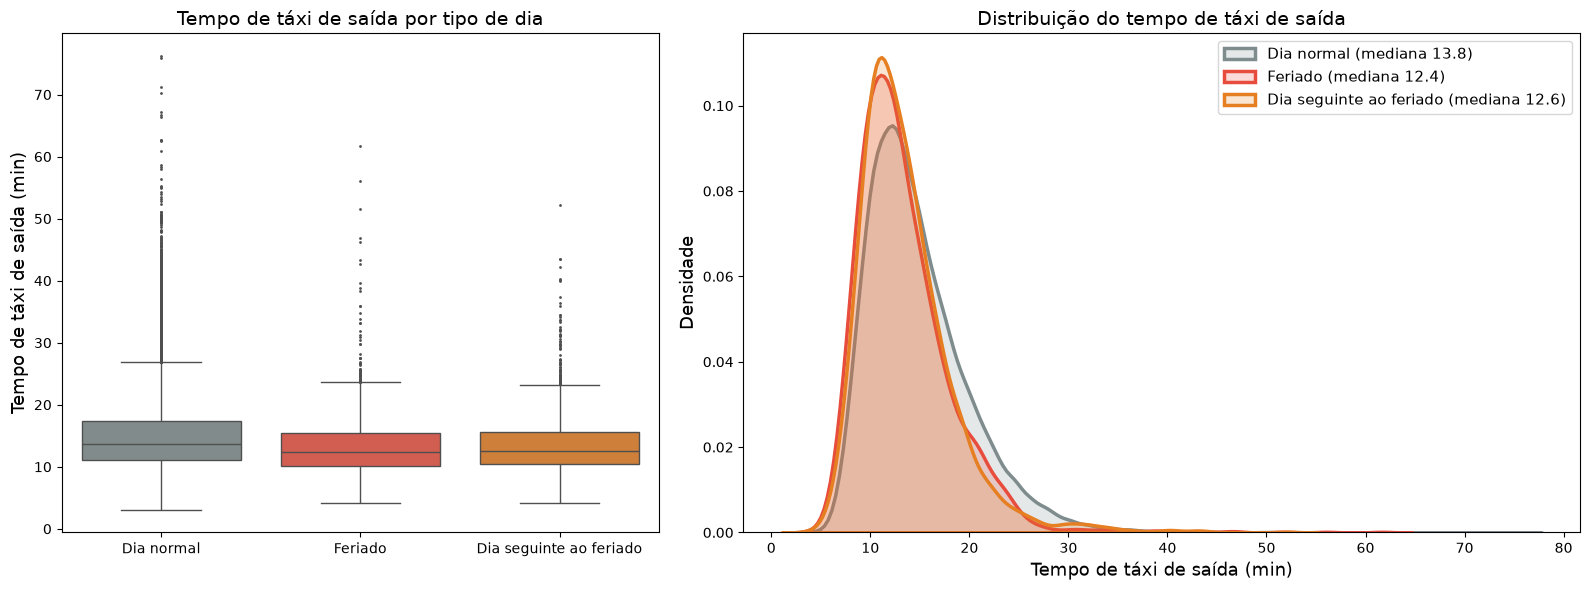

In [26]:
# Três tipos de dia: normal, feriado em dia útil e dia seguinte ao feriado.
base["tipo_dia"] = "Dia normal"
base.loc[base["feriado"] == 1, "tipo_dia"] = "Feriado"
base.loc[base["dia_seguinte_feriado"] == 1, "tipo_dia"] = "Dia seguinte ao feriado"

ORDEM_TIPO_DIA = ["Dia normal", "Feriado", "Dia seguinte ao feriado"]
CORES = ["#7f8c8d", "#e74c3c", "#e67e22"]

# Resumo estatístico de cada grupo.
por_tipo_de_dia = base.groupby("tipo_dia")["taxi_out"]
resumo = pd.DataFrame()
resumo["n"] = por_tipo_de_dia.count()
resumo["media"] = por_tipo_de_dia.mean()
resumo["mediana"] = por_tipo_de_dia.median()
resumo["dp"] = por_tipo_de_dia.std()
resumo["p25"] = por_tipo_de_dia.quantile(0.25)
resumo["p75"] = por_tipo_de_dia.quantile(0.75)
resumo = resumo.reindex(ORDEM_TIPO_DIA).round(2)
display(resumo)

# Gráficos: boxplot e distribuição.
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.4]})

sns.boxplot(data=base, x="tipo_dia", y="taxi_out", order=ORDEM_TIPO_DIA, ax=ax[0],
            hue="tipo_dia", hue_order=ORDEM_TIPO_DIA, palette=CORES,
            legend=False, fliersize=1)
ax[0].set_xlabel("")
ax[0].set_ylabel("Tempo de táxi de saída (min)", fontsize=13)
ax[0].set_title("Tempo de táxi de saída por tipo de dia", fontsize=14)

for rotulo, cor in zip(ORDEM_TIPO_DIA, CORES):
    grupo = base.loc[base["tipo_dia"] == rotulo, "taxi_out"]
    sns.kdeplot(grupo, ax=ax[1], label=f"{rotulo} (mediana {grupo.median():.1f})",
                color=cor, lw=2.5, fill=True, alpha=0.2)
ax[1].set_xlabel("Tempo de táxi de saída (min)", fontsize=13)
ax[1].set_ylabel("Densidade", fontsize=13)
ax[1].set_title("Distribuição do tempo de táxi de saída", fontsize=14)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

## 1.3 Meteorologia

A chuva tem três faixas: sem, leve e moderada ou forte. A forte foi juntada à
moderada porque a operação com chuva forte é proibida em Congonhas (IS 121-020 da
ANAC, item D4.7.4).

O teto é a base da camada mais baixa com BKN ou OVC. Os cortes são 1.500 pés, o
mínimo do voo visual e 500 pés, abaixo do qual as chegadas
deixam a aproximação RNAV (mínimo de 450 pés) e dependem do ILS (mínimo de 200 pés).

Trovoada, TCU e rajada são fenômenos de tempo significativo e entram como variáveis
binárias. O CB não entra separado, porque a trovoada é sempre produzida por um
cumulonimbus. 

### 1.3.1 - Chuva Leve, Moderada e Forte

In [27]:
# Chuva de cada partida, olhando os três grupos de tempo presente.
chuva_leve = pd.Series(False, index=base.index)
chuva_mod_forte = pd.Series(False, index=base.index)

for coluna in ["current_wx1", "current_wx2", "current_wx3"]:
    chuva_leve = chuva_leve | base[coluna].isin(CHUVA_LEVE)
    chuva_mod_forte = chuva_mod_forte | base[coluna].isin(CHUVA_MOD_FORTE)

chuva = pd.Series("sem", index=base.index)
chuva[chuva_leve] = "leve"
chuva[chuva_mod_forte] = "moderada_forte"
base["chuva"] = pd.Categorical(chuva, categories=["sem", "leve", "moderada_forte"])

print(base["chuva"].value_counts().to_dict())

{'sem': 87834, 'leve': 3978, 'moderada_forte': 669}


,n,% das partidas,media,mediana,p90
chuva_lbl,,,,,
Sem chuva,87834,94.98,14.60,13.62,21.25
Leve,3978,4.30,16.57,15.18,25.10
Moderada ou forte,669,0.72,19.96,18.08,30.72


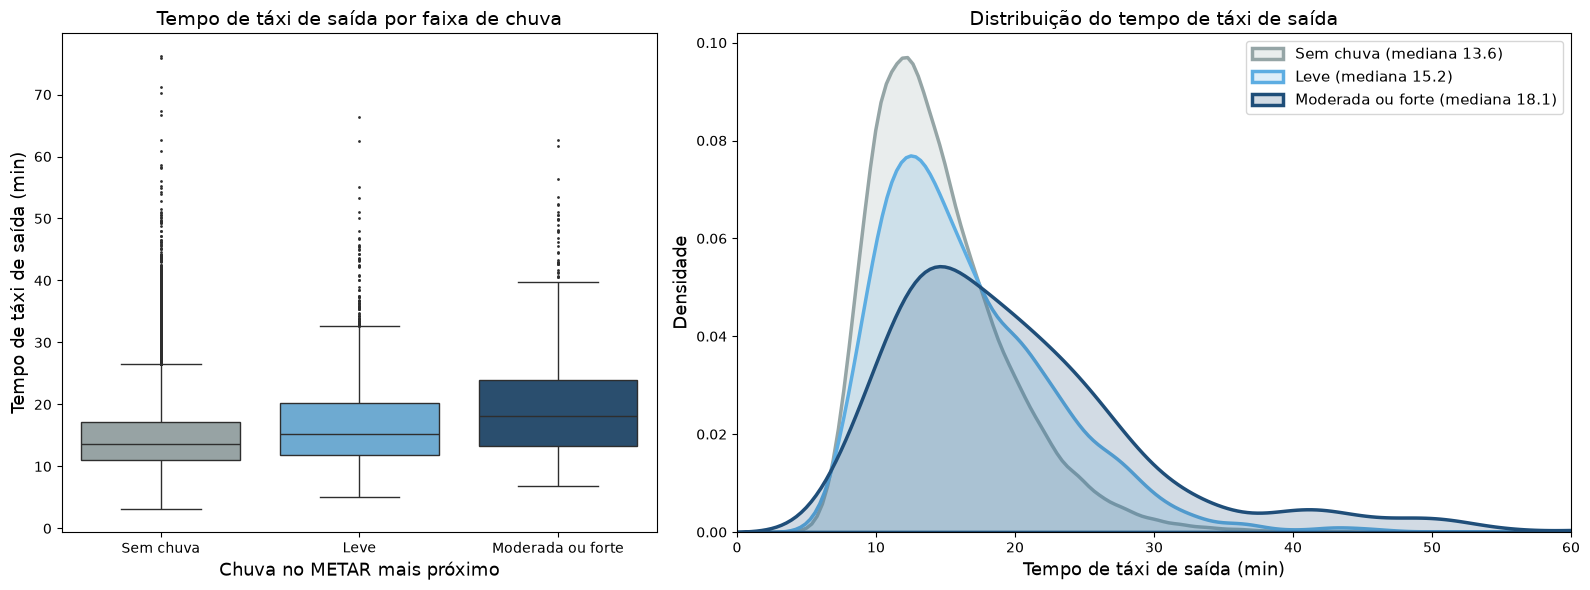

In [28]:
# Nomes para os gráficos e uma cor para cada faixa de chuva.
NOMES_CHUVA = {"sem": "Sem chuva", "leve": "Leve", "moderada_forte": "Moderada ou forte"}
ORDEM_CHUVA = ["Sem chuva", "Leve", "Moderada ou forte"]
CORES_CHUVA = ["#95a5a6", "#5dade2", "#1f4e79"]

base["chuva_lbl"] = base["chuva"].astype(str).map(NOMES_CHUVA)

# Resumo estatístico de cada faixa.
por_chuva = base.groupby("chuva_lbl")["taxi_out"]
resumo_chuva = pd.DataFrame()
resumo_chuva["n"] = por_chuva.count()
resumo_chuva["% das partidas"] = por_chuva.count() / len(base) * 100
resumo_chuva["media"] = por_chuva.mean()
resumo_chuva["mediana"] = por_chuva.median()
resumo_chuva["p90"] = por_chuva.quantile(0.90)
resumo_chuva = resumo_chuva.reindex(ORDEM_CHUVA).round(2)
display(resumo_chuva)

# Gráficos: boxplot e distribuição.
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.4]})

sns.boxplot(data=base, x="chuva_lbl", y="taxi_out", order=ORDEM_CHUVA, ax=ax[0],
            hue="chuva_lbl", hue_order=ORDEM_CHUVA, palette=CORES_CHUVA,
            legend=False, fliersize=1)
ax[0].set_xlabel("Chuva no METAR mais próximo", fontsize=13)
ax[0].set_ylabel("Tempo de táxi de saída (min)", fontsize=13)
ax[0].set_title("Tempo de táxi de saída por faixa de chuva", fontsize=14)

for rotulo, cor in zip(ORDEM_CHUVA, CORES_CHUVA):
    grupo = base.loc[base["chuva_lbl"] == rotulo, "taxi_out"]
    sns.kdeplot(grupo, ax=ax[1], label=f"{rotulo} (mediana {grupo.median():.1f})",
                color=cor, lw=2.5, fill=True, alpha=0.2)
ax[1].set_xlim(0, 60)
ax[1].set_xlabel("Tempo de táxi de saída (min)", fontsize=13)
ax[1].set_ylabel("Densidade", fontsize=13)
ax[1].set_title("Distribuição do tempo de táxi de saída", fontsize=14)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

,mes,partidas,% leve,% moderada ou forte,mediana (min)
0,1,7973,4.41,1.71,14.73
1,2,7376,6.44,1.69,14.83
2,3,7600,5.29,1.16,12.98
3,4,7478,6.74,0.76,13.38
4,5,7704,1.04,0.26,13.68
5,6,7537,5.84,0.29,14.12
6,7,7861,0.85,0.00,12.62
7,8,7730,2.65,0.00,12.97
8,9,7582,2.29,0.51,13.30
9,10,8065,7.65,0.68,14.20


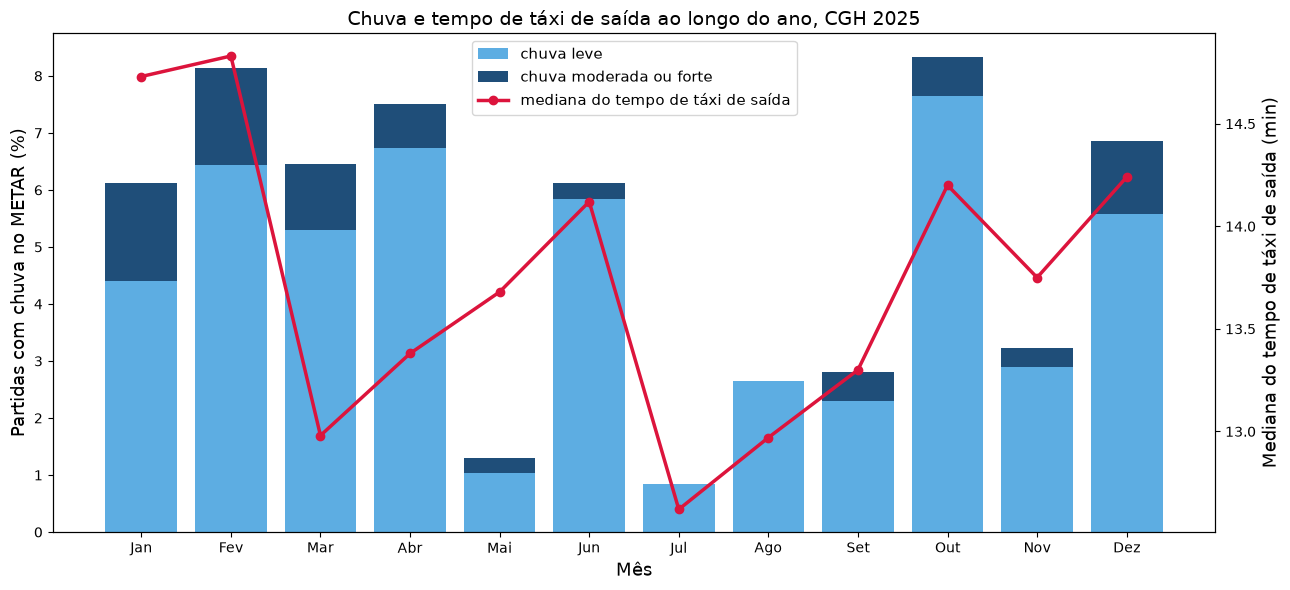

In [29]:
# Chuva ao longo do ano: % das partidas de cada mês com chuva no METAR.
MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

linhas = []
for mes in range(1, 13):
    do_mes = base[base["mes"] == mes]
    linhas.append({"mes": mes,
                   "partidas": len(do_mes),
                   "% leve": (do_mes["chuva"] == "leve").mean() * 100,
                   "% moderada ou forte": (do_mes["chuva"] == "moderada_forte").mean() * 100,
                   "mediana (min)": do_mes["taxi_out"].median()})
chuva_por_mes = pd.DataFrame(linhas).round(2)
display(chuva_por_mes)

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(MESES, chuva_por_mes["% leve"], color="#5dade2", label="chuva leve")
ax.bar(MESES, chuva_por_mes["% moderada ou forte"], bottom=chuva_por_mes["% leve"],
       color="#1f4e79", label="chuva moderada ou forte")
ax.set_xlabel("Mês", fontsize=13)
ax.set_ylabel("Partidas com chuva no METAR (%)", fontsize=13)

# Segundo eixo, à direita, para a mediana do tempo de táxi do mês.
ax2 = ax.twinx()
ax2.plot(MESES, chuva_por_mes["mediana (min)"], marker="o", lw=2.5, color="crimson",
         label="mediana do tempo de táxi de saída")
ax2.set_ylabel("Mediana do tempo de táxi de saída (min)", fontsize=13)

# Junta as legendas dos dois eixos numa só.
barras, nomes_barras = ax.get_legend_handles_labels()
linha, nome_linha = ax2.get_legend_handles_labels()
ax.legend(barras + linha, nomes_barras + nome_linha, fontsize=11, loc="upper center")

plt.title(f"Chuva e tempo de táxi de saída ao longo do ano, {AEROPORTO.upper()} {ANO}", fontsize=14)
plt.tight_layout()
plt.show()

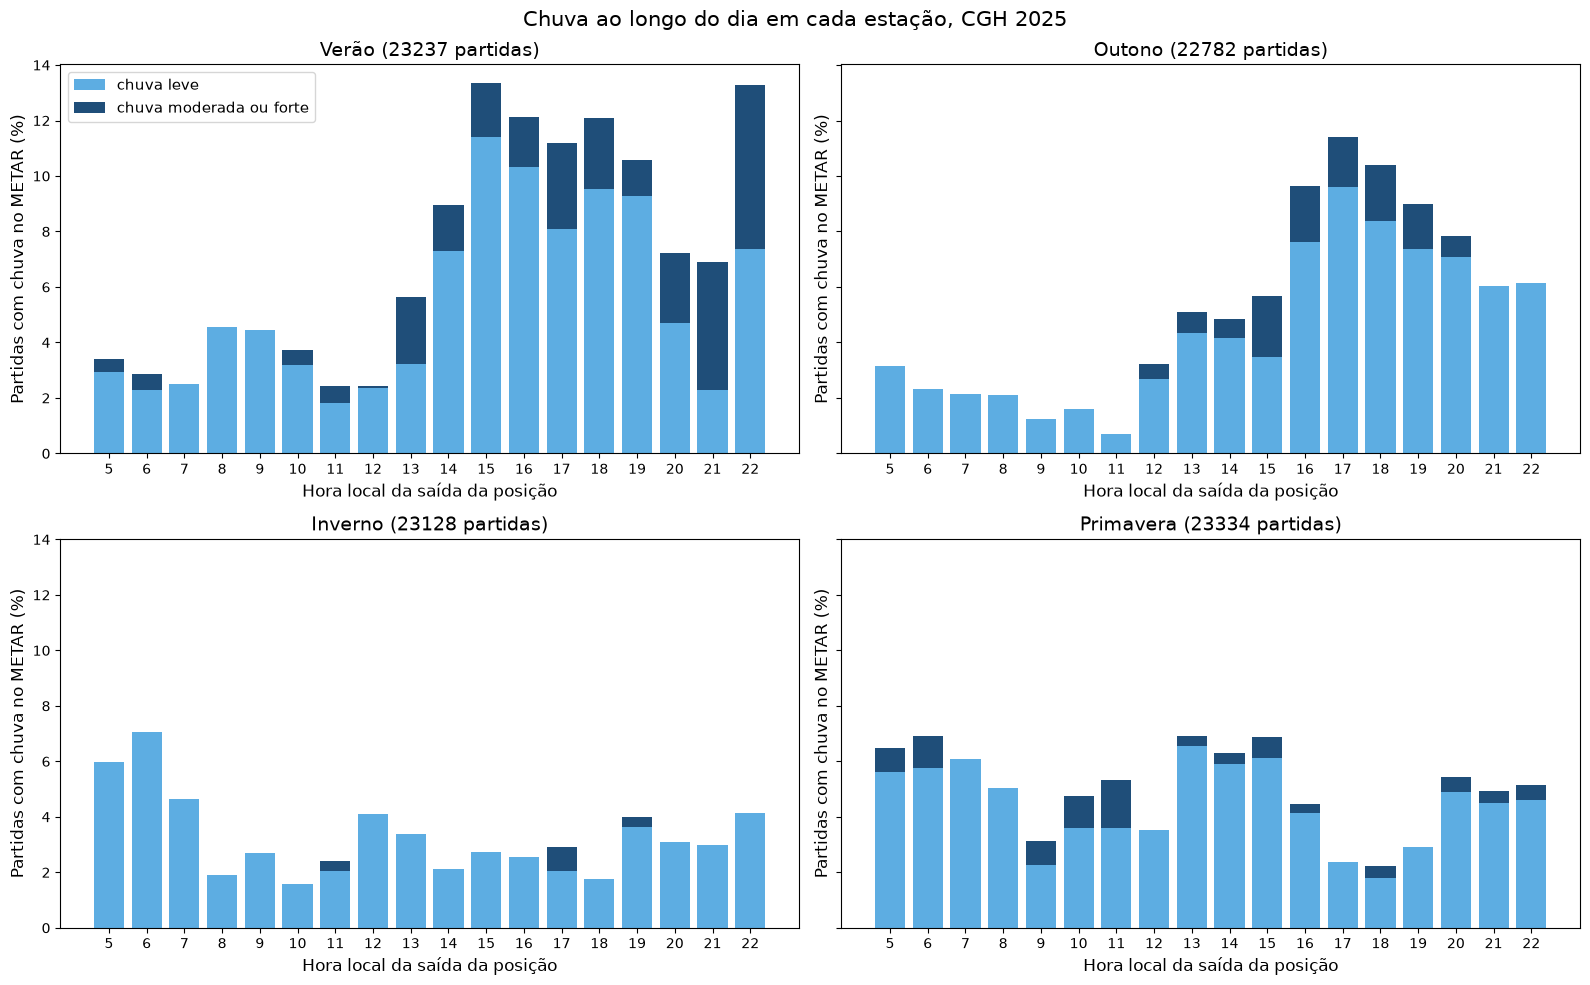

estacao,Verão,Outono,Inverno,Primavera
hora,,,,
5,3.4,3.1,6.0,6.5
6,2.9,2.3,7.1,6.9
7,2.5,2.2,4.6,6.1
8,4.6,2.1,1.9,5.0
9,4.4,1.3,2.7,3.1
10,3.7,1.6,1.6,4.7
11,2.4,0.7,2.4,5.3
12,2.4,3.2,4.1,3.5
13,5.6,5.1,3.4,6.9


In [30]:
# Estações do ano no hemisfério sul, pelo mês.

base["estacao"] = base["mes"].map(ESTACAO_ANO)

# Hora local da desocupação da posição (depois das 23h entra nas 22h, como no bloco).
hora = base["AOBT"].dt.tz_convert(TZ).dt.hour
hora[hora >= 23] = 22
base["hora"] = hora
HORAS = list(range(base["hora"].min(), base["hora"].max() + 1))

fig, eixos = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
eixos = eixos.flatten()

for i, estacao in enumerate(ORDEM_ESTACAO_ANO):
    da_estacao = base[base["estacao"] == estacao]

    # % das partidas com chuva em cada hora.
    leve = []
    mod_forte = []
    for h in HORAS:
        da_hora = da_estacao[da_estacao["hora"] == h]
        leve.append((da_hora["chuva"] == "leve").mean() * 100)
        mod_forte.append((da_hora["chuva"] == "moderada_forte").mean() * 100)

    ax = eixos[i]
    ax.bar(HORAS, leve, color="#5dade2", label="chuva leve")
    ax.bar(HORAS, mod_forte, bottom=leve, color="#1f4e79", label="chuva moderada ou forte")
    ax.set_title(f"{estacao} ({len(da_estacao)} partidas)", fontsize=14)
    ax.set_xticks(HORAS)
    ax.set_xlabel("Hora local da saída da posição", fontsize=12)
    ax.set_ylabel("Partidas com chuva no METAR (%)", fontsize=12)

eixos[0].legend(fontsize=11, loc="upper left")
plt.suptitle(f"Chuva ao longo do dia em cada estação, {AEROPORTO.upper()} {ANO}", fontsize=15)
plt.tight_layout()
plt.show()

# A mesma informação em tabela: % de partidas com chuva (leve ou mais) por estação e hora.
base["com_chuva"] = (base["chuva"] != "sem").astype(int)
tabela_chuva = base.pivot_table(index="hora", columns="estacao", values="com_chuva",
                                aggfunc="mean")[ORDEM_ESTACAO_ANO] * 100
tabela_chuva.round(1)

#### 1.3.1.1 - Chuva Moderada/Forte nas horas anteriores

In [31]:
# Chuva moderada ou forte nas N h anteriores, calculada no METAR antes da junção (2.1).
# O efeito é separado pela época do ano: quente (setembro a fevereiro) e fria (março a agosto).
base["chuva_anterior"] = base["chuva_anterior"].astype(int)

epoca_quente = base["mes"].isin([9, 10, 11, 12, 1, 2])

base["chuva_anterior_quente"] = (base["chuva_anterior"] * epoca_quente).astype(int)
base["chuva_anterior_fria"] = (base["chuva_anterior"] * ~epoca_quente).astype(int)

print(f"chuva nas {CHUVA_MEMORIA_H} h anteriores: {base['chuva_anterior'].sum()}")
print(f"  época quente: {base['chuva_anterior_quente'].sum()}")
print(f"  época fria: {base['chuva_anterior_fria'].sum()}")

chuva nas 4 h anteriores: 3646
  época quente: 2552
  época fria: 1094


,época,partidas com,% com,dif. mediana (min),dif. P90 (min)
0,Quente (set a fev),2552,5.48,3.55,5.95
1,Fria (mar a ago),1094,2.38,1.66,3.53


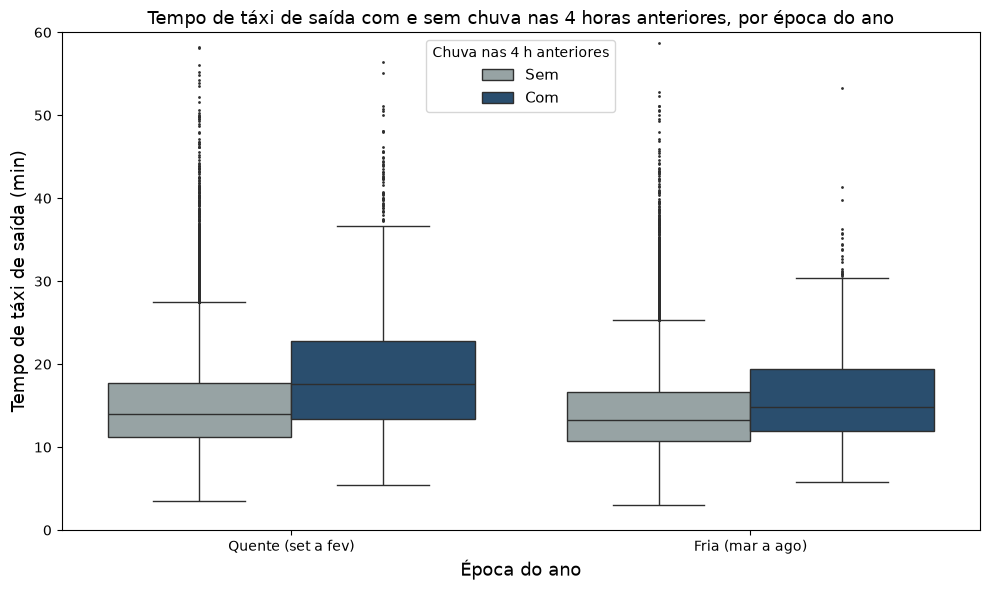

In [32]:
# A chuva nas horas anteriores pesa igual na época quente e na fria?
# Usa a chuva anterior do ano todo (a da junção, seção 1.1), sem zerar a época fria.
NOME_QUENTE = "Quente (set a fev)"
NOME_FRIA = "Fria (mar a ago)"
ORDEM_EPOCA = [NOME_QUENTE, NOME_FRIA]

# Época quente: primavera e verão, de setembro a fevereiro.
epoca_quente = base["mes"].isin([9, 10, 11, 12, 1, 2])
base["epoca"] = NOME_FRIA
base.loc[epoca_quente, "epoca"] = NOME_QUENTE
base["chuva_anterior_lbl"] = base["chuva_anterior"].map({0: "Sem", 1: "Com"})

linhas = []
for epoca in ORDEM_EPOCA:
    da_epoca = base[base["epoca"] == epoca]
    com = da_epoca.loc[da_epoca["chuva_anterior"] == 1, "taxi_out"]
    sem = da_epoca.loc[da_epoca["chuva_anterior"] == 0, "taxi_out"]
    linhas.append({"época": epoca,
                   "partidas com": len(com),
                   "% com": len(com) / len(da_epoca) * 100,
                   "dif. mediana (min)": com.median() - sem.median(),
                   "dif. P90 (min)": com.quantile(0.90) - sem.quantile(0.90)})
display(pd.DataFrame(linhas).round(2))

plt.figure(figsize=(10, 6))
sns.boxplot(data=base, x="epoca", y="taxi_out", hue="chuva_anterior_lbl",
            order=ORDEM_EPOCA, hue_order=["Sem", "Com"],
            palette=["#95a5a6", "#1f4e79"], fliersize=1)
plt.ylim(0, 60)
plt.xlabel("Época do ano", fontsize=13)
plt.ylabel("Tempo de táxi de saída (min)", fontsize=13)
plt.title(f"Tempo de táxi de saída com e sem chuva nas {CHUVA_MEMORIA_H} horas anteriores, por época do ano",
          fontsize=13)
plt.legend(title=f"Chuva nas {CHUVA_MEMORIA_H} h anteriores", fontsize=11)
plt.tight_layout()
plt.show()

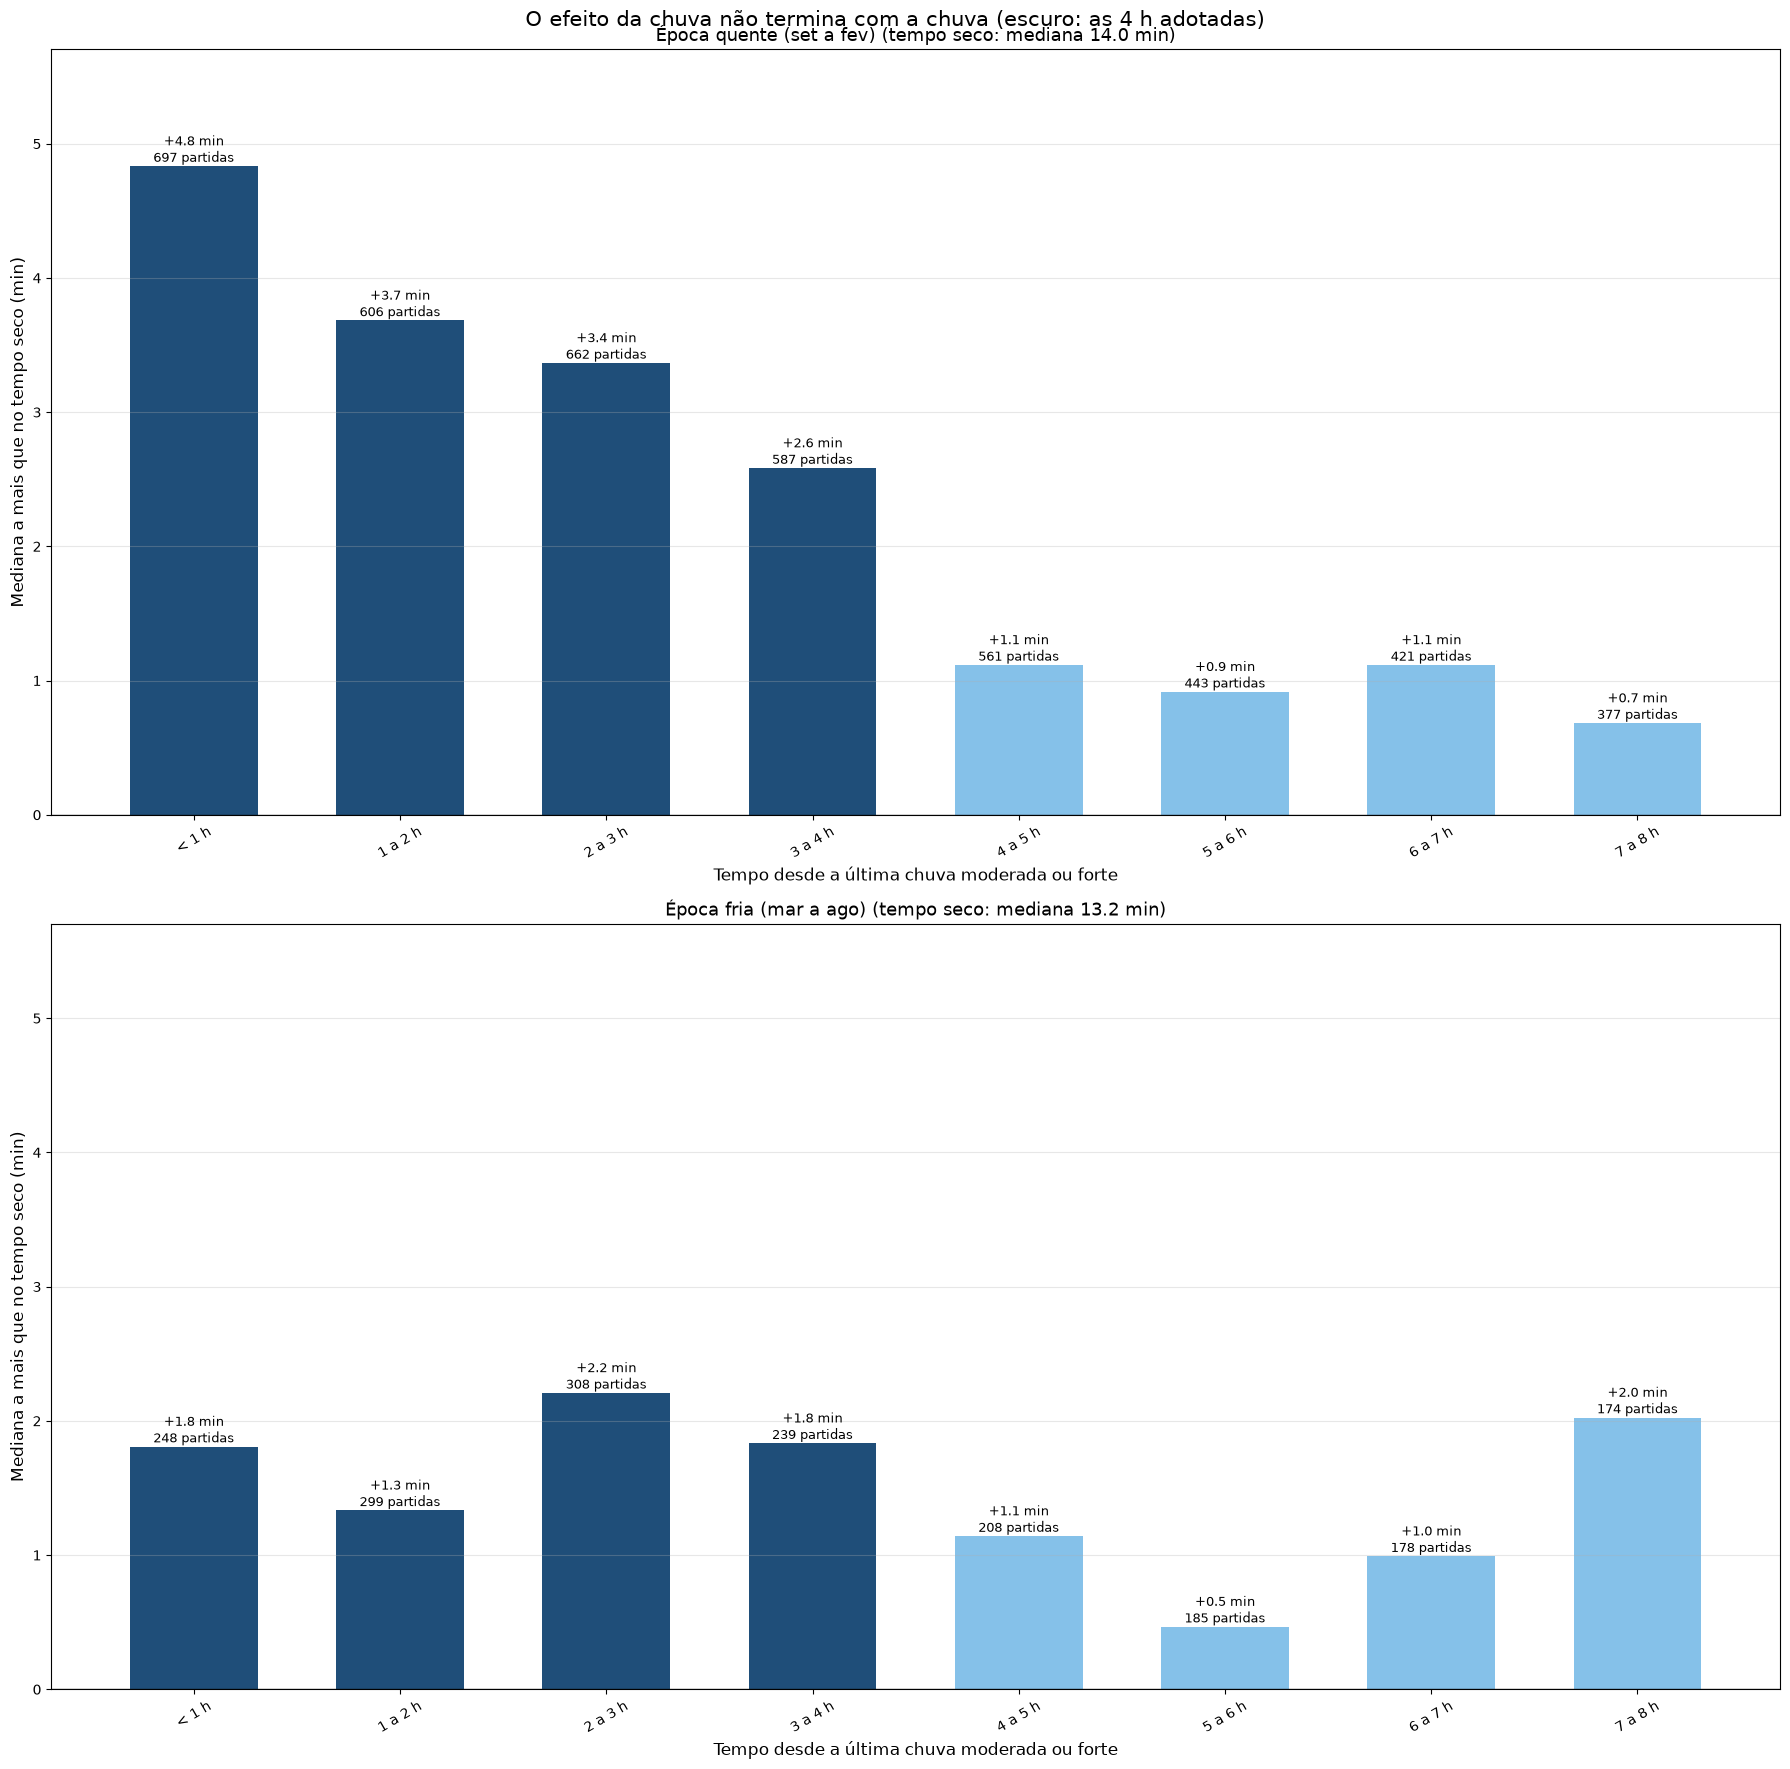

época,Quente (set a fev),Fria (mar a ago)
faixa,,
< 1 h,4.83,1.81
1 a 2 h,3.68,1.33
2 a 3 h,3.37,2.21
3 a 4 h,2.58,1.83
4 a 5 h,1.12,1.14
5 a 6 h,0.92,0.47
6 a 7 h,1.12,0.99
7 a 8 h,0.68,2.02


época,Quente (set a fev),Fria (mar a ago)
faixa,,
< 1 h,697,248
1 a 2 h,606,299
2 a 3 h,662,308
3 a 4 h,587,239
4 a 5 h,561,208
5 a 6 h,443,185
6 a 7 h,421,178
7 a 8 h,377,174


In [33]:
# Há quantas horas foi a última chuva moderada ou forte, antes de cada mensagem?
# Mesma lógica da chuva anterior do 1.1: a própria mensagem só é guardada depois.
ultima_chuva = None
horas_desde = []

for momento, choveu in zip(metar["dt"], metar["chuva_mod_forte"]):
    if ultima_chuva is None:
        horas_desde.append(np.nan)
    else:
        horas_desde.append((momento - ultima_chuva).total_seconds() / 3600)
    if choveu == 1:
        ultima_chuva = momento

metar["horas_desde_chuva"] = horas_desde

# Faixas de uma hora até 8 h. Depois disso (ou antes da primeira chuva do ano) é "tempo seco".
CORTES = [0, 1, 2, 3, 4, 5, 6, 7, 8, np.inf]
ROTULOS = ["< 1 h", "1 a 2 h", "2 a 3 h", "3 a 4 h", "4 a 5 h",
           "5 a 6 h", "6 a 7 h", "7 a 8 h", "mais de 8 h"]
faixa = pd.cut(metar["horas_desde_chuva"], CORTES, labels=ROTULOS, right=False).astype(object)
faixa = faixa.fillna("mais de 8 h")
metar["desde_chuva"] = pd.Categorical(faixa, categories=ROTULOS)

# Mesma junção do 1.1: mensagem mais próxima da desocupação da posição.
chuva_desde = pd.merge_asof(base[["aobt_us", "taxi_out"]].sort_values("aobt_us"),
                            metar[["dt", "desde_chuva"]].rename(columns={"dt": "dt_desde"}).sort_values("dt_desde"),
                            left_on="aobt_us", right_on="dt_desde",
                            direction="nearest",
                            tolerance=pd.Timedelta(minutes=JANELA_METAR_MIN))

# Época de cada partida, pelo mês local: quente de setembro a fevereiro.
mes_partida = chuva_desde["aobt_us"].dt.tz_convert(TZ).dt.month
epoca_quente = mes_partida.isin([9, 10, 11, 12, 1, 2])
chuva_desde["epoca"] = NOME_FRIA
chuva_desde.loc[epoca_quente, "epoca"] = NOME_QUENTE

FAIXAS_CHUVA = ROTULOS[:-1]    # todas menos "mais de 8 h", que é o tempo seco
fig, eixos = plt.subplots(2, 1, figsize=(18, 18), sharey=True)
tabela = []

for i, epoca in enumerate(ORDEM_EPOCA):
    da_epoca = chuva_desde[chuva_desde["epoca"] == epoca]

    # Referência: o tempo seco da própria época.
    tempo_seco = da_epoca.loc[da_epoca["desde_chuva"] == "mais de 8 h", "taxi_out"]
    seco = tempo_seco.median()
    seco_p90 = tempo_seco.quantile(0.90)

    diferenca = []
    partidas = []
    for faixa in FAIXAS_CHUVA:
        grupo = da_epoca.loc[da_epoca["desde_chuva"] == faixa, "taxi_out"]
        partidas.append(len(grupo))
        diferenca.append(grupo.median() - seco)
        tabela.append({"época": epoca, "faixa": faixa, "partidas": len(grupo),
                       "dif. mediana (min)": grupo.median() - seco,
                       "dif. P90 (min)": grupo.quantile(0.90) - seco_p90})

    # Azul escuro dentro da memória adotada, azul claro depois dela.
    cores = []
    for j in range(len(FAIXAS_CHUVA)):
        if j < CHUVA_MEMORIA_H:
            cores.append("#1f4e79")
        else:
            cores.append("#85c1e9")

    ax = eixos[i]
    ax.bar(FAIXAS_CHUVA, diferenca, color=cores, width=0.62)
    ax.axhline(0, color="black", lw=0.9)
    for j, (valor, n) in enumerate(zip(diferenca, partidas)):
        if valor >= 0:
            ax.annotate(f"{valor:+.1f} min\n{n} partidas", (j, valor), ha="center", va="bottom", fontsize=9)
        else:
            ax.annotate(f"{valor:+.1f} min\n{n} partidas", (j, valor), ha="center", va="top", fontsize=9)
    ax.set_title(f"Época {epoca.lower()} (tempo seco: mediana {seco:.1f} min)", fontsize=13)
    ax.set_xlabel("Tempo desde a última chuva moderada ou forte", fontsize=12)
    ax.set_ylabel("Mediana a mais que no tempo seco (min)", fontsize=12)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.3, axis="y")
    ax.margins(y=0.18)

plt.suptitle(f"O efeito da chuva não termina com a chuva (escuro: as {CHUVA_MEMORIA_H} h adotadas)", fontsize=15)
plt.tight_layout()
plt.show()

# A mesma informação em tabela.
tabela = pd.DataFrame(tabela).round(2)
display(tabela.pivot(index="faixa", columns="época", values="dif. mediana (min)")
              .reindex(index=FAIXAS_CHUVA, columns=ORDEM_EPOCA))
display(tabela.pivot(index="faixa", columns="época", values="partidas")
              .reindex(index=FAIXAS_CHUVA, columns=ORDEM_EPOCA))

### 1.3.2 - Teto

In [34]:
# Teto: a menor altura entre as camadas com BKN ou OVC. FEW e SCT não formam teto.
CAMADAS = [("low_cloud_type", "low_cloud_level"),
           ("medium_cloud_type", "medium_cloud_level"),
           ("high_cloud_type", "high_cloud_level"),
           ("highest_cloud_type", "highest_cloud_level")]

teto_ft = pd.Series(np.nan, index=base.index)
for tipo_nuvem, altura_nuvem in CAMADAS:
    forma_teto = base[tipo_nuvem].isin(["BKN", "OVC"])
    altura = base[altura_nuvem].where(forma_teto)
    # np.fmin fica com o menor valor e ignora o vazio.
    teto_ft = np.fmin(teto_ft, altura)

# Sem camada BKN ou OVC conta como céu alto, na faixa de referência.
teto = pd.Series(">=1500", index=base.index)
teto[teto_ft < 1500] = "500_1500"
teto[teto_ft < 500] = "<500"
base["teto"] = pd.Categorical(teto, categories=[">=1500", "500_1500", "<500"])

print(base["teto"].value_counts().to_dict())

{'>=1500': 72497, '500_1500': 19287, '<500': 697}


,n,% das partidas,media,mediana,p90
teto_lbl,,,,,
1.500 ft ou mais,72497,78.39,14.82,13.77,21.70
500 a 1.500 ft,19287,20.86,14.36,13.42,20.81
Abaixo de 500 ft,697,0.75,14.26,13.62,20.41


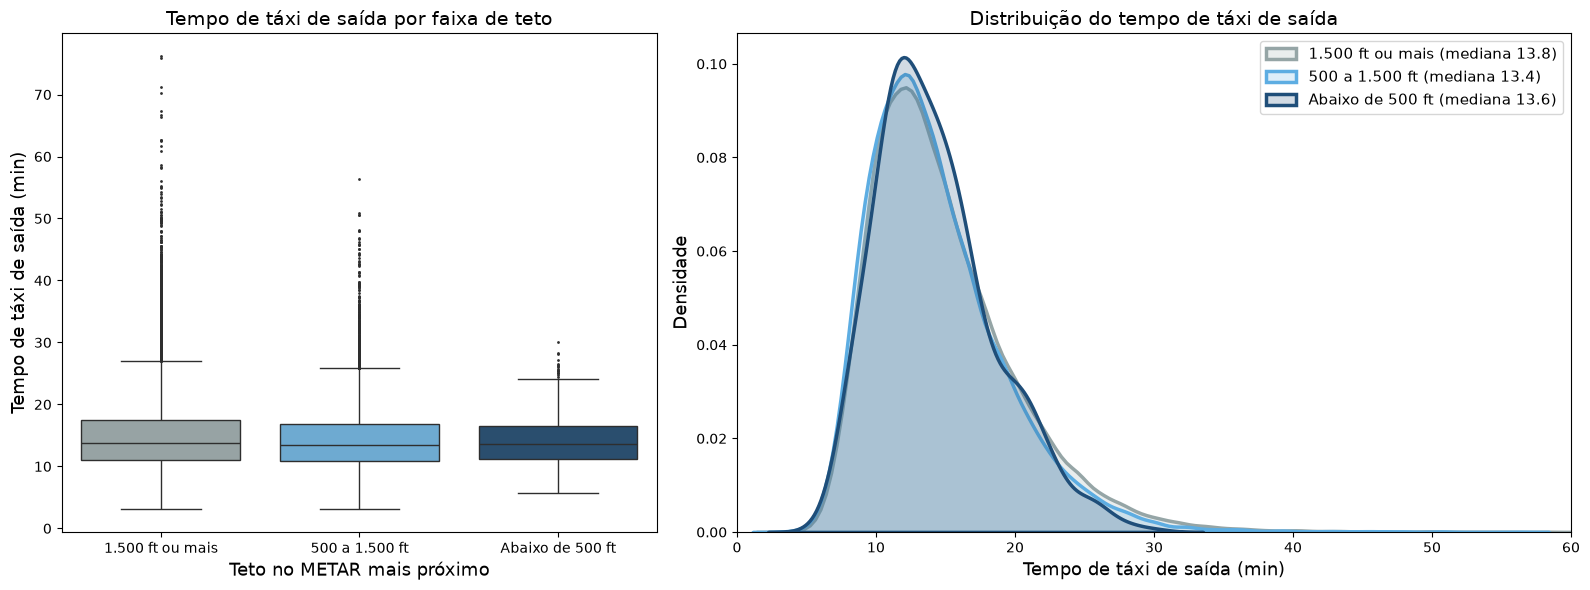

In [35]:
# Nomes para os gráficos e uma cor para cada faixa de teto.
NOMES_TETO = {">=1500": "1.500 ft ou mais", "500_1500": "500 a 1.500 ft", "<500": "Abaixo de 500 ft"}
ORDEM_TETO = ["1.500 ft ou mais", "500 a 1.500 ft", "Abaixo de 500 ft"]
CORES_TETO = ["#95a5a6", "#5dade2", "#1f4e79"]

base["teto_lbl"] = base["teto"].astype(str).map(NOMES_TETO)

# Resumo estatístico de cada faixa.
por_teto = base.groupby("teto_lbl")["taxi_out"]
resumo_teto = pd.DataFrame()
resumo_teto["n"] = por_teto.count()
resumo_teto["% das partidas"] = por_teto.count() / len(base) * 100
resumo_teto["media"] = por_teto.mean()
resumo_teto["mediana"] = por_teto.median()
resumo_teto["p90"] = por_teto.quantile(0.90)
resumo_teto = resumo_teto.reindex(ORDEM_TETO).round(2)
display(resumo_teto)

# Gráficos: boxplot e distribuição.
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.4]})

sns.boxplot(data=base, x="teto_lbl", y="taxi_out", order=ORDEM_TETO, ax=ax[0],
            hue="teto_lbl", hue_order=ORDEM_TETO, palette=CORES_TETO,
            legend=False, fliersize=1)
ax[0].set_xlabel("Teto no METAR mais próximo", fontsize=13)
ax[0].set_ylabel("Tempo de táxi de saída (min)", fontsize=13)
ax[0].set_title("Tempo de táxi de saída por faixa de teto", fontsize=14)

for rotulo, cor in zip(ORDEM_TETO, CORES_TETO):
    grupo = base.loc[base["teto_lbl"] == rotulo, "taxi_out"]
    sns.kdeplot(grupo, ax=ax[1], label=f"{rotulo} (mediana {grupo.median():.1f})",
                color=cor, lw=2.5, fill=True, alpha=0.2)
ax[1].set_xlim(0, 60)
ax[1].set_xlabel("Tempo de táxi de saída (min)", fontsize=13)
ax[1].set_ylabel("Densidade", fontsize=13)
ax[1].set_title("Distribuição do tempo de táxi de saída", fontsize=14)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

,mes,partidas,% 500 a 1.500 ft,% abaixo de 500 ft,mediana (min)
0,1,7973,18.27,0.00,14.73
1,2,7376,4.85,0.00,14.83
2,3,7600,15.01,0.07,12.98
3,4,7478,27.84,1.95,13.38
4,5,7704,14.75,0.32,13.68
5,6,7537,18.60,0.85,14.12
6,7,7861,27.22,1.98,12.62
7,8,7730,27.35,1.00,12.97
8,9,7582,27.80,0.58,13.30
9,10,8065,33.75,1.22,14.20


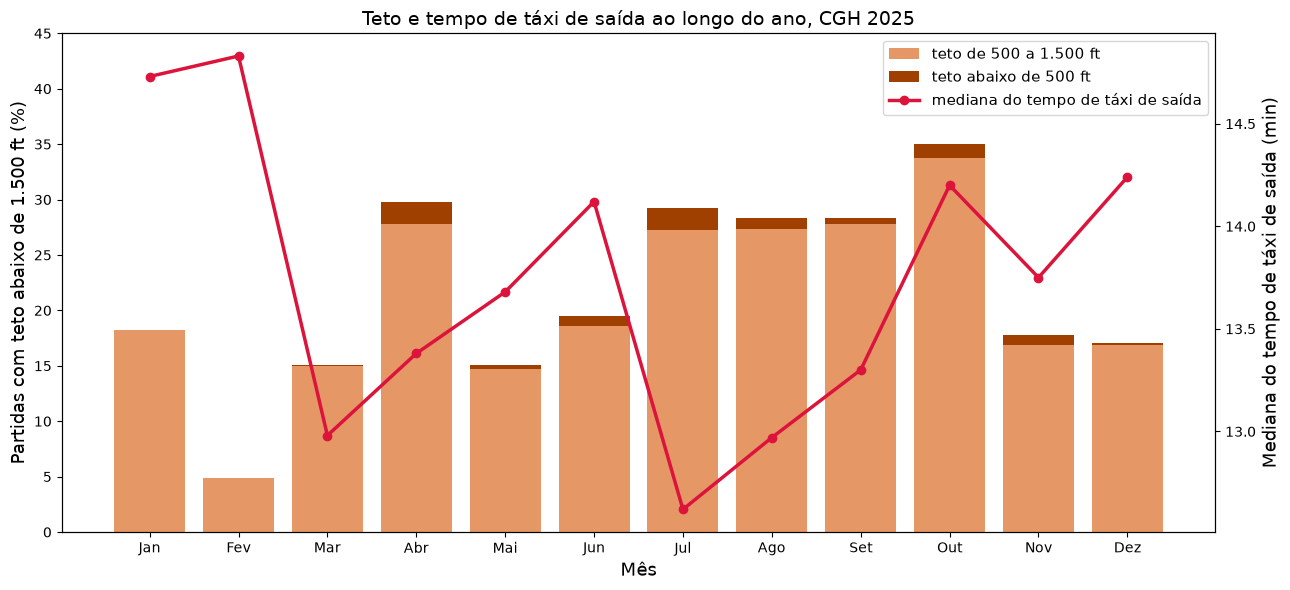

In [36]:
# Teto ao longo do ano: % das partidas de cada mês em cada faixa de teto.
MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

linhas = []
for mes in range(1, 13):
    do_mes = base[base["mes"] == mes]
    linhas.append({"mes": mes,
                   "partidas": len(do_mes),
                   "% 500 a 1.500 ft": (do_mes["teto"] == "500_1500").mean() * 100,
                   "% abaixo de 500 ft": (do_mes["teto"] == "<500").mean() * 100,
                   "mediana (min)": do_mes["taxi_out"].median()})
teto_por_mes = pd.DataFrame(linhas).round(2)
display(teto_por_mes)

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(MESES, teto_por_mes["% 500 a 1.500 ft"], color="#e59866", label="teto de 500 a 1.500 ft")
ax.bar(MESES, teto_por_mes["% abaixo de 500 ft"], bottom=teto_por_mes["% 500 a 1.500 ft"],
       color="#a04000", label="teto abaixo de 500 ft")
ax.set_xlabel("Mês", fontsize=13)
ax.set_ylabel("Partidas com teto abaixo de 1.500 ft (%)", fontsize=13)
ax.set_ylim(0, 45)    # espaço em cima para a legenda não cobrir as barras

# Segundo eixo, à direita, para a mediana do tempo de táxi do mês.
ax2 = ax.twinx()
ax2.plot(MESES, teto_por_mes["mediana (min)"], marker="o", lw=2.5, color="crimson",
         label="mediana do tempo de táxi de saída")
ax2.set_ylabel("Mediana do tempo de táxi de saída (min)", fontsize=13)

# Junta as legendas dos dois eixos numa só.
barras, nomes_barras = ax.get_legend_handles_labels()
linha, nome_linha = ax2.get_legend_handles_labels()
ax.legend(barras + linha, nomes_barras + nome_linha, fontsize=11, loc="upper right")

plt.title(f"Teto e tempo de táxi de saída ao longo do ano, {AEROPORTO.upper()} {ANO}", fontsize=14)
plt.tight_layout()
plt.show()

### 1.3.3 - Tempo Significativo (WX SIGNIFICANT)

In [37]:
# Trovoada: código TS em qualquer grupo de tempo presente.
trovoada = pd.Series(False, index=base.index)
for coluna in ["current_wx1", "current_wx2", "current_wx3"]:
    tem_ts = base[coluna].astype(str).str.contains("TS")
    trovoada = trovoada | tem_ts
base["trovoada"] = trovoada.astype(int)

base["tcu"] = base["tcu"].astype(int)
base["rajada"] = base["wind_gust"].notna().astype(int)
base["chuva_anterior"] = base["chuva_anterior"].astype(int)

print(f"trovoada: {base['trovoada'].sum()}")
print(f"TCU: {base['tcu'].sum()}")
print(f"rajada: {base['rajada'].sum()}")
print(f"chuva nas {CHUVA_MEMORIA_H} h anteriores: {base['chuva_anterior'].sum()}")

trovoada: 1040
TCU: 1695
rajada: 1588
chuva nas 4 h anteriores: 3646


,variável,fenômeno,n,% das partidas,mediana,p90
0,Trovoada,sem,91441,98.88,13.67,21.42
1,Trovoada,com,1040,1.12,17.48,30.38
2,CB,sem,91441,98.88,13.67,21.42
3,CB,com,1040,1.12,17.48,30.38
4,TCU,sem,90786,98.17,13.68,21.48
5,TCU,com,1695,1.83,14.15,23.01
6,Rajada,sem,90893,98.28,13.65,21.40
7,Rajada,com,1588,1.72,16.23,27.13


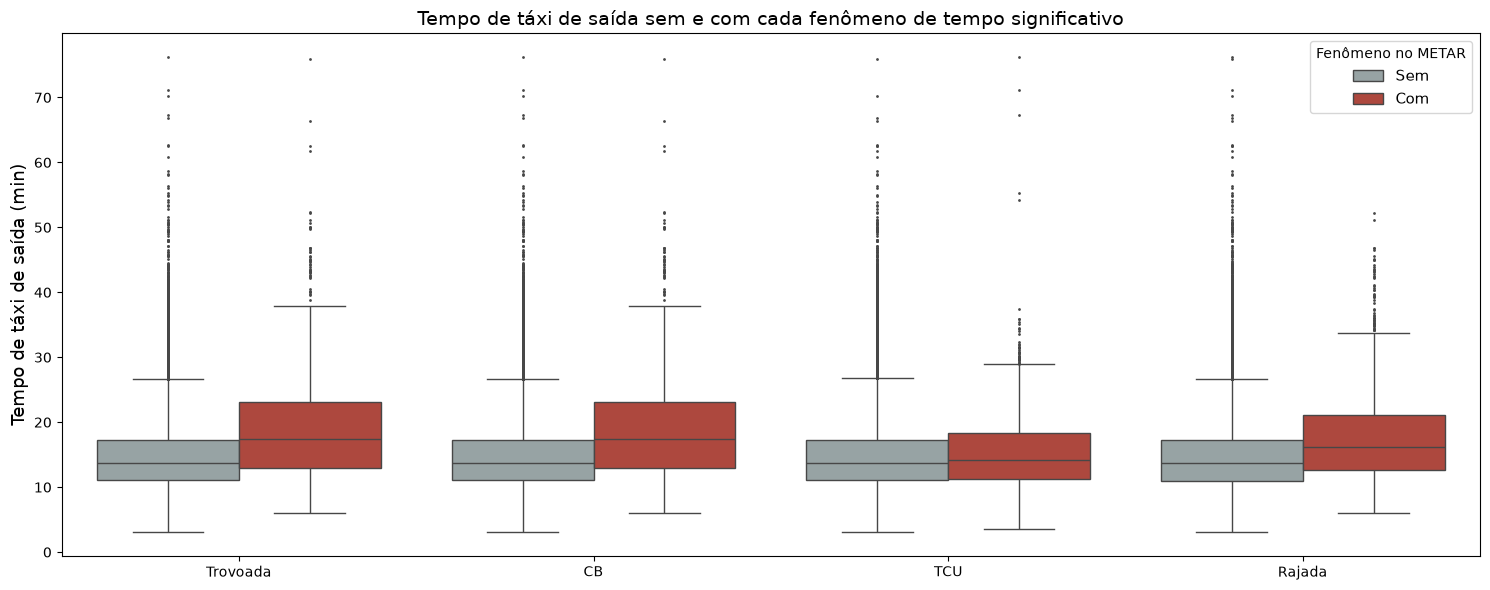

In [38]:
base["cb"] = base["cb"].astype(int)
# Variáveis de tempo significativo: todas valem 1 quando o fenômeno está no METAR.
NOMES_WX = {"trovoada": "Trovoada", "cb": "CB", "tcu": "TCU", "rajada": "Rajada"}

# Resumo de cada variável: sem e com o fenômeno.
linhas = []
for coluna, nome in NOMES_WX.items():
    for valor in [0, 1]:
        grupo = base.loc[base[coluna] == valor, "taxi_out"]
        linhas.append({"variável": nome,
                       "fenômeno": "com" if valor == 1 else "sem",
                       "n": len(grupo),
                       "% das partidas": len(grupo) / len(base) * 100,
                       "mediana": grupo.median(),
                       "p90": grupo.quantile(0.90)})
resumo_wx = pd.DataFrame(linhas).round(2)
display(resumo_wx)

# Uma tabela "longa": cada partida aparece uma vez para cada variável.
partes = []
for coluna, nome in NOMES_WX.items():
    parte = pd.DataFrame()
    parte["taxi_out"] = base["taxi_out"]
    parte["variável"] = nome
    parte["fenômeno"] = base[coluna].map({0: "Sem", 1: "Com"})
    partes.append(parte)
longa = pd.concat(partes, ignore_index=True)

plt.figure(figsize=(15, 6))
sns.boxplot(data=longa, x="variável", y="taxi_out", hue="fenômeno",
            order=list(NOMES_WX.values()), hue_order=["Sem", "Com"],
            palette=["#95a5a6", "#c0392b"], fliersize=1)
plt.xlabel("")
plt.ylabel("Tempo de táxi de saída (min)", fontsize=13)
plt.title("Tempo de táxi de saída sem e com cada fenômeno de tempo significativo", fontsize=14)
plt.legend(title="Fenômeno no METAR", fontsize=11)
plt.tight_layout()
plt.show()

,mes,partidas,% Trovoada,% TCU,% Rajada,mediana (min)
0,1,7973,2.78,5.18,1.22,14.73
1,2,7376,4.09,9.10,0.76,14.83
2,3,7600,1.78,3.00,0.37,12.98
3,4,7478,0.82,1.27,0.44,13.38
4,5,7704,0.44,0.01,2.00,13.68
5,6,7537,0.12,0.00,0.69,14.12
6,7,7861,0.00,0.00,2.37,12.62
7,8,7730,0.00,0.23,0.62,12.97
8,9,7582,0.70,0.00,3.57,13.30
9,10,8065,0.29,0.89,1.84,14.20


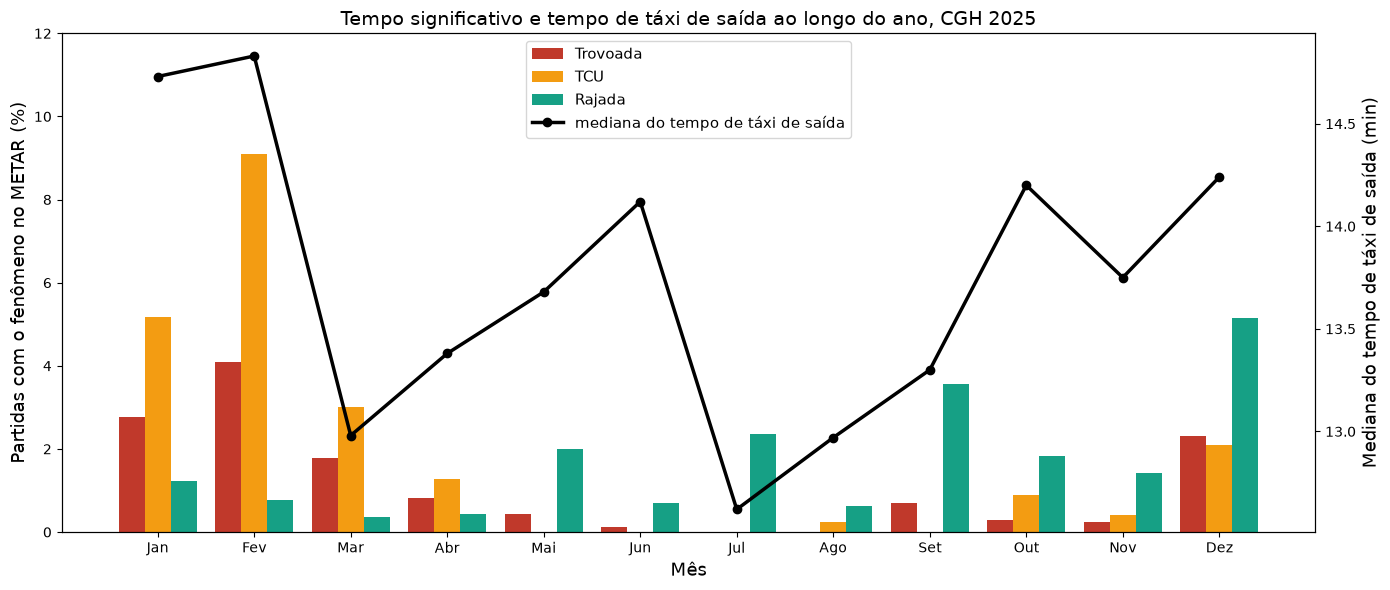

In [39]:
# Tempo significativo ao longo do ano: % das partidas de cada mês com cada fenômeno.
WX_SIG = {"trovoada": "Trovoada", "tcu": "TCU", "rajada": "Rajada"}
CORES_WX = ["#c0392b", "#f39c12", "#16a085"]
MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

linhas = []
for mes in range(1, 13):
    do_mes = base[base["mes"] == mes]
    linha = {"mes": mes, "partidas": len(do_mes)}
    for coluna, nome in WX_SIG.items():
        linha[f"% {nome}"] = do_mes[coluna].mean() * 100
    linha["mediana (min)"] = do_mes["taxi_out"].median()
    linhas.append(linha)
wx_por_mes = pd.DataFrame(linhas).round(2)
display(wx_por_mes)

# Barras lado a lado: cada fenômeno é deslocado um pouco para a direita.
posicoes = np.arange(12)
largura = 0.27

fig, ax = plt.subplots(figsize=(14, 6))
for i, (coluna, nome) in enumerate(WX_SIG.items()):
    ax.bar(posicoes + (i - 1) * largura, wx_por_mes[f"% {nome}"], width=largura,
           color=CORES_WX[i], label=nome)
ax.set_xticks(posicoes)
ax.set_xticklabels(MESES)
ax.set_xlabel("Mês", fontsize=13)
ax.set_ylabel("Partidas com o fenômeno no METAR (%)", fontsize=13)
ax.set_ylim(0, 12)    # espaço em cima para a legenda

# Segundo eixo, à direita, para a mediana do tempo de táxi do mês.
ax2 = ax.twinx()
ax2.plot(posicoes, wx_por_mes["mediana (min)"], marker="o", lw=2.5, color="black",
         label="mediana do tempo de táxi de saída")
ax2.set_ylabel("Mediana do tempo de táxi de saída (min)", fontsize=13)

barras, nomes_barras = ax.get_legend_handles_labels()
linha, nome_linha = ax2.get_legend_handles_labels()
ax.legend(barras + linha, nomes_barras + nome_linha, fontsize=11, loc="upper center")

plt.title(f"Tempo significativo e tempo de táxi de saída ao longo do ano, {AEROPORTO.upper()} {ANO}", fontsize=14)
plt.tight_layout()
plt.show()

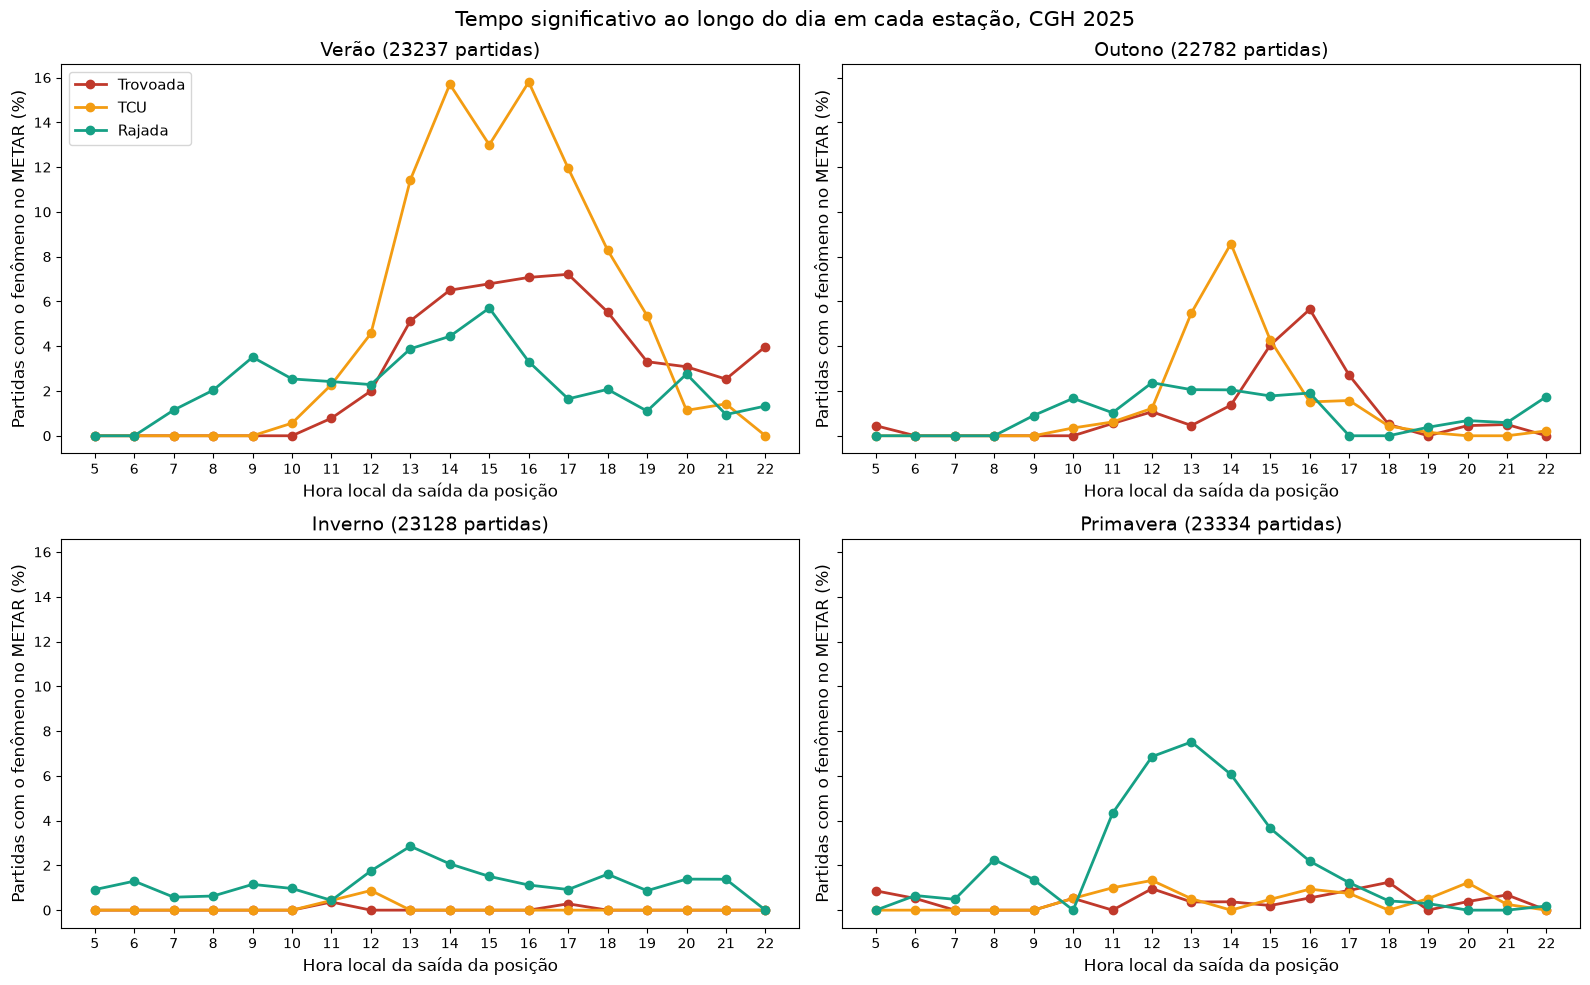

In [40]:
# Tempo significativo ao longo do dia, em cada estação.
fig, eixos = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
eixos = eixos.flatten()

for i, estacao in enumerate(ORDEM_ESTACAO_ANO):
    da_estacao = base[base["estacao"] == estacao]
    ax = eixos[i]

    for j, (coluna, nome) in enumerate(WX_SIG.items()):
        # % das partidas com o fenômeno em cada hora.
        por_hora = []
        for h in HORAS:
            da_hora = da_estacao[da_estacao["hora"] == h]
            por_hora.append(da_hora[coluna].mean() * 100)
        ax.plot(HORAS, por_hora, marker="o", lw=2, color=CORES_WX[j], label=nome)

    ax.set_title(f"{estacao} ({len(da_estacao)} partidas)", fontsize=14)
    ax.set_xticks(HORAS)
    ax.set_xlabel("Hora local da saída da posição", fontsize=12)
    ax.set_ylabel("Partidas com o fenômeno no METAR (%)", fontsize=12)

eixos[0].legend(fontsize=11, loc="upper left")
plt.suptitle(f"Tempo significativo ao longo do dia em cada estação, {AEROPORTO.upper()} {ANO}", fontsize=15)
plt.tight_layout()
plt.show()

,fenômeno,estação,partidas com,dif. mediana (min),dif. P90 (min)
0,Trovoada,Verão,707,3.42,7.82
1,Trovoada,Outono,230,3.55,7.97
2,Trovoada,Inverno,9,2.03,3.13
3,Trovoada,Primavera,94,3.95,7.83
4,TCU,Verão,1250,-0.05,1.13
5,TCU,Outono,324,-0.48,-1.37
6,TCU,Inverno,18,-3.92,-6.29
7,TCU,Primavera,103,1.50,1.58
8,Rajada,Verão,559,1.43,6.25
9,Rajada,Outono,215,4.23,8.04


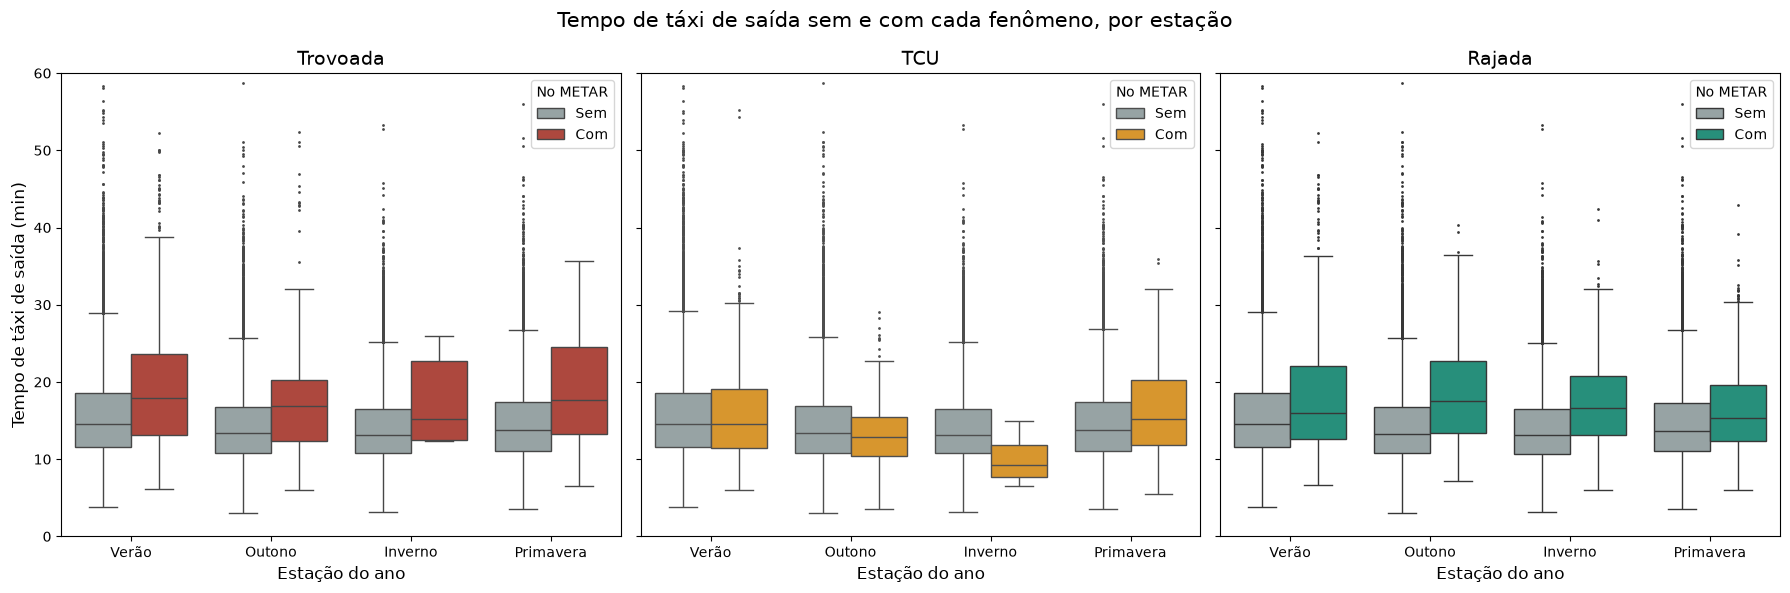

In [41]:
# O efeito de cada fenômeno muda com a estação?
linhas = []
for coluna, nome in WX_SIG.items():
    for estacao in ORDEM_ESTACAO_ANO:
        da_estacao = base[base["estacao"] == estacao]
        com = da_estacao.loc[da_estacao[coluna] == 1, "taxi_out"]
        sem = da_estacao.loc[da_estacao[coluna] == 0, "taxi_out"]
        linhas.append({"fenômeno": nome, "estação": estacao,
                       "partidas com": len(com),
                       "dif. mediana (min)": com.median() - sem.median(),
                       "dif. P90 (min)": com.quantile(0.90) - sem.quantile(0.90)})
display(pd.DataFrame(linhas).round(2))

fig, eixos = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for i, (coluna, nome) in enumerate(WX_SIG.items()):
    rotulo = base[coluna].map({0: "Sem", 1: "Com"})
    sns.boxplot(x=base["estacao"], y=base["taxi_out"], hue=rotulo,
                order=ORDEM_ESTACAO_ANO, hue_order=["Sem", "Com"],
                palette=["#95a5a6", CORES_WX[i]], fliersize=1, ax=eixos[i])
    eixos[i].set_ylim(0, 60)
    eixos[i].set_title(nome, fontsize=14)
    eixos[i].set_xlabel("Estação do ano", fontsize=12)
    eixos[i].set_ylabel("Tempo de táxi de saída (min)", fontsize=12)
    eixos[i].legend(title="No METAR", fontsize=10)

plt.suptitle("Tempo de táxi de saída sem e com cada fenômeno, por estação", fontsize=15)
plt.tight_layout()
plt.show()

#### 1.3.4 - Visibilidade

In [42]:
# Visibilidade em três faixas. 5.000 m é o mínimo do voo visual (ICA 100-12)
# e 2.100 m é o mínimo da aproximação RNAV de Congonhas.
visibilidade = pd.Series(">=5000", index=base.index)
visibilidade[base["visibility"] < 5000] = "2100_5000"
visibilidade[base["visibility"] < 2100] = "<2100"
base["visibilidade"] = pd.Categorical(visibilidade, categories=[">=5000", "2100_5000", "<2100"])

print(base["visibilidade"].value_counts().to_dict())
print(f"partidas sem visibilidade no METAR: {base['visibility'].isna().sum()}")

{'>=5000': 91173, '2100_5000': 1253, '<2100': 55}
partidas sem visibilidade no METAR: 0


,n,% das partidas,media,mediana,p90
visibilidade_lbl,,,,,
5.000 m ou mais,91173,98.59,14.71,13.68,21.48
2.100 a 5.000 m,1253,1.35,15.70,14.48,23.40
Abaixo de 2.100 m,55,0.06,15.65,13.62,22.36


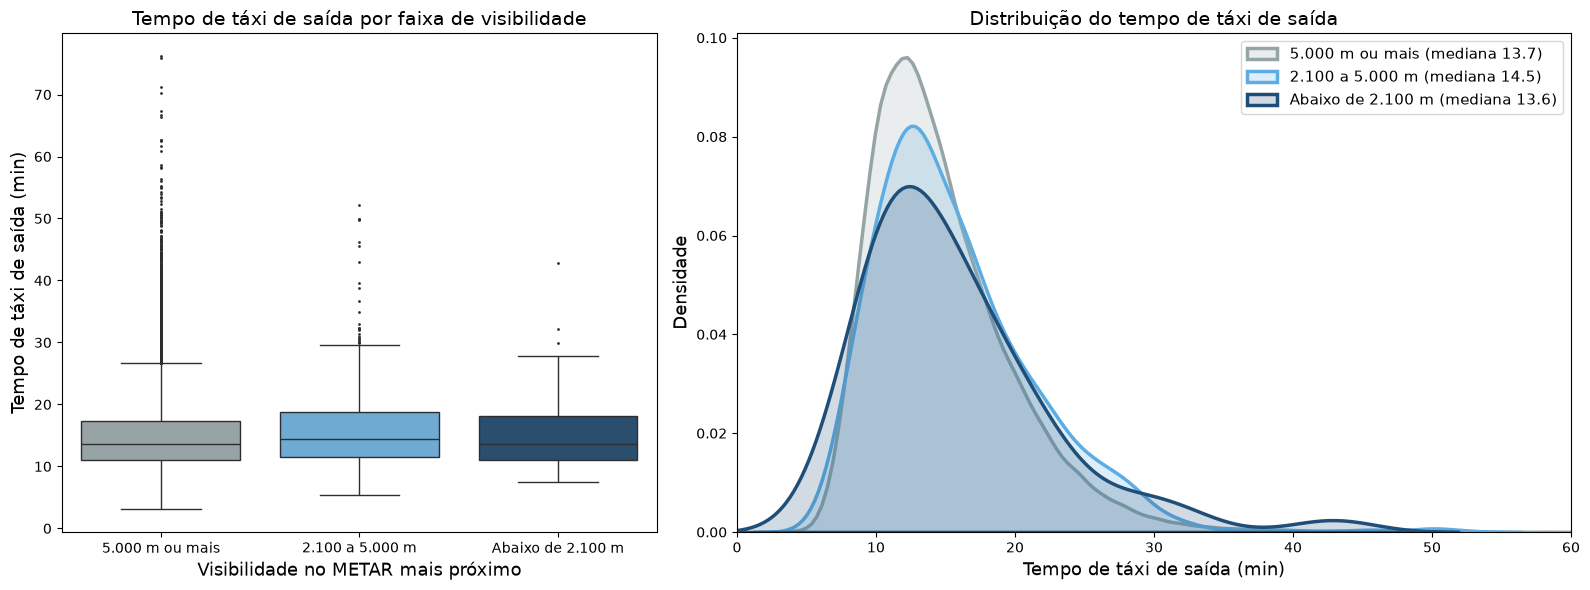

In [43]:
# Nomes para os gráficos e uma cor para cada faixa de visibilidade.
NOMES_VIS = {">=5000": "5.000 m ou mais", "2100_5000": "2.100 a 5.000 m", "<2100": "Abaixo de 2.100 m"}
ORDEM_VIS = ["5.000 m ou mais", "2.100 a 5.000 m", "Abaixo de 2.100 m"]
CORES_VIS = ["#95a5a6", "#5dade2", "#1f4e79"]

base["visibilidade_lbl"] = base["visibilidade"].astype(str).map(NOMES_VIS)

# Resumo estatístico de cada faixa.
por_vis = base.groupby("visibilidade_lbl")["taxi_out"]
resumo_vis = pd.DataFrame()
resumo_vis["n"] = por_vis.count()
resumo_vis["% das partidas"] = por_vis.count() / len(base) * 100
resumo_vis["media"] = por_vis.mean()
resumo_vis["mediana"] = por_vis.median()
resumo_vis["p90"] = por_vis.quantile(0.90)
resumo_vis = resumo_vis.reindex(ORDEM_VIS).round(2)
display(resumo_vis)

# Gráficos: boxplot e distribuição.
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.4]})

sns.boxplot(data=base, x="visibilidade_lbl", y="taxi_out", order=ORDEM_VIS, ax=ax[0],
            hue="visibilidade_lbl", hue_order=ORDEM_VIS, palette=CORES_VIS,
            legend=False, fliersize=1)
ax[0].set_xlabel("Visibilidade no METAR mais próximo", fontsize=13)
ax[0].set_ylabel("Tempo de táxi de saída (min)", fontsize=13)
ax[0].set_title("Tempo de táxi de saída por faixa de visibilidade", fontsize=14)

for rotulo, cor in zip(ORDEM_VIS, CORES_VIS):
    grupo = base.loc[base["visibilidade_lbl"] == rotulo, "taxi_out"]
    sns.kdeplot(grupo, ax=ax[1], label=f"{rotulo} (mediana {grupo.median():.1f})",
                color=cor, lw=2.5, fill=True, alpha=0.2)
ax[1].set_xlim(0, 60)
ax[1].set_xlabel("Tempo de táxi de saída (min)", fontsize=13)
ax[1].set_ylabel("Densidade", fontsize=13)
ax[1].set_title("Distribuição do tempo de táxi de saída", fontsize=14)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

## 1.4 Pista

A cabeceira em uso é a pista registrada pelo CGNA, sem o L ou R, porque o que
importa ao táxi é o sentido de operação.

A troca de cabeceira é lida na ordem das decolagens, porque a pista registrada é a
da decolagem. Ela é contada quando três partidas seguidas saem pela cabeceira oposta
(parâmetro `TROCA_PARTIDAS`), para que um registro isolado não crie uma troca que não
houve. A contagem recomeça a cada dia, e a virada da noite não conta como troca. 
A variável marca as partidas que decolaram até 60 minutos depois da troca (parâmetro 
`JANELA_TROCA_MIN`), enquanto a fila se reorganiza.

O vento é classificado em relação à cabeceira da decolagem. Quando tem componente de
cauda, a partida fica na categoria "cauda", qualquer que seja a intensidade. Sem
componente de cauda, ela é separada pela intensidade do METAR, em faixas definidas
pelo parâmetro `VENTO_CORTES`. Os cortes adotados, 10 e 20 nós, foram escolhidos pela
comparação de modelos com cortes diferentes (seção 1.4.3).

In [44]:
# Troca de cabeceira: partidas seguidas que confirmam a troca e minutos marcados depois dela.
TROCA_PARTIDAS = 3
JANELA_TROCA_MIN = 60

### 1.4.1 - Cabeceira 17 ou 35

In [45]:
# "17R" vira "17" e "35L" vira "35".
base["cabeceira"] = base["pista"].astype(str).str[:2]
print(base["cabeceira"].value_counts().to_dict())

{'17': 62909, '35': 29572}


### 1.4.1.1 Pista x Meteorologia

,fenômeno,cabeceira,% das partidas,partidas com,dif. mediana (min)
0,Chuva,17,4.54,2854,1.52
1,Chuva,35,6.06,1793,2.13
2,Chuva nas 4 h ant.,17,3.42,2152,2.54
3,Chuva nas 4 h ant.,35,5.05,1494,3.62
4,Trovoada,17,1.24,779,4.25
5,Trovoada,35,0.88,261,2.88
6,TCU,17,1.79,1129,0.83
7,TCU,35,1.91,566,-0.87
8,Rajada,17,0.55,347,1.07
9,Rajada,35,4.20,1241,1.65


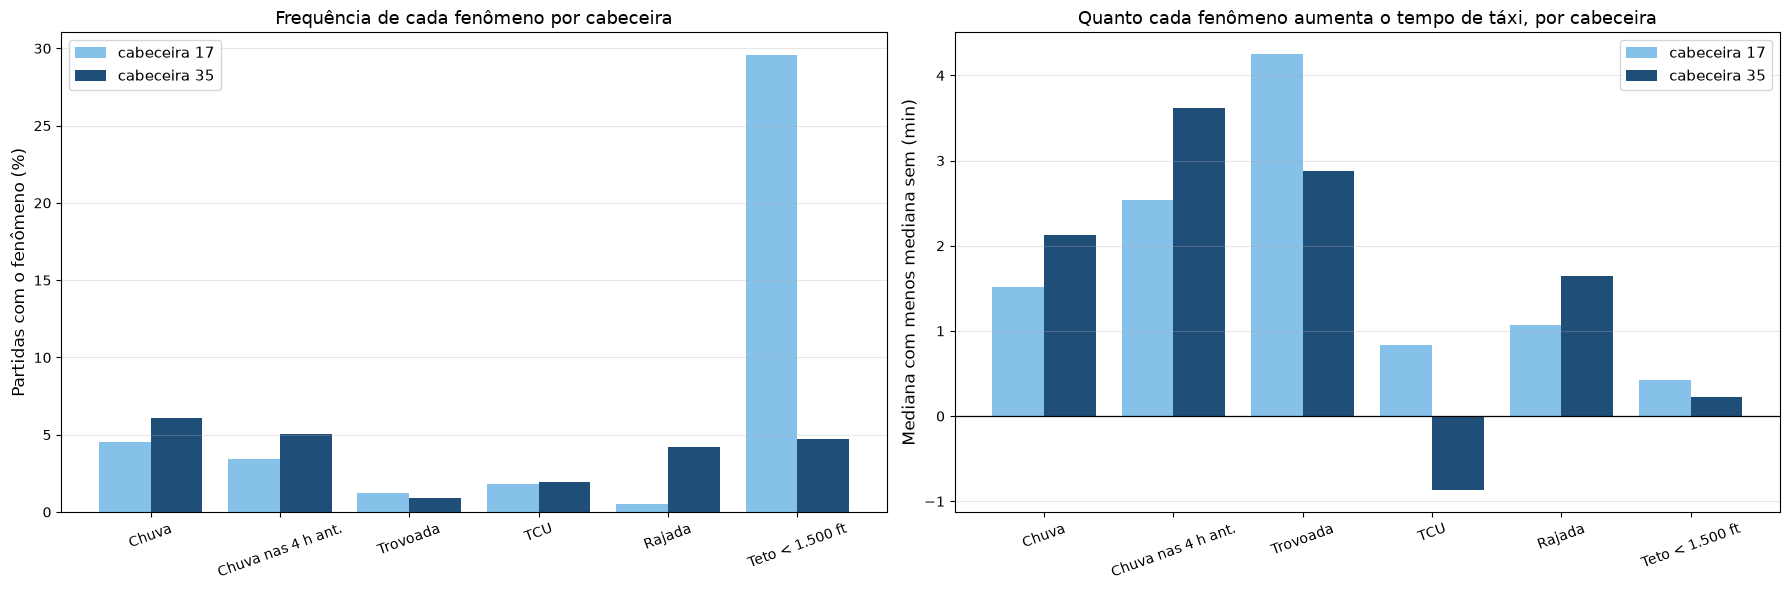

In [46]:
# Tempo significativo e cabeceira: com que frequência cada fenômeno aparece em cada
# cabeceira, e quanto ele pesa no tempo de táxi de cada uma.
base["com_chuva"] = (base["chuva"] != "sem").astype(int)
base["teto_baixo"] = (base["teto"] != ">=1500").astype(int)

FENOMENOS = {"com_chuva": "Chuva", "chuva_anterior": f"Chuva nas {CHUVA_MEMORIA_H} h ant.",
             "trovoada": "Trovoada", "tcu": "TCU", "rajada": "Rajada",
             "teto_baixo": "Teto < 1.500 ft"}
CORES_CAB = {"17": "#85c1e9", "35": "#1f4e79"}

linhas = []
for coluna, nome in FENOMENOS.items():
    for cabeceira in ["17", "35"]:
        da_cabeceira = base[base["cabeceira"] == cabeceira]
        com = da_cabeceira.loc[da_cabeceira[coluna] == 1, "taxi_out"]
        sem = da_cabeceira.loc[da_cabeceira[coluna] == 0, "taxi_out"]
        linhas.append({"fenômeno": nome, "cabeceira": cabeceira,
                       "% das partidas": len(com) / len(da_cabeceira) * 100,
                       "partidas com": len(com),
                       "dif. mediana (min)": com.median() - sem.median()})
wx_cabeceira = pd.DataFrame(linhas).round(2)
display(wx_cabeceira)

posicoes = np.arange(len(FENOMENOS))
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
for j, cabeceira in enumerate(["17", "35"]):
    da_cabeceira = wx_cabeceira[wx_cabeceira["cabeceira"] == cabeceira]
    deslocamento = (j - 0.5) * 0.4
    ax[0].bar(posicoes + deslocamento, da_cabeceira["% das partidas"], width=0.4,
              color=CORES_CAB[cabeceira], label=f"cabeceira {cabeceira}")
    ax[1].bar(posicoes + deslocamento, da_cabeceira["dif. mediana (min)"], width=0.4,
              color=CORES_CAB[cabeceira], label=f"cabeceira {cabeceira}")

ax[0].set_ylabel("Partidas com o fenômeno (%)", fontsize=12)
ax[0].set_title("Frequência de cada fenômeno por cabeceira", fontsize=13)
ax[1].set_ylabel("Mediana com menos mediana sem (min)", fontsize=12)
ax[1].set_title("Quanto cada fenômeno aumenta o tempo de táxi, por cabeceira", fontsize=13)
ax[1].axhline(0, color="black", lw=0.9)
for eixo in ax:
    eixo.set_xticks(posicoes)
    eixo.set_xticklabels(list(FENOMENOS.values()), rotation=20)
    eixo.legend(fontsize=11)
    eixo.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

#### 1.4.1.2 Pista x Calendario

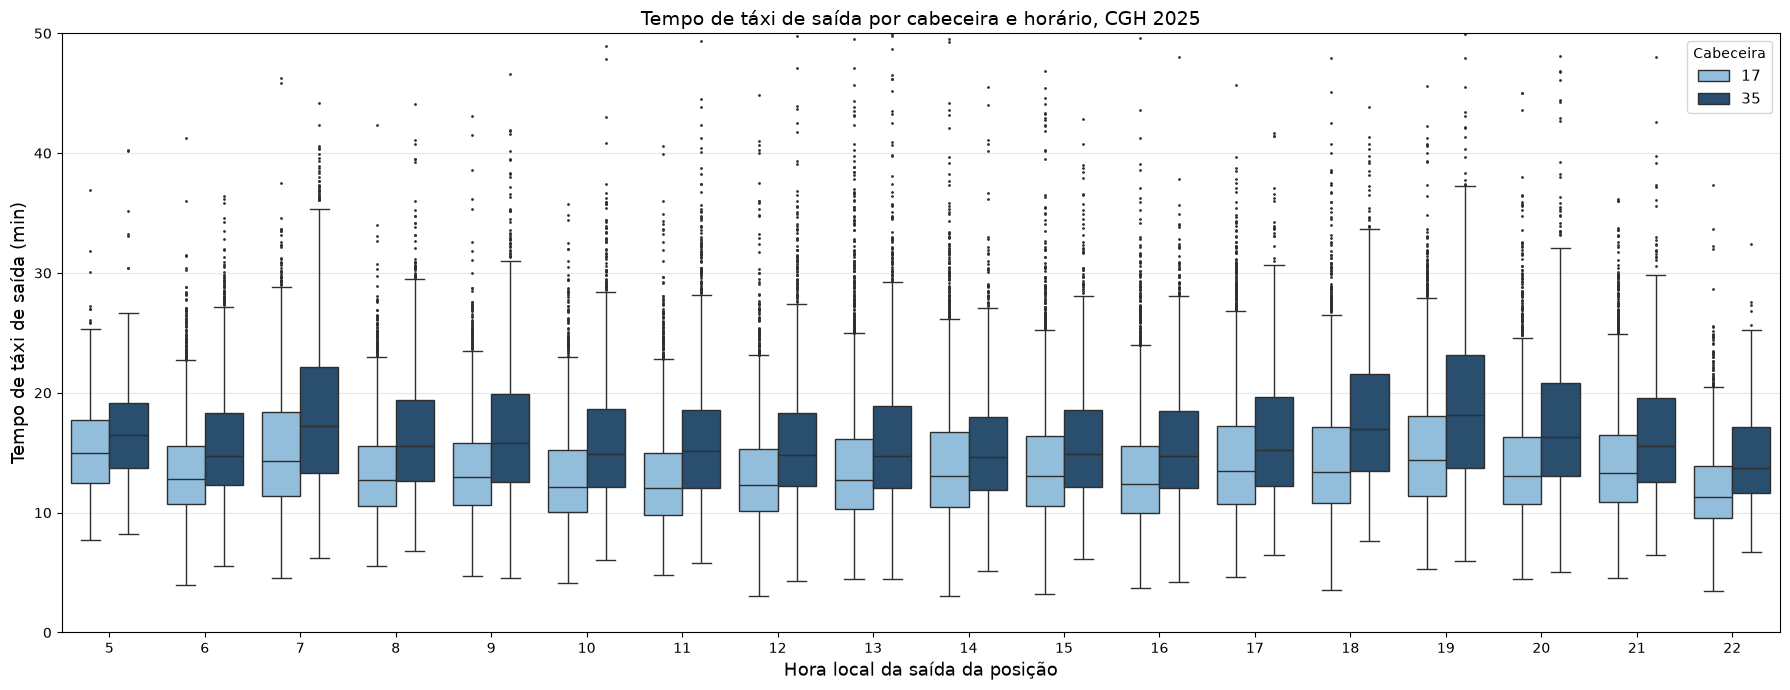

,hora,partidas 17,mediana 17,p90 17,partidas 35,mediana 35,p90 35,dif. mediana (35 - 17)
0,5,576,15.0,20.5,302,16.5,22.2,1.5
1,6,3868,12.8,18.6,2215,14.7,22.0,1.9
2,7,3459,14.3,22.3,2155,17.2,27.7,2.9
3,8,4081,12.7,18.5,2724,15.5,22.9,2.8
4,9,3361,13.0,19.2,2411,15.8,24.1,2.8
5,10,3175,12.2,18.3,2456,14.9,23.1,2.8
6,11,3314,12.0,18.5,2552,15.1,23.0,3.1
7,12,2995,12.3,18.9,2437,14.8,22.2,2.5
8,13,3121,12.8,21.2,2256,14.8,23.8,2.0
9,14,3448,13.1,21.0,1869,14.7,21.6,1.6


In [47]:
# Tempo de táxi de saída de cada cabeceira, hora a hora.
HORAS = list(range(base["hora"].min(), base["hora"].max() + 1))

fig, ax = plt.subplots(figsize=(18, 7))
sns.boxplot(data=base, x="hora", y="taxi_out", hue="cabeceira",
            order=HORAS, hue_order=["17", "35"],
            palette=[CORES_CAB["17"], CORES_CAB["35"]], fliersize=1, ax=ax)
ax.set_ylim(0, 50)
ax.set_xlabel("Hora local da saída da posição", fontsize=13)
ax.set_ylabel("Tempo de táxi de saída (min)", fontsize=13)
ax.set_title(f"Tempo de táxi de saída por cabeceira e horário, {AEROPORTO.upper()} {ANO}", fontsize=14)
ax.legend(title="Cabeceira", fontsize=11)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Tabela: partidas, mediana e P90 de cada cabeceira em cada hora.
linhas = []
for h in HORAS:
    linha = {"hora": h}
    for cabeceira in ["17", "35"]:
        grupo = base.loc[(base["hora"] == h) & (base["cabeceira"] == cabeceira), "taxi_out"]
        linha[f"partidas {cabeceira}"] = len(grupo)
        linha[f"mediana {cabeceira}"] = grupo.median()
        linha[f"p90 {cabeceira}"] = grupo.quantile(0.90)
    linha["dif. mediana (35 - 17)"] = linha["mediana 35"] - linha["mediana 17"]
    linhas.append(linha)
taxi_cabeceira_hora = pd.DataFrame(linhas).round(1)
display(taxi_cabeceira_hora)

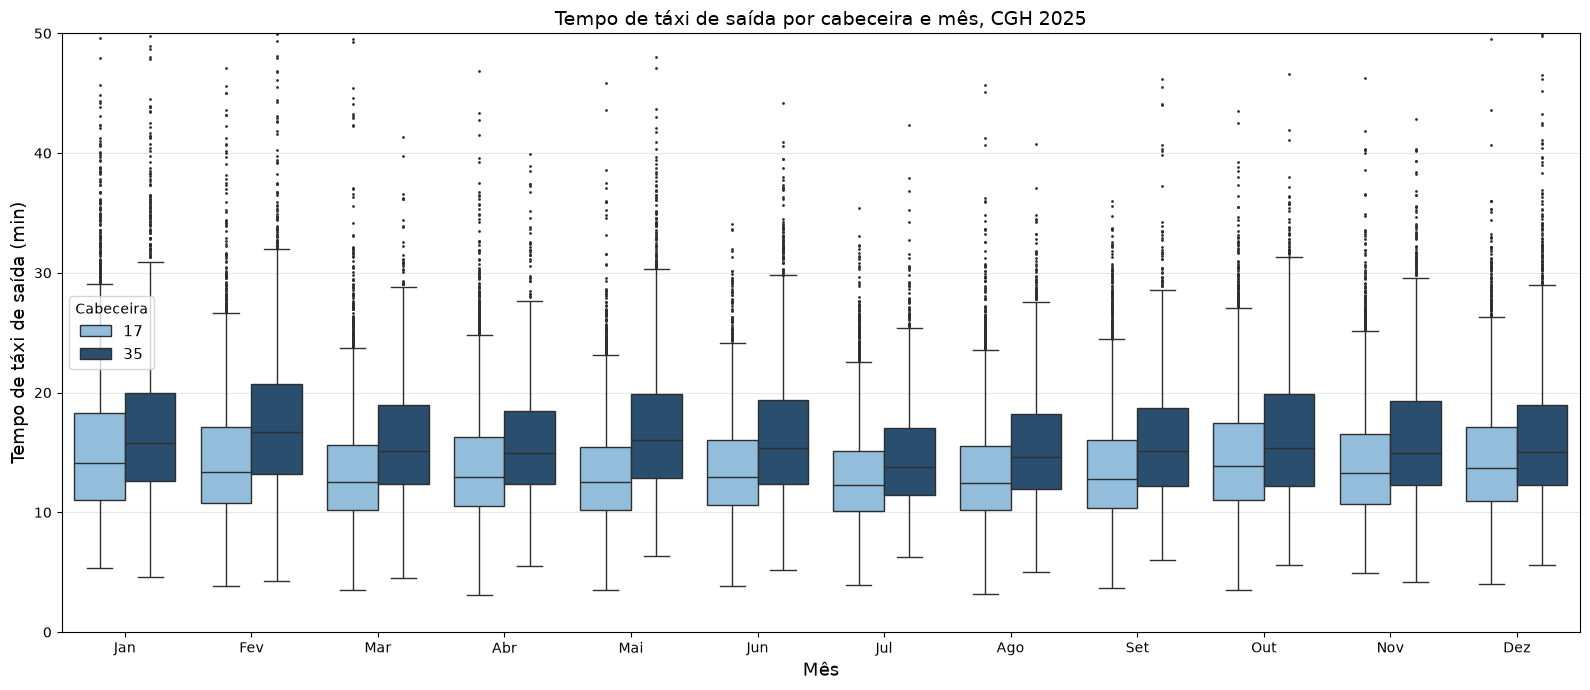

,mes,partidas 17,mediana 17,p90 17,partidas 35,mediana 35,p90 35,dif. mediana (35 - 17)
0,Jan,5089,14.1,23.4,2884,15.8,25.1,1.7
1,Fev,3907,13.4,21.4,3469,16.7,25.3,3.3
2,Mar,6150,12.6,19.4,1450,15.1,22.4,2.5
3,Abr,5888,12.9,20.0,1590,15.0,22.4,2.0
4,Mai,4714,12.6,18.7,2990,16.0,24.8,3.5
5,Jun,3628,13.0,19.4,3909,15.4,23.3,2.4
6,Jul,6026,12.3,18.3,1835,13.8,20.9,1.5
7,Ago,5823,12.5,19.3,1907,14.6,22.2,2.2
8,Set,5846,12.8,19.4,1736,15.1,23.0,2.3
9,Out,6058,13.9,21.4,2007,15.4,24.3,1.5


In [48]:
# Tempo de táxi de saída de cada cabeceira, mês a mês.
MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

fig, ax = plt.subplots(figsize=(16, 7))
sns.boxplot(data=base, x="mes", y="taxi_out", hue="cabeceira",
            order=list(range(1, 13)), hue_order=["17", "35"],
            palette=[CORES_CAB["17"], CORES_CAB["35"]], fliersize=1, ax=ax)
ax.set_xticks(range(12))
ax.set_xticklabels(MESES)
ax.set_ylim(0, 50)
ax.set_xlabel("Mês", fontsize=13)
ax.set_ylabel("Tempo de táxi de saída (min)", fontsize=13)
ax.set_title(f"Tempo de táxi de saída por cabeceira e mês, {AEROPORTO.upper()} {ANO}", fontsize=14)
ax.legend(title="Cabeceira", fontsize=11)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Tabela: partidas, mediana e P90 de cada cabeceira em cada mês.
linhas = []
for mes in range(1, 13):
    linha = {"mes": MESES[mes - 1]}
    for cabeceira in ["17", "35"]:
        grupo = base.loc[(base["mes"] == mes) & (base["cabeceira"] == cabeceira), "taxi_out"]
        linha[f"partidas {cabeceira}"] = len(grupo)
        linha[f"mediana {cabeceira}"] = grupo.median()
        linha[f"p90 {cabeceira}"] = grupo.quantile(0.90)
    linha["dif. mediana (35 - 17)"] = linha["mediana 35"] - linha["mediana 17"]
    linhas.append(linha)
taxi_cabeceira_mes = pd.DataFrame(linhas).round(1)
display(taxi_cabeceira_mes)

### 1.4.2 - Troca de cabeceira

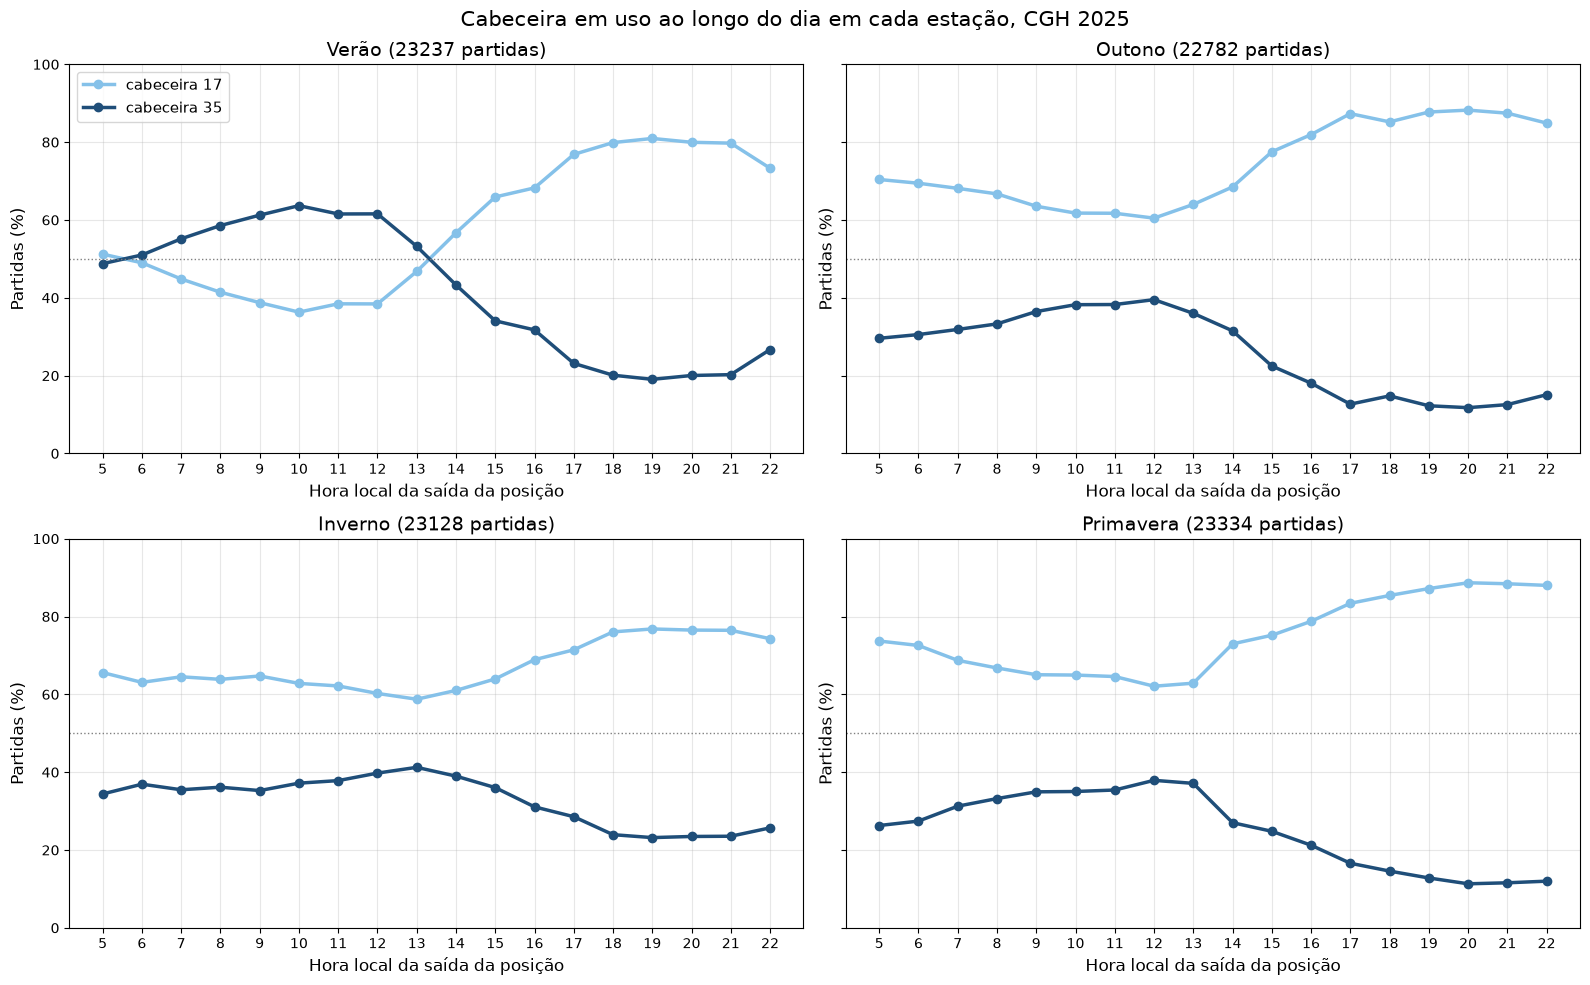

,Verão,Outono,Inverno,Primavera
5,48.8,29.6,34.4,26.3
6,51.0,30.6,36.9,27.4
7,55.2,31.9,35.5,31.3
8,58.6,33.3,36.1,33.2
9,61.2,36.5,35.3,35.0
10,63.7,38.2,37.2,35.0
11,61.5,38.3,37.8,35.4
12,61.6,39.5,39.8,37.9
13,53.2,36.0,41.2,37.1
14,43.3,31.5,39.0,27.0


In [49]:
# Hora local da saída da posição (depois das 23h entra nas 22h, como no bloco).
hora = base["AOBT"].dt.tz_convert(TZ).dt.hour
hora[hora >= 23] = 22
base["hora"] = hora
HORAS = list(range(base["hora"].min(), base["hora"].max() + 1))

fig, eixos = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
eixos = eixos.flatten()
tabela = {}

for i, estacao in enumerate(ORDEM_ESTACAO_ANO):
    da_estacao = base[base["estacao"] == estacao]

    # % das partidas na 35 em cada hora (o resto é a 17).
    na_35 = []
    for h in HORAS:
        da_hora = da_estacao[da_estacao["hora"] == h]
        na_35.append((da_hora["cabeceira"] == "35").mean() * 100)
    na_17 = [100 - valor for valor in na_35]
    tabela[estacao] = na_35

    ax = eixos[i]
    ax.plot(HORAS, na_17, marker="o", lw=2.5, color="#85c1e9", label="cabeceira 17")
    ax.plot(HORAS, na_35, marker="o", lw=2.5, color="#1f4e79", label="cabeceira 35")
    ax.axhline(50, color="gray", ls=":", lw=1)
    ax.set_ylim(0, 100)
    ax.set_xticks(HORAS)
    ax.set_title(f"{estacao} ({len(da_estacao)} partidas)", fontsize=14)
    ax.set_xlabel("Hora local da saída da posição", fontsize=12)
    ax.set_ylabel("Partidas (%)", fontsize=12)
    ax.grid(alpha=0.3)

eixos[0].legend(fontsize=11, loc="upper left")
plt.suptitle(f"Cabeceira em uso ao longo do dia em cada estação, {AEROPORTO.upper()} {ANO}", fontsize=15)
plt.tight_layout()
plt.show()

# A mesma informação em tabela: % das partidas na cabeceira 35.
pd.DataFrame(tabela, index=HORAS).round(1)

In [50]:
# A troca é lida na ordem das decolagens, porque a pista registrada é a da decolagem.
base = base.sort_values("ATOT").reset_index(drop=True)
cabeceiras = list(base["cabeceira"])
datas = list(base["ATOT"].dt.tz_convert(TZ).dt.date)

# A cabeceira "atual" só muda quando as TROCA_PARTIDAS partidas seguintes confirmam.
# Cada dia recomeça a contagem pela maioria das primeiras decolagens, e a virada
# do dia não conta como troca.
atual = cabeceiras[0]
houve_troca = []

for i in range(len(cabeceiras)):
    novo_dia = i == 0 or datas[i] != datas[i - 1]

    if novo_dia:
        primeiras = cabeceiras[i:i + TROCA_PARTIDAS]
        if primeiras.count("17") >= primeiras.count("35"):
            atual = "17"
        else:
            atual = "35"
        houve_troca.append(False)
    else:
        proximas = cabeceiras[i:i + TROCA_PARTIDAS]
        confirmada = proximas.count(cabeceiras[i]) == TROCA_PARTIDAS
        if cabeceiras[i] != atual and confirmada:
            atual = cabeceiras[i]
            houve_troca.append(True)
        else:
            houve_troca.append(False)

print(f"trocas de cabeceira no ano: {sum(houve_troca)}")

# Marca as partidas que decolaram até JANELA_TROCA_MIN minutos depois da última troca,
# e guarda o instante dessa troca para corrigir o vento mais adiante.
janela_troca = pd.Timedelta(minutes=JANELA_TROCA_MIN)
ultima_troca = None
troca_cabeceira = []
instante_troca = []

for momento, trocou in zip(base["ATOT"], houve_troca):
    if trocou:
        ultima_troca = momento
    if ultima_troca is not None and momento - ultima_troca < janela_troca:
        troca_cabeceira.append(1)
        instante_troca.append(ultima_troca)
    else:
        troca_cabeceira.append(0)
        instante_troca.append(pd.NaT)

# Grava as colunas ainda na ordem do ATOT, para cada valor ficar na sua partida.
base["troca_cabeceira"] = troca_cabeceira
base["instante_troca"] = instante_troca
base["houve_troca"] = houve_troca

# Agora sim, volta para a ordem de saída da posição.
base = base.sort_values("AOBT").reset_index(drop=True)
print(f"partidas até {JANELA_TROCA_MIN} min depois de uma troca: {base['troca_cabeceira'].sum()}")

trocas de cabeceira no ano: 245
partidas até 60 min depois de uma troca: 3794


In [51]:
# Quantas trocas aparecem para cada número de partidas exigido na confirmação.
N_MAX = 20

# Uma cópia em ordem de decolagem, só para a contagem. A base principal não muda.
base_atot = base.sort_values("ATOT").reset_index(drop=True)
cabeceiras = list(base_atot["cabeceira"])
datas = list(base_atot["ATOT"].dt.tz_convert(TZ).dt.date)

resultado = []

for n in range(1, N_MAX + 1):
    atual = cabeceiras[0]
    trocas = 0

    for i in range(len(cabeceiras)):
        novo_dia = i == 0 or datas[i] != datas[i - 1]

        if novo_dia:
            primeiras = cabeceiras[i:i + n]
            if primeiras.count("17") >= primeiras.count("35"):
                atual = "17"
            else:
                atual = "35"
        else:
            proximas = cabeceiras[i:i + n]                        # a partida i e as seguintes
            confirmada = proximas.count(cabeceiras[i]) == n       # todas na cabeceira nova?
            if cabeceiras[i] != atual and confirmada:
                atual = cabeceiras[i]                             # a cabeceira passa a ser a nova
                trocas = trocas + 1  

    resultado.append({"partidas_para_confirmar": n, "trocas": trocas})

resultado = pd.DataFrame(resultado)

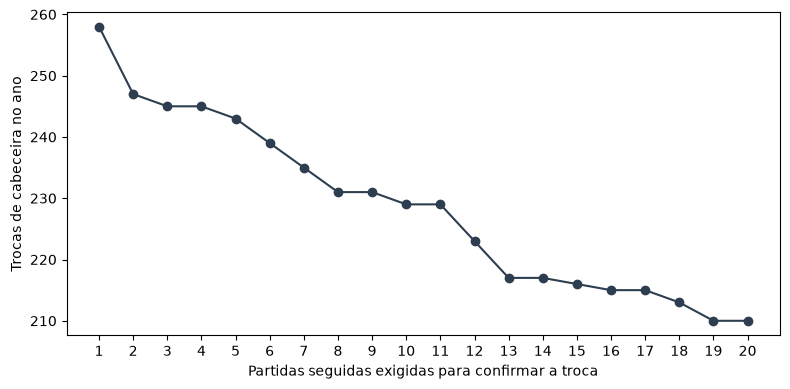

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(resultado["partidas_para_confirmar"], resultado["trocas"],
        marker="o", color="#2c3e50")
ax.set_xlabel("Partidas seguidas exigidas para confirmar a troca")
ax.set_ylabel("Trocas de cabeceira no ano")
ax.set_xticks(resultado["partidas_para_confirmar"])
plt.tight_layout()
plt.show()

,partidas,mediana,p90,dif. mediana,dif. p90
faixa_troca,,,,,
-60,493,13.45,20.85,-0.13,-0.38
-50,546,13.88,20.83,0.30,-0.40
-40,506,14.08,21.20,0.50,-0.03
-30,519,14.03,21.44,0.45,0.21
-20,452,13.96,20.70,0.37,-0.53
-10,139,14.68,22.54,1.10,1.31
+0,837,17.42,30.65,3.83,9.41
+10,630,15.12,27.17,1.54,5.94
+20,600,16.09,23.81,2.51,2.57


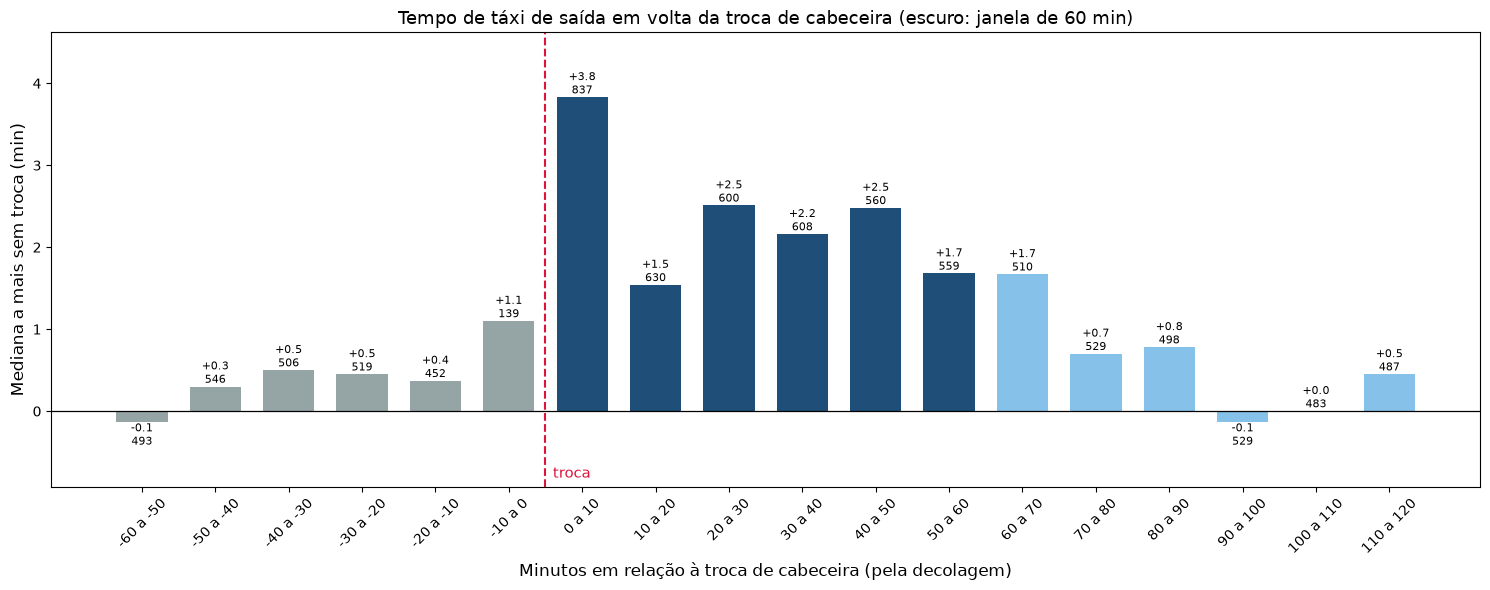

sem troca: 82996 partidas, mediana 13.58 min, P90 21.23 min


In [53]:
# Tempo de táxi antes e depois de cada troca de cabeceira, em faixas de 10 minutos.
# Tudo na ordem das decolagens, como a troca.
ordem_atot = base.sort_values("ATOT").reset_index(drop=True)
momentos = list(ordem_atot["ATOT"])
trocas = list(ordem_atot["houve_troca"])
datas = list(ordem_atot["ATOT"].dt.tz_convert(TZ).dt.date)

# Minutos desde a última troca do mesmo dia (indo para frente).
minutos_desde = []
ultima_troca = None
for i in range(len(momentos)):
    if i == 0 or datas[i] != datas[i - 1]:
        ultima_troca = None
    if trocas[i]:
        ultima_troca = momentos[i]
    if ultima_troca is None:
        minutos_desde.append(np.nan)
    else:
        minutos_desde.append((momentos[i] - ultima_troca).total_seconds() / 60)

# Minutos até a próxima troca do mesmo dia (indo para trás).
minutos_ate = [np.nan] * len(momentos)
proxima_troca = None
for i in range(len(momentos) - 1, -1, -1):
    if i == len(momentos) - 1 or datas[i] != datas[i + 1]:
        proxima_troca = None
    if trocas[i]:
        proxima_troca = momentos[i]
    if proxima_troca is not None:
        minutos_ate[i] = (proxima_troca - momentos[i]).total_seconds() / 60

# Faixa de cada partida: até 60 min antes da troca, até 120 min depois, ou longe de troca.
faixa = []
for desde, ate in zip(minutos_desde, minutos_ate):
    if not np.isnan(desde) and desde < 120:
        inicio = int(desde // 10) * 10
        faixa.append(f"+{inicio}")
    elif not np.isnan(ate) and 0 < ate <= 60:
        inicio = int((ate - 0.001) // 10) * 10 + 10
        faixa.append(f"-{inicio}")
    else:
        faixa.append("sem_troca")
ordem_atot["faixa_troca"] = faixa

ORDEM_FAIXAS = ["-60", "-50", "-40", "-30", "-20", "-10",
                "+0", "+10", "+20", "+30", "+40", "+50",
                "+60", "+70", "+80", "+90", "+100", "+110"]

por_faixa = ordem_atot.groupby("faixa_troca")["taxi_out"]
perfil_troca = pd.DataFrame()
perfil_troca["partidas"] = por_faixa.size()
perfil_troca["mediana"] = por_faixa.median()
perfil_troca["p90"] = por_faixa.quantile(0.90)

# Referência: partidas sem troca nos 120 min antes nem nos 60 min depois da decolagem.
sem_troca = perfil_troca.loc["sem_troca"]
perfil_troca["dif. mediana"] = perfil_troca["mediana"] - sem_troca["mediana"]
perfil_troca["dif. p90"] = perfil_troca["p90"] - sem_troca["p90"]
perfil_troca = perfil_troca.reindex(ORDEM_FAIXAS + ["sem_troca"]).round(2)
display(perfil_troca)

faixas = perfil_troca.loc[ORDEM_FAIXAS]

# Cinza antes da troca, azul escuro na janela adotada, azul claro depois dela.
cores = []
for rotulo in ORDEM_FAIXAS:
    minuto = int(rotulo)
    if minuto < 0:
        cores.append("#95a5a6")
    elif minuto < JANELA_TROCA_MIN:
        cores.append("#1f4e79")
    else:
        cores.append("#85c1e9")

# Rótulo do eixo: "-60 a -50", "0 a 10", ...
nomes = []
for rotulo in ORDEM_FAIXAS:
    minuto = int(rotulo)
    nomes.append(f"{minuto} a {minuto + 10}")

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(nomes, faixas["dif. mediana"], color=cores, width=0.7)
ax.axhline(0, color="black", lw=0.9)
ax.axvline(5.5, color="crimson", ls="--", lw=1.5)
# O texto fica no pé do gráfico (y = 0,02 é 2% da altura do eixo).
ax.text(5.6, 0.02, "troca", color="crimson", fontsize=11, transform=ax.get_xaxis_transform())

for i, (valor, partidas) in enumerate(zip(faixas["dif. mediana"], faixas["partidas"])):
    texto = f"{valor:+.1f}\n{int(partidas)}"
    if valor >= 0:
        ax.annotate(texto, (i, valor), ha="center", va="bottom", fontsize=8)
    else:
        ax.annotate(texto, (i, valor), ha="center", va="top", fontsize=8)

plt.xticks(rotation=45)
ax.set_xlabel("Minutos em relação à troca de cabeceira (pela decolagem)", fontsize=12)
ax.set_ylabel("Mediana a mais sem troca (min)", fontsize=12)
ax.set_title(f"Tempo de táxi de saída em volta da troca de cabeceira (escuro: janela de {JANELA_TROCA_MIN} min)",
             fontsize=13)
ax.margins(y=0.2)
plt.tight_layout()
plt.show()

print(f"sem troca: {int(sem_troca['partidas'])} partidas, mediana {sem_troca['mediana']:.2f} min, P90 {sem_troca['p90']:.2f} min")

,mes,para a 17,para a 35,total
0,1,17,7,24
1,2,19,12,31
2,3,15,7,22
3,4,14,8,22
4,5,10,6,16
5,6,8,7,15
6,7,8,3,11
7,8,10,4,14
8,9,10,5,15
9,10,16,11,27


trocas no ano: 245


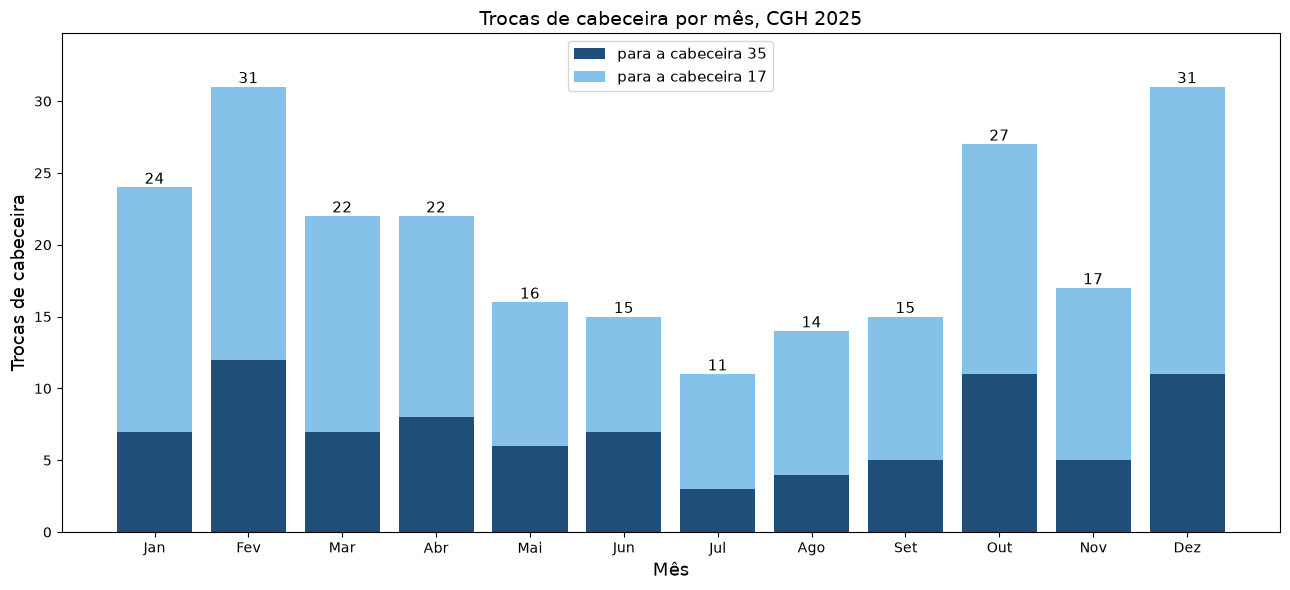

In [54]:
# Trocas de cabeceira por mês, separadas pelo sentido (a cabeceira nova).
MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

# Cada troca é a partida em que a pista virou; o mês vem da hora local da decolagem.
so_trocas = base[base["houve_troca"]].copy()
so_trocas["mes_troca"] = so_trocas["ATOT"].dt.tz_convert(TZ).dt.month

linhas = []
for mes in range(1, 13):
    do_mes = so_trocas[so_trocas["mes_troca"] == mes]
    para_17 = (do_mes["cabeceira"] == "17").sum()
    para_35 = (do_mes["cabeceira"] == "35").sum()
    linhas.append({"mes": mes, "para a 17": para_17, "para a 35": para_35,
                   "total": para_17 + para_35})
trocas_por_mes = pd.DataFrame(linhas)
display(trocas_por_mes)
print(f"trocas no ano: {trocas_por_mes['total'].sum()}")

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(MESES, trocas_por_mes["para a 35"], color="#1f4e79", label="para a cabeceira 35")
ax.bar(MESES, trocas_por_mes["para a 17"], bottom=trocas_por_mes["para a 35"],
       color="#85c1e9", label="para a cabeceira 17")

# Total em cima de cada barra.
for i, total in enumerate(trocas_por_mes["total"]):
    ax.annotate(f"{total}", (i, total), ha="center", va="bottom", fontsize=11)

ax.set_xlabel("Mês", fontsize=13)
ax.set_ylabel("Trocas de cabeceira", fontsize=13)
ax.set_title(f"Trocas de cabeceira por mês, {AEROPORTO.upper()} {ANO}", fontsize=14)
ax.legend(fontsize=11)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

### 1.4.3 - Vento em relação à cabeceira de decolagem

Fontes: 
DECEA: <https://ajuda.decea.mil.br/base-de-conhecimento/como-decodificar-o-metar-e-o-speci/>

Publicação CÓDIGOS METEOROLOGICO: <https://publicacoes.decea.mil.br/publicacao/ICA-105-16>

O METAR/SPECI são confeccionados pelo Norte Verdadeiro. 
Para a correta distinção de vento de proa ou de cauda é necessário fazer o cálculo do rumo magnético da pista -/+ a declinação magnética(quando Oeste(W) é menos, quando Leste(E) é mais). Desta maneira temos o rumo verdadeiro da cabeceira

In [55]:
# Cortes de intensidade do vento, em nós. [10, 20] gera as faixas <10, 10_20 e >=20.
VENTO_CORTES = [10, 20]

In [56]:
# Rumo verdadeiro de cada cabeceira, para comparar com o vento do METAR.
rumo_verdadeiro = {}
for cabeceira in QFU_MAG:
    rumo_verdadeiro[cabeceira] = (QFU_MAG[cabeceira] - DECL_W) % 360

rumo_pista = base["cabeceira"].map(rumo_verdadeiro)

# Componente do vento no eixo da pista: positiva é de proa, negativa é de cauda.
angulo = np.radians(base["wind_direction"] - rumo_pista)
componente_proa = base["wind_speed"] * np.cos(angulo)

# Vento de cauda dentro da janela de uma troca é METAR atrasado: a pista já mudou,
# mas a mensagem ainda mostra o vento de antes.
cauda_no_metar = componente_proa.fillna(0) < 0
base["atrasada"] = cauda_no_metar & (base["troca_cabeceira"] == 1)
print(f"partidas com METAR atrasado: {base['atrasada'].sum()}")

# Para cada partida com METAR atrasado, procura a próxima mensagem com vento de proa
# (ou variável) para a cabeceira da decolagem, até MAX_ESPERA_H horas depois.
MAX_ESPERA_H = 1

base["direcao"] = base["wind_direction"]
base["intensidade"] = base["wind_speed"]
espera_min = []
nao_achou = 0

for indice in base.index[base["atrasada"]]:
    rumo = rumo_pista[indice]
    mensagem_atual = base.loc[indice, "dt"]
    limite = mensagem_atual + pd.Timedelta(hours=MAX_ESPERA_H)
    seguintes = metar[(metar["dt"] > mensagem_atual) & (metar["dt"] <= limite)]

    achou = False
    for momento, direcao, intensidade in zip(seguintes["dt"], seguintes["wind_direction"],
                                             seguintes["wind_speed"]):
        sem_direcao = np.isnan(direcao)
        if sem_direcao or intensidade * np.cos(np.radians(direcao - rumo)) >= 0:
            base.loc[indice, "direcao"] = direcao
            base.loc[indice, "intensidade"] = intensidade
            espera_min.append((momento - mensagem_atual).total_seconds() / 60)
            achou = True
            break

    # Sem mensagem de proa no prazo: a direção é apagada, e a partida não conta como cauda.
    if not achou:
        base.loc[indice, "direcao"] = np.nan
        nao_achou = nao_achou + 1

print(f"acharam mensagem de proa: {len(espera_min)} "
      f"(mediana {np.median(espera_min):.0f} min depois da mensagem original)")
print(f"sem mensagem de proa em {MAX_ESPERA_H} h: {nao_achou}")

# Com o vento corrigido, a conta de proa e cauda é refeita.
angulo = np.radians(base["direcao"] - rumo_pista)
base["componente_proa"] = base["intensidade"] * np.cos(angulo)

# Vento variável ou calmo não tem direção, e conta como sem cauda.
base["de_cauda"] = base["componente_proa"].fillna(0) < 0

# Classificação do vento: primeiro pela intensidade, depois a cauda por cima.
vento = pd.Series("<10", index=base.index)
vento[base["intensidade"] >= 10] = "10_20"
vento[base["intensidade"] >= 20] = ">=20"
vento[base["de_cauda"]] = "cauda"
base["vento"] = pd.Categorical(vento, categories=["<10", "10_20", "cauda", ">=20"])

print(base["vento"].value_counts().to_dict())

partidas com METAR atrasado: 637
acharam mensagem de proa: 561 (mediana 60 min depois da mensagem original)
sem mensagem de proa em 1 h: 76
{'<10': 62966, '10_20': 24870, 'cauda': 4303, '>=20': 342}


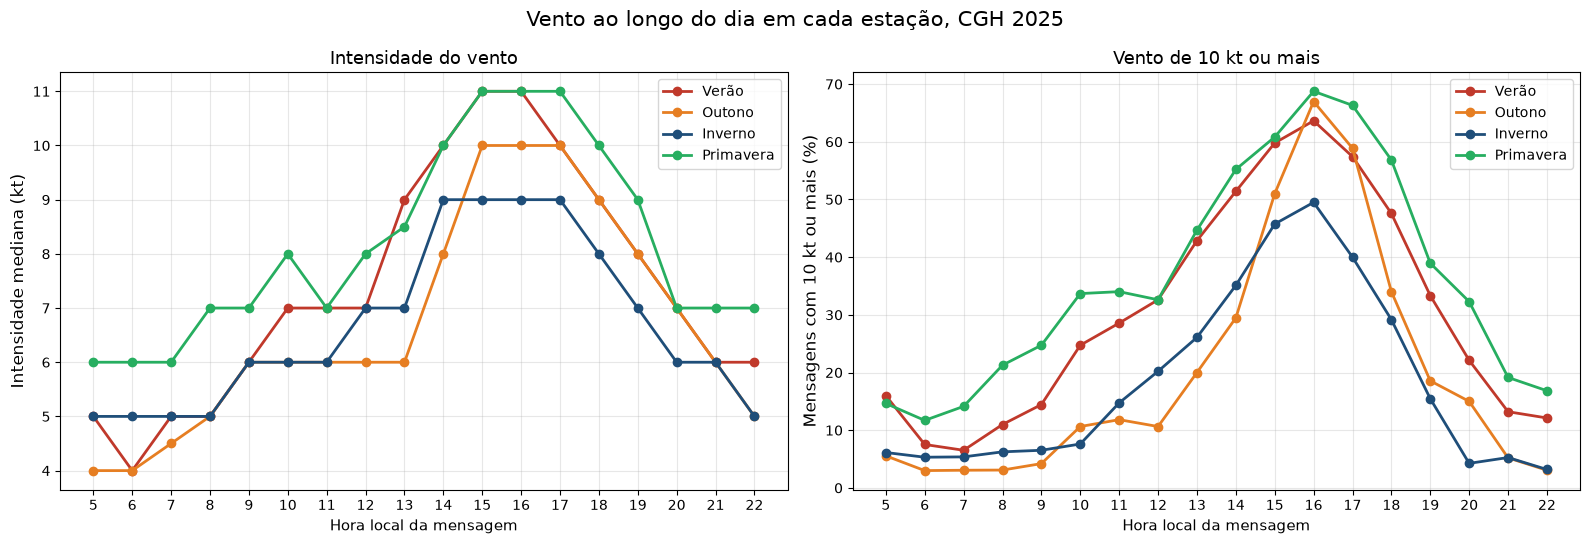

In [57]:
# O primeiro corte: com [10, 20], a % de mensagens com 10 kt ou mais.
# (Com 20 kt são menos de 1% das mensagens, e a curva por hora fica só ruído.)
PRIMEIRO_CORTE = VENTO_CORTES[0]

rumo_verdadeiro = {}
for cabeceira in QFU_MAG:
    rumo_verdadeiro[cabeceira] = (QFU_MAG[cabeceira] - DECL_W) % 360

local_metar = metar["dt"].dt.tz_convert(TZ)
metar["hora"] = local_metar.dt.hour
metar["estacao"] = local_metar.dt.month.map(ESTACAO_ANO)

# Cabeceira favorecida pelo vento: a que recebe mais proa. VRB ou calmo fica sem.
# Não entra neste gráfico, mas é usada no próximo (vento favorável x uso da 35).
proa_17 = metar["wind_speed"] * np.cos(np.radians(metar["wind_direction"] - rumo_verdadeiro["17"]))
proa_35 = metar["wind_speed"] * np.cos(np.radians(metar["wind_direction"] - rumo_verdadeiro["35"]))
metar["favorece_35"] = (proa_35 > proa_17).astype(float)
metar.loc[metar["wind_direction"].isna(), "favorece_35"] = np.nan

HORAS_METAR = list(range(5, 23))    # mesmo horário de operação das partidas
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))

for estacao in ORDEM_ESTACAO_ANO:
    da_estacao = metar[metar["estacao"] == estacao]
    mediana = []
    forte = []
    for h in HORAS_METAR:
        da_hora = da_estacao[da_estacao["hora"] == h]
        mediana.append(da_hora["wind_speed"].median())
        forte.append((da_hora["wind_speed"] >= PRIMEIRO_CORTE).mean() * 100)
    cor = CORES_ESTACAO_ANO[estacao]
    ax[0].plot(HORAS_METAR, mediana, marker="o", lw=2, color=cor, label=estacao)
    ax[1].plot(HORAS_METAR, forte, marker="o", lw=2, color=cor, label=estacao)

ax[0].set_ylabel("Intensidade mediana (kt)", fontsize=12)
ax[0].set_title("Intensidade do vento", fontsize=13)
ax[1].set_ylabel(f"Mensagens com {PRIMEIRO_CORTE} kt ou mais (%)", fontsize=12)
ax[1].set_title(f"Vento de {PRIMEIRO_CORTE} kt ou mais", fontsize=13)
for eixo in ax:
    eixo.set_xticks(HORAS_METAR)
    eixo.set_xlabel("Hora local da mensagem", fontsize=11)
    eixo.grid(alpha=0.3)
    eixo.legend(fontsize=10)
plt.suptitle(f"Vento ao longo do dia em cada estação, {AEROPORTO.upper()} {ANO}", fontsize=15)
plt.tight_layout()
plt.show()

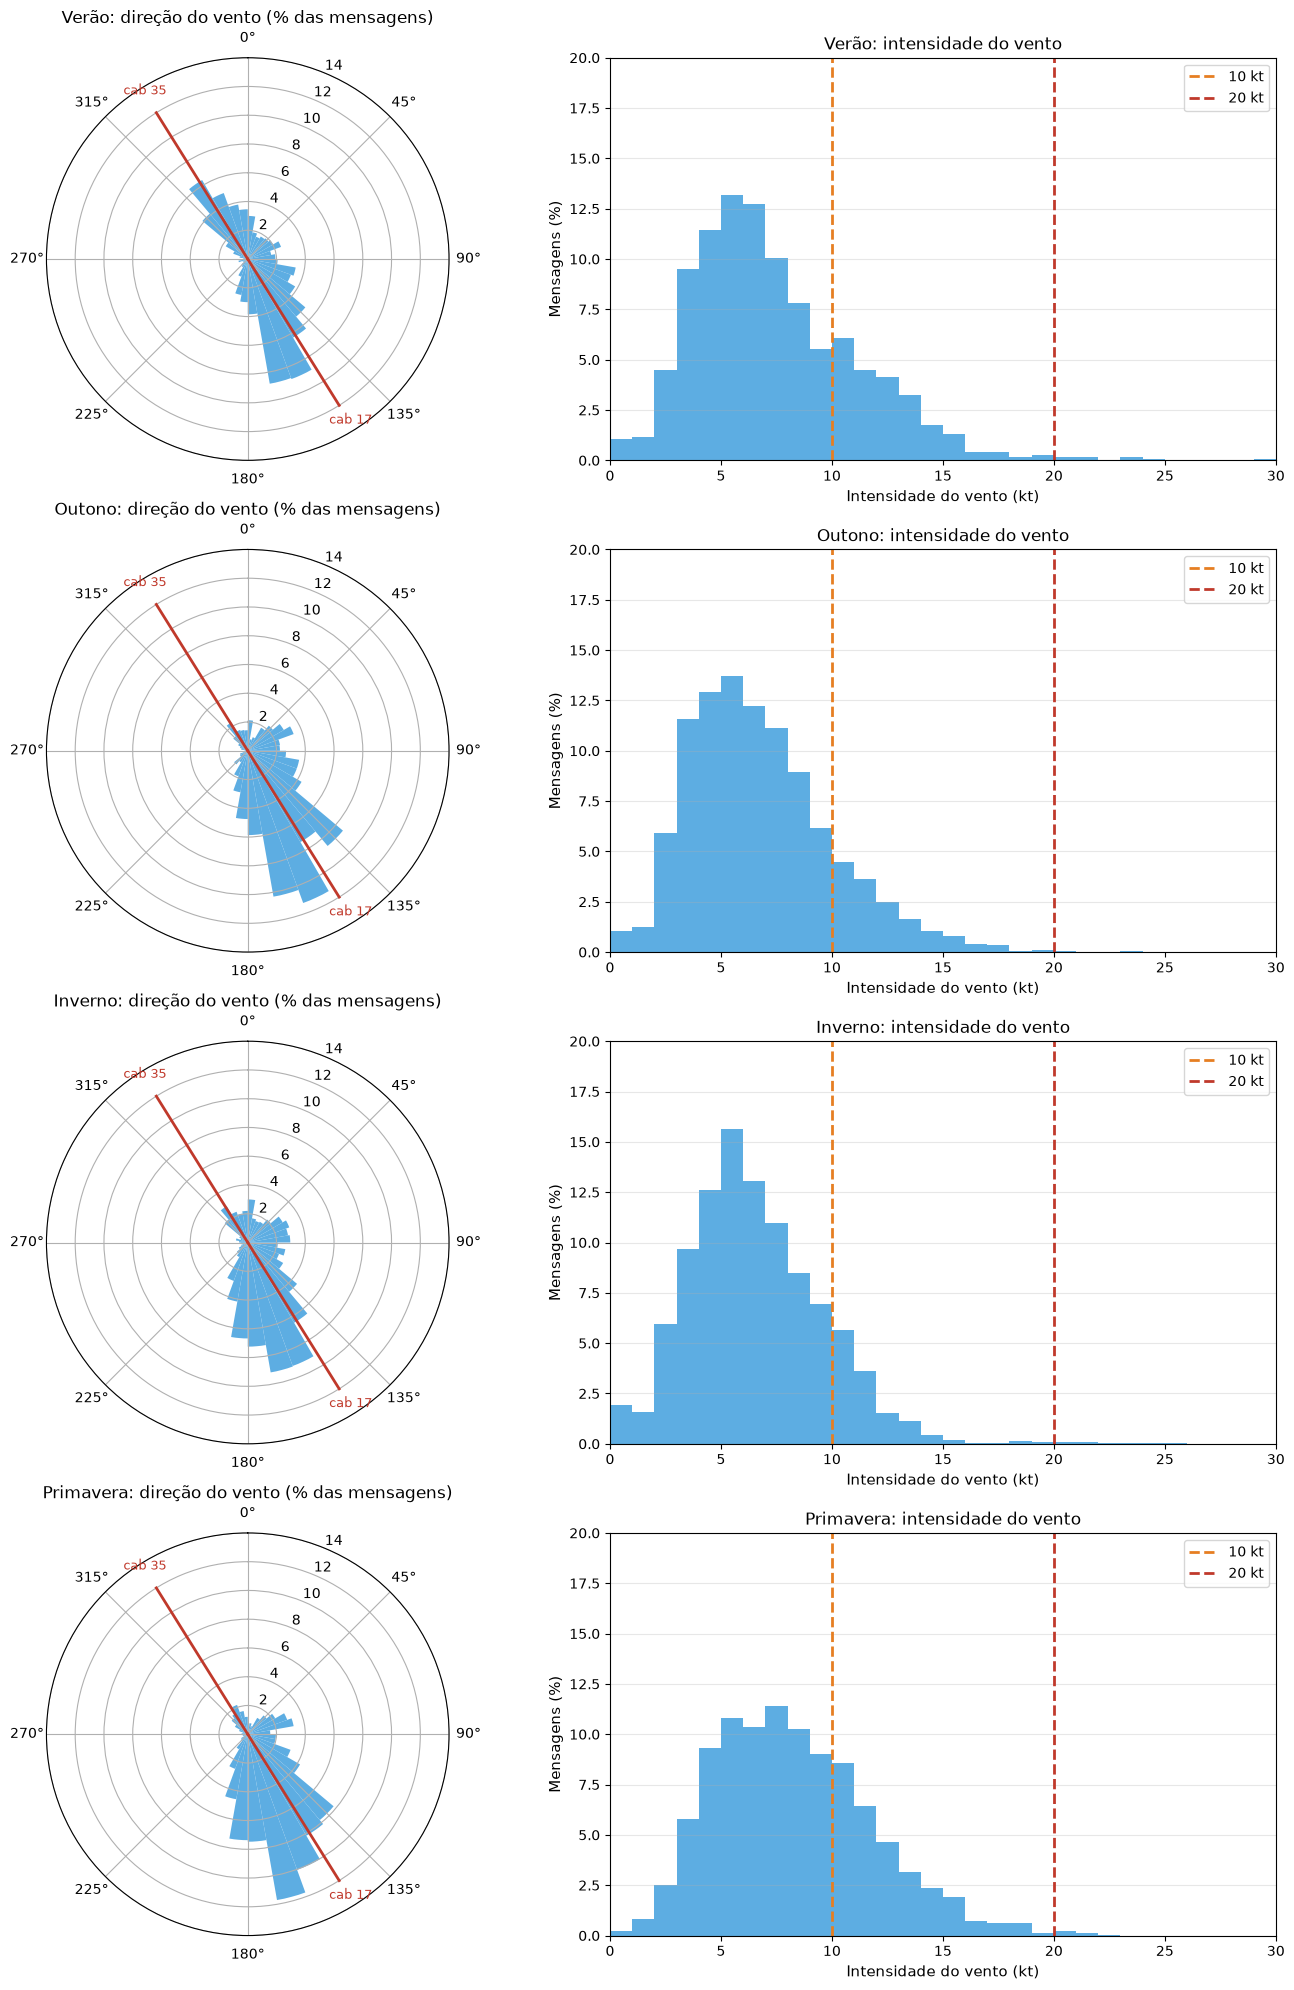

,estação,mensagens,% VRB ou calmo,% favorece a 17,mediana (kt),% 10 kt ou mais,% 20 kt ou mais
0,Verão,2819,7.7,61.1,6.0,23.1,0.7
1,Outono,2823,8.2,79.0,6.0,15.1,0.1
2,Inverno,2822,6.5,73.9,6.0,13.1,0.3
3,Primavera,2946,4.6,81.3,7.0,29.4,0.4


In [58]:
# Direção e intensidade do vento em cada estação, a partir das mensagens METAR.
CORES_CORTES = ["#e67e22", "#c0392b", "#8e44ad"]

# Rumo verdadeiro de cada cabeceira, para comparar com o vento do METAR.
rumo_verdadeiro = {}
for cabeceira in QFU_MAG:
    rumo_verdadeiro[cabeceira] = (QFU_MAG[cabeceira] - DECL_W) % 360

metar["estacao"] = metar["dt"].dt.tz_convert(TZ).dt.month.map(ESTACAO_ANO)
setores = np.arange(0, 360, 10)

fig = plt.figure(figsize=(14, 20))
resumo_vento = []

for i, estacao in enumerate(ORDEM_ESTACAO_ANO):
    da_estacao = metar[metar["estacao"] == estacao]

    # VRB e calmaria não têm direção e ficam fora da rosa.
    sem_direcao = da_estacao["wind_direction"].isna()
    direcao = da_estacao.loc[~sem_direcao, "wind_direction"].astype(float)
    velocidade = da_estacao.loc[~sem_direcao, "wind_speed"].astype(float)

    # Cabeceira favorecida: a que recebe mais vento de proa.
    proa_17 = velocidade * np.cos(np.radians(direcao - rumo_verdadeiro["17"]))
    proa_35 = velocidade * np.cos(np.radians(direcao - rumo_verdadeiro["35"]))
    favorece_17 = (proa_17 >= proa_35).mean() * 100

    linha = {"estação": estacao,
             "mensagens": len(da_estacao),
             "% VRB ou calmo": sem_direcao.mean() * 100,
             "% favorece a 17": favorece_17,
             "mediana (kt)": da_estacao["wind_speed"].median()}
    # Uma coluna para cada corte: % das mensagens com aquela intensidade ou mais.
    for corte in VENTO_CORTES:
        linha[f"% {corte} kt ou mais"] = (da_estacao["wind_speed"] >= corte).mean() * 100
    resumo_vento.append(linha)

    # Rosa dos ventos, em % das mensagens da estação (para comparar estações).
    contagem, _ = np.histogram(direcao % 360, bins=np.append(setores, 360))
    percentual = contagem / len(direcao) * 100

    ax_rosa = fig.add_subplot(4, 2, 2 * i + 1, projection="polar")
    ax_rosa.bar(np.radians(setores + 5), percentual, width=np.radians(10), color="#5dade2")
    for cabeceira, rumo in rumo_verdadeiro.items():
        ax_rosa.plot([np.radians(rumo)] * 2, [0, 12], color="#c0392b", lw=2)
        ax_rosa.text(np.radians(rumo), 13.5, f"cab {cabeceira}", color="#c0392b",
                     ha="center", fontsize=9)
    ax_rosa.set_ylim(0, 14)    # mesma escala nas quatro estações
    ax_rosa.set_theta_zero_location("N")
    ax_rosa.set_theta_direction(-1)
    ax_rosa.set_title(f"{estacao}: direção do vento (% das mensagens)", fontsize=12)

    # Intensidade, também em % das mensagens da estação, com uma linha em cada corte.
    ax_int = fig.add_subplot(4, 2, 2 * i + 2)
    intensidades = da_estacao["wind_speed"].dropna()
    pesos = np.ones(len(intensidades)) / len(intensidades) * 100    # cada mensagem vale 100/n %
    ax_int.hist(intensidades, bins=range(0, 31), weights=pesos, color="#5dade2")
    for j, corte in enumerate(VENTO_CORTES):
        cor = CORES_CORTES[j % len(CORES_CORTES)]
        ax_int.axvline(corte, color=cor, ls="--", lw=2, label=f"{corte} kt")
    ax_int.set_xlim(0, 30)
    ax_int.set_ylim(0, 20)
    ax_int.set_xlabel("Intensidade do vento (kt)", fontsize=11)
    ax_int.set_ylabel("Mensagens (%)", fontsize=11)
    ax_int.set_title(f"{estacao}: intensidade do vento", fontsize=12)
    ax_int.legend(fontsize=10)
    ax_int.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

display(pd.DataFrame(resumo_vento).round(1))

## 1.5 Posição de estacionamento

Cada posição é uma categoria. No modelo ela entra em interação com a cabeceira,
porque uma posição perto de uma cabeceira fica longe da outra. Em Congonhas a
decolagem só sai das interseções mais extremas de cada cabeceira (IS 121-020, item
D4.7.5), então a distância percorrida depende da posição e da cabeceira.

Quando o registro traz mais de uma posição (aeronave rebocada antes da partida),
vale a primeira. Posições só com número ficam com dois dígitos. As que tiveram menos
de 50 partidas no ano (hangar, pátios remotos, códigos avulsos) viram "OUTRAS". Sem
registro, a partida sai no descarte da seção 2.8.

In [59]:
posicao = base["box"].astype(str).str.strip().str.upper()

# Aeronave rebocada: o registro traz "A;B" e vale a primeira posição.
posicao = posicao.str.split(";").str[0].str.strip()

# Registro vazio fica sem valor.
posicao = posicao.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan})

# "7" e "07" são a mesma posição.
so_numero = posicao.str.isdigit() == True
posicao[so_numero] = posicao[so_numero].str.zfill(2)

partidas_por_posicao = posicao.value_counts()
posicoes_raras = partidas_por_posicao[partidas_por_posicao < MIN_PARTIDAS].index

posicao[posicao.isin(posicoes_raras)] = "OUTRAS"
base["posicao"] = posicao

print(f"posições com {MIN_PARTIDAS} partidas ou mais: {len(partidas_por_posicao) - len(posicoes_raras)}")
print(f"posições agrupadas em OUTRAS: {len(posicoes_raras)}")
print(f"partidas sem posição registrada: {base['posicao'].isna().sum()}")


posições com 50 partidas ou mais: 32
posições agrupadas em OUTRAS: 12
partidas sem posição registrada: 4


,posição,partidas,partidas 17,média 17,partidas 35,média 35,dif. média (35 - 17)
0,01,4216,2881,13.6,1335,17.7,4.2
1,02,4329,2949,13.4,1380,17.4,4.0
2,03,4562,3139,12.6,1423,16.6,4.1
3,04,4139,2898,12.7,1241,16.5,3.8
4,05,4421,3031,13.3,1390,16.7,3.4
5,06,4565,3140,12.8,1425,16.4,3.6
6,07,3386,2237,12.7,1149,15.9,3.2
7,08,4473,3066,12.9,1407,16.1,3.2
8,09,4392,3001,13.1,1391,15.9,2.9
9,10,4366,2979,13.3,1387,15.9,2.7


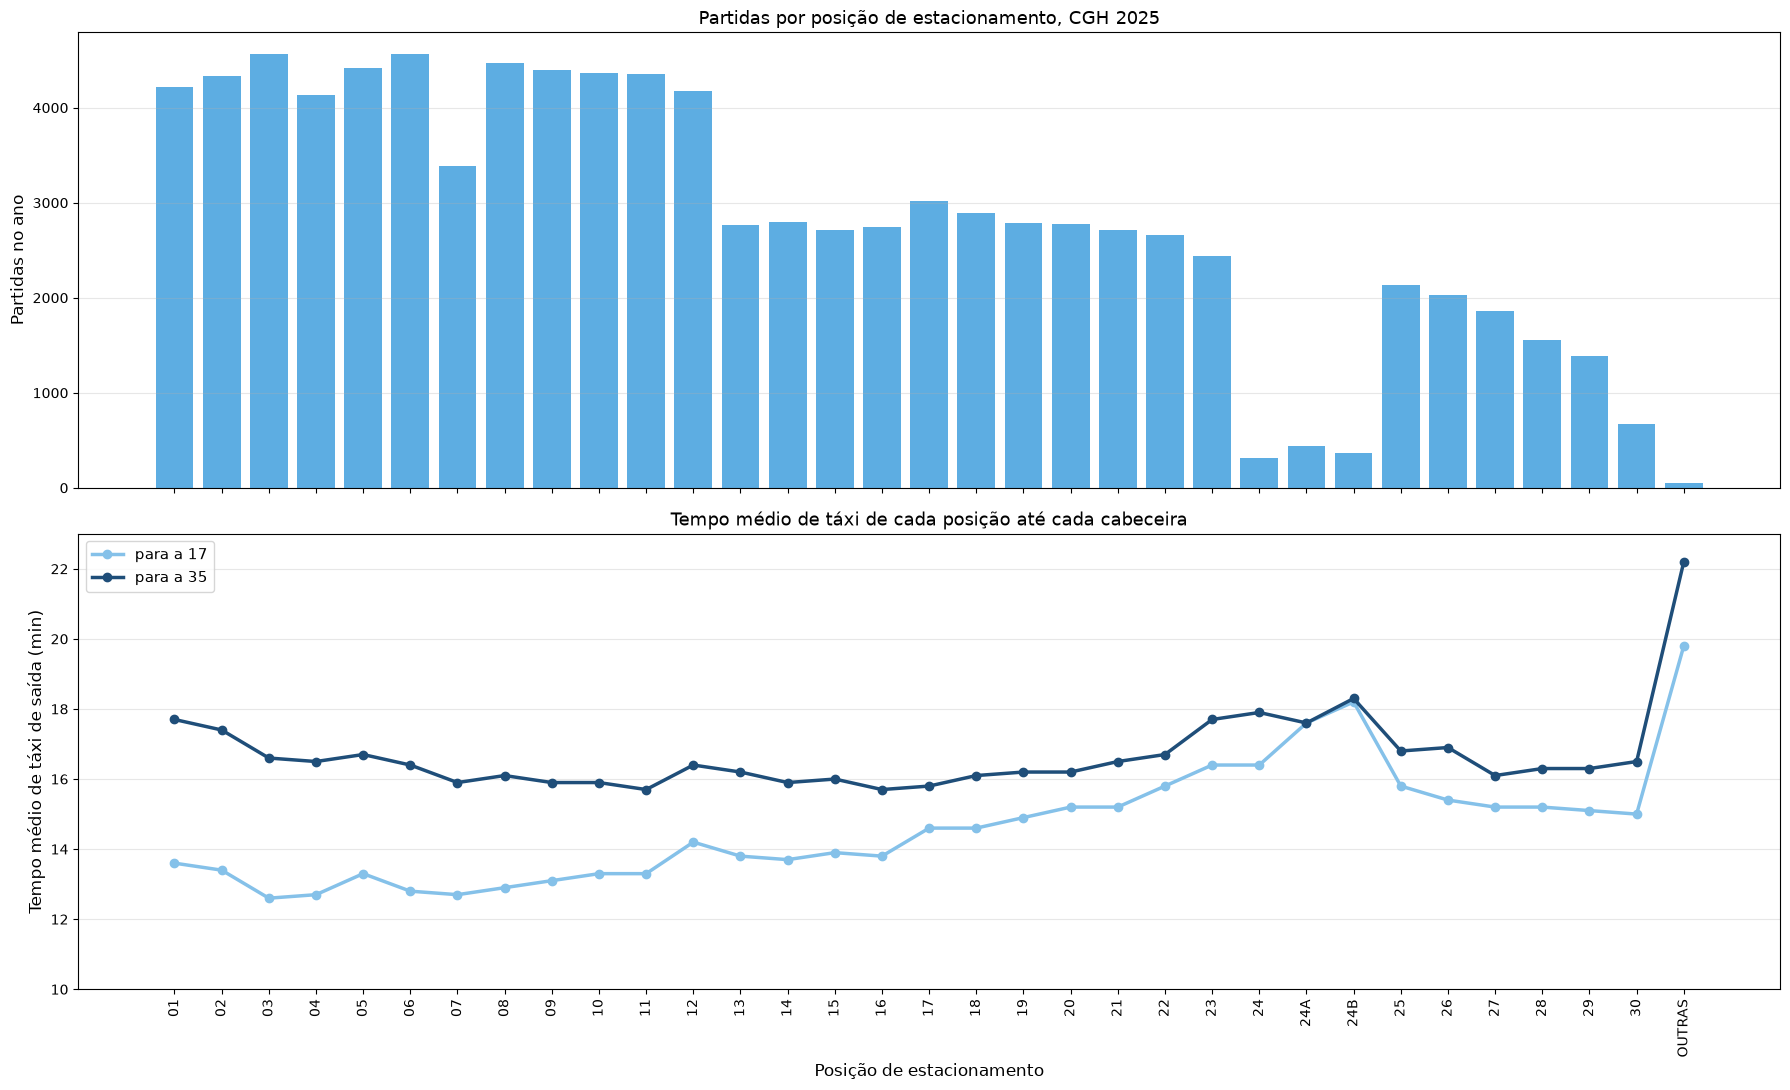

In [60]:
# Posições de estacionamento: quantas partidas saíram de cada uma e o tempo médio de
# táxi até cada cabeceira. A ordem é a numérica das posições, com OUTRAS no fim.
ORDEM_POSICOES = sorted(base["posicao"].dropna().unique())
CORES_CAB = {"17": "#85c1e9", "35": "#1f4e79"}

linhas = []
for posicao in ORDEM_POSICOES:
    da_posicao = base[base["posicao"] == posicao]
    linha = {"posição": posicao, "partidas": len(da_posicao)}
    for cabeceira in ["17", "35"]:
        grupo = da_posicao.loc[da_posicao["cabeceira"] == cabeceira, "taxi_out"]
        linha[f"partidas {cabeceira}"] = len(grupo)
        linha[f"média {cabeceira}"] = grupo.mean()
    linha["dif. média (35 - 17)"] = linha["média 35"] - linha["média 17"]
    linhas.append(linha)
por_posicao = pd.DataFrame(linhas).round(1)
display(por_posicao)

posicoes = np.arange(len(ORDEM_POSICOES))
fig, ax = plt.subplots(2, 1, figsize=(18, 11), sharex=True)

# Quantidade absoluta de partidas de cada posição.
ax[0].bar(posicoes, por_posicao["partidas"], color="#5dade2")
ax[0].set_ylabel("Partidas no ano", fontsize=12)
ax[0].set_title(f"Partidas por posição de estacionamento, {AEROPORTO.upper()} {ANO}", fontsize=13)
ax[0].grid(alpha=0.3, axis="y")

# Tempo médio de táxi de cada posição até cada cabeceira. Linhas com pontos, e o eixo
# começa em 10 min, para a diferença entre as posições aparecer.
ax[1].plot(posicoes, por_posicao["média 17"], marker="o", lw=2.5, color=CORES_CAB["17"],
           label="para a 17")
ax[1].plot(posicoes, por_posicao["média 35"], marker="o", lw=2.5, color=CORES_CAB["35"],
           label="para a 35")
ax[1].set_ylim(10, 23)
ax[1].set_ylabel("Tempo médio de táxi de saída (min)", fontsize=12)
ax[1].set_title("Tempo médio de táxi de cada posição até cada cabeceira", fontsize=13)
ax[1].legend(fontsize=11)
ax[1].grid(alpha=0.3, axis="y")
ax[1].set_xticks(posicoes)
ax[1].set_xticklabels(ORDEM_POSICOES, rotation=90)
ax[1].set_xlabel("Posição de estacionamento", fontsize=12)

plt.tight_layout()
plt.show()

## 1.6 Tipo de aeronave

No banco de dados do CGNA, uma mesma matrícula aparece com mais de um tipo de
aeronave. Por isso, optou-se por obter o tipo pela matrícula, direto no Registro
Aeronáutico Brasileiro (RAB), que traz um único tipo para cada avião.

O arquivo do RAB traz nomes e documentos dos proprietários. Por isso ele é lido
direto do site da ANAC, só com as colunas necessárias, e não é gravado.

As duas versões do ATR 72 (AT75 e AT76) ficam juntas. Tipos com menos de 50
partidas viram "OUTROS".

In [61]:
rab = pd.read_csv(RAB_URL, sep=";", skiprows=1, encoding="utf-8-sig", dtype=str,
                  usecols=["MARCAS", "CD_TIPO_ICAO", "DS_MODELO"])

# Se uma matrícula aparecer duas vezes, fica o registro mais recente.
rab = rab.drop_duplicates(subset="MARCAS", keep="last")
print(f"matrículas no RAB: {len(rab)}")

matrículas no RAB: 34899


In [62]:
# A matrícula do CGNA vem sem hífen, como no RAB (ex.: PRXBM).
base["matricula"] = base["matricula"].astype(str).str.strip().str.upper()
base["matricula"] = base["matricula"].str.replace("-", "")

base = base.merge(rab, left_on="matricula", right_on="MARCAS", how="left")
print(f"partidas sem matrícula no RAB: {base['CD_TIPO_ICAO'].isna().sum()}")

partidas sem matrícula no RAB: 122


In [63]:
tipo = base["CD_TIPO_ICAO"].copy()

# ATR 72-500 (AT75) e ATR 72-600 (AT76) ficam no mesmo grupo.
tipo[tipo == "AT76"] = "AT75"

partidas_por_tipo = tipo.value_counts()
tipos_raros = partidas_por_tipo[partidas_por_tipo < MIN_PARTIDAS].index
tipo[tipo.isin(tipos_raros)] = "OUTROS"
base["tipo_aeronave"] = tipo

print(base["tipo_aeronave"].value_counts().to_dict())

{'A320': 19789, 'B738': 19447, 'A319': 12148, 'B38M': 11457, 'A20N': 10944, 'B737': 7481, 'E195': 6921, 'E295': 3556, 'AT75': 610, 'OUTROS': 6}


,partidas,% das partidas,mediana,p90
tipo_lbl,,,,
E195,6921,7.48,12.60,20.42
737-700,7481,8.09,12.93,21.00
737-800,19447,21.03,13.28,21.28
A320,19789,21.40,13.37,21.12
A319,12148,13.14,13.38,20.95
A320neo,10944,11.83,14.02,21.41
E195-E2,3556,3.85,14.41,21.68
737 MAX 8,11457,12.39,15.43,23.40
ATR 72,610,0.66,16.08,25.53


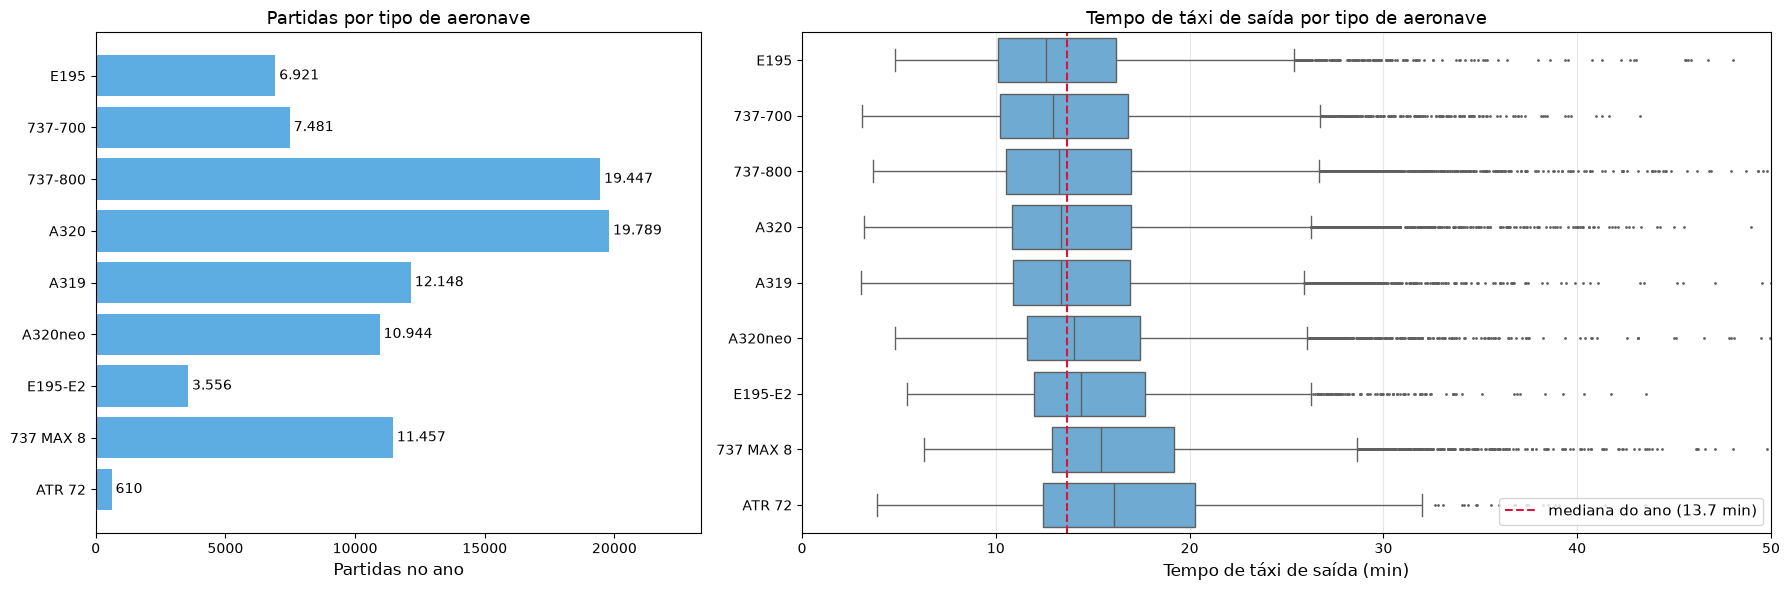

In [64]:
# Tipo de aeronave: quantas partidas de cada tipo e o tempo de táxi de cada um.
# Nome comercial de cada código ICAO, só para os rótulos dos gráficos.
NOMES_TIPO = {"A319": "A319", "A320": "A320", "A20N": "A320neo",
              "B737": "737-700", "B738": "737-800", "B38M": "737 MAX 8",
              "E195": "E195", "E295": "E195-E2", "AT75": "ATR 72", "OUTROS": "Outros"}

base["tipo_lbl"] = base["tipo_aeronave"].map(NOMES_TIPO)

# Resumo de cada tipo, do mais rápido para o mais lento (pela mediana).
por_tipo = base.groupby("tipo_lbl")["taxi_out"]
resumo_tipo = pd.DataFrame()
resumo_tipo["partidas"] = por_tipo.size()
resumo_tipo["% das partidas"] = por_tipo.size() / len(base) * 100
resumo_tipo["mediana"] = por_tipo.median()
resumo_tipo["p90"] = por_tipo.quantile(0.90)
resumo_tipo = resumo_tipo.sort_values("mediana").round(2)
display(resumo_tipo)

# "Outros" tem poucas partidas e fica fora dos gráficos.
ORDEM_TIPO = [tipo for tipo in resumo_tipo.index if tipo != "Outros"]

fig, ax = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1, 1.6]})

# Quantidade de partidas de cada tipo.
partidas = resumo_tipo.loc[ORDEM_TIPO, "partidas"]
ax[0].barh(ORDEM_TIPO, partidas, color="#5dade2")
for i, valor in enumerate(partidas):
    ax[0].text(valor, i, f" {valor:,}".replace(",", "."), va="center", fontsize=10)
ax[0].set_xlabel("Partidas no ano", fontsize=12)
ax[0].set_title("Partidas por tipo de aeronave", fontsize=13)
ax[0].margins(x=0.18)
ax[0].invert_yaxis()    # mesma ordem do boxplot: o mais rápido em cima

# Tempo de táxi de cada tipo, na mesma ordem (do mais rápido para o mais lento).
sns.boxplot(data=base[base["tipo_lbl"] != "Outros"], y="tipo_lbl", x="taxi_out",
            order=ORDEM_TIPO, color="#5dade2", fliersize=1, ax=ax[1])
ax[1].axvline(base["taxi_out"].median(), color="crimson", ls="--", lw=1.5,
              label=f"mediana do ano ({base['taxi_out'].median():.1f} min)")
ax[1].set_xlim(0, 50)
ax[1].set_xlabel("Tempo de táxi de saída (min)", fontsize=12)
ax[1].set_ylabel("")
ax[1].set_title("Tempo de táxi de saída por tipo de aeronave", fontsize=13)
ax[1].legend(fontsize=11, loc="lower right")
ax[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## 1.7 Diferença do registro da desocupação da posição da empresa aérea GOL

A série mensal por companhia mostra que, a partir de 1º de fevereiro de
2025, o tempo de táxi de saída da empresa aérea GOL diminuiu de forma repentina 
e ficou igual ao das outras companhias, saindo das mesmas posições para as mesmas cabeceiras. Como o VRA é informado pelas próprias companhias, a mudança combina com uma alteração no momento em que a GOL passou a registrar a desocupação da posição.

A variável marca as partidas da GOL antes dessa data. Ela corrige essa diferença de
medição.

> "A empresa aérea GOL reduziu, significativamente, o seu tempo de *taxi-out* em
> todos os aeroportos monitorados desde fevereiro de 2025. [...] No aeroporto de
> Congonhas (SBSP), essa redução da GOL foi somada a redução de voos da aviação
> geral que diminuíram bastante o tempo adicional de *taxi-out*, de 5,5 minutos
> em 2024 para 3,2 minutos em 2025."

- **Documento:** Relatório de Performance ATM do SISCEAB - 2025 (DECEA/ICEA)
- **Seção:** 3 Indicadores de Performance ATM › 3.2 Eficiência › 3.2.1 KPI 02,
  Tempo Adicional de Taxi-Out
- **Arquivo:** `Relatório-de-Performance-ATM-do-SISCEAB---2025.pdf`
- **PDF:** https://pesquisa.icea.decea.mil.br/performance_report/stg/2025/Relat%C3%B3rio-de-Performance-ATM-do-SISCEAB---2025.pdf
- **Versão web da seção:** https://pesquisa.icea.decea.mil.br/performance_report/stg/2025/03-Indicadores.html


In [65]:
local = base["AOBT"].dt.tz_convert(TZ)
data_mudanca = pd.Timestamp(GOL_REGISTRO_ANTIGO, tz=TZ)

# GLO é o código ICAO da GOL.
antes_da_mudanca = local < data_mudanca
da_gol = base["companhia"].astype(str) == "GLO"

base["gol_registro_antigo"] = (antes_da_mudanca & da_gol).astype(int)
print(f"partidas da GOL com o registro antigo: {base['gol_registro_antigo'].sum()}")

partidas da GOL com o registro antigo: 3329


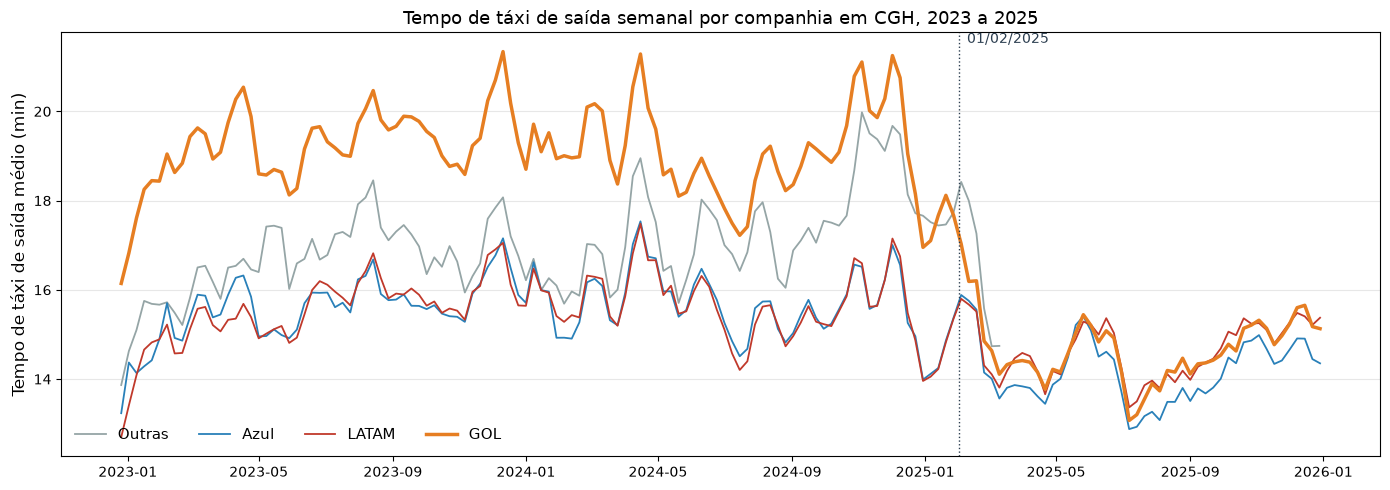

,6 meses antes,6 meses depois,diferença (min)
cia,,,
Azul,15.53,14.22,-1.31
GOL,19.14,14.60,-4.54
LATAM,15.45,14.53,-0.92
Outras,17.93,16.78,-1.16


In [76]:
# Série semanal do tempo de táxi de saída por companhia, de 2023 a 2025, para ver
# quando cada uma mudou. Usa os arquivos de cada ano baixados pelo notebook 0_2.
ANOS_SERIE = [2023, 2024, 2025]

partes = []
for ano in ANOS_SERIE:
    arquivo = f"data/{str.lower(AEROPORTO)}_cgna_{ano}.parquet"
    parte = pd.read_parquet(arquivo)
    # Nos arquivos mais antigos a coluna se chama "taxi-out".
    parte = parte.rename(columns={"taxi-out": "taxi_out"})
    partes.append(parte[["taxi_out", "AOBT", "companhia"]])
serie = pd.concat(partes, ignore_index=True)

# Mesma janela de plausibilidade da seção 1.0.
serie = serie[(serie["taxi_out"] >= TAXI_MIN) & (serie["taxi_out"] <= TAXI_MAX)].copy()

# Cada semana é rotulada pela sua segunda-feira, no horário de Brasília.
data_local = serie["AOBT"].dt.tz_convert(TZ).dt.tz_localize(None).dt.normalize()
serie["semana"] = data_local - pd.to_timedelta(data_local.dt.dayofweek, unit="D")

# As três maiores companhias separadas; as demais ficam juntas.
serie["cia"] = serie["companhia"].astype(str)
serie.loc[~serie["cia"].isin(["GLO", "TAM", "AZU"]), "cia"] = "outras"

media_semana = serie.groupby(["semana", "cia"])["taxi_out"].mean()
partidas_semana = serie.groupby(["semana", "cia"])["taxi_out"].size()

# Semana com menos de 30 partidas da companhia não entra, porque a média oscila demais.
media_semana = media_semana[partidas_semana >= 30].unstack()

CORES_CIA = {"GLO": "#e67e22", "TAM": "#c0392b", "AZU": "#2980b9", "outras": "#95a5a6"}
NOMES_CIA = {"GLO": "GOL", "TAM": "LATAM", "AZU": "Azul", "outras": "Outras"}
data_mudanca = pd.Timestamp(GOL_REGISTRO_ANTIGO)

fig, ax = plt.subplots(figsize=(14, 5))
for sigla in ["outras", "AZU", "TAM", "GLO"]:
    # Média móvel de 3 semanas, só para suavizar a linha.
    linha = media_semana[sigla].rolling(3, center=True, min_periods=1).mean()
    if sigla == "GLO":
        espessura = 2.5
    else:
        espessura = 1.3
    ax.plot(linha.index, linha, color=CORES_CIA[sigla], linewidth=espessura,
            label=NOMES_CIA[sigla])

ax.axvline(data_mudanca, color="#2c3e50", linewidth=1, linestyle=":")
ax.text(data_mudanca, ax.get_ylim()[1], f"  {data_mudanca:%d/%m/%Y}", va="top",
        fontsize=10, color="#2c3e50")
ax.set_ylabel("Tempo de táxi de saída médio (min)", fontsize=12)
ax.set_title(f"Tempo de táxi de saída semanal por companhia em {AEROPORTO.upper()}, "
             f"{ANOS_SERIE[0]} a {ANOS_SERIE[-1]}", fontsize=13)
ax.legend(frameon=False, ncol=4, loc="lower left", fontsize=11)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Média de cada companhia nos 6 meses antes e nos 6 meses depois da mudança.
antes = (serie["semana"] >= data_mudanca - pd.DateOffset(months=6)) & (serie["semana"] < data_mudanca)
depois = (serie["semana"] >= data_mudanca) & (serie["semana"] < data_mudanca + pd.DateOffset(months=6))
comparacao = pd.DataFrame()
comparacao["6 meses antes"] = serie[antes].groupby("cia")["taxi_out"].mean()
comparacao["6 meses depois"] = serie[depois].groupby("cia")["taxi_out"].mean()
comparacao["diferença (min)"] = comparacao["6 meses depois"] - comparacao["6 meses antes"]
display(comparacao.rename(index=NOMES_CIA).round(2))

## 1.99 - Analise do dia com o taxi_out médio mais lento do database x Analise do dia com o taxi_out médio mais rapido do database X Analise de um dia randomico

In [67]:
# Escolha dos dias e a função que desenha o painel de um dia.
import matplotlib.dates as mdates

# Tempo de táxi médio de cada dia. Dias com menos de 200 partidas (aeroporto fechado
# parte do dia) ficam fora da escolha, para não comparar um dia incompleto.
por_dia = base.groupby("data").agg(partidas=("taxi_out", "size"),
                                   media=("taxi_out", "mean"),
                                   dia_semana=("dia_semana", "first"),
                                   feriado=("feriado", "first"))
dias_cheios = por_dia[por_dia["partidas"] >= 200]

# Dia mais lento do ano.
DIA_LENTO = dias_cheios["media"].idxmax()

# Dia mais rápido, só entre os dias úteis que não são feriado.
uteis = dias_cheios[~dias_cheios["dia_semana"].isin(["Sábado", "Domingo"]) &
                    (dias_cheios["feriado"] == 0)]
DIA_RAPIDO = uteis["media"].idxmin()

print(f"dia mais lento: {DIA_LENTO} ({dias_cheios.loc[DIA_LENTO, 'media']:.1f} min em média)")
print(f"dia útil mais rápido: {DIA_RAPIDO} ({dias_cheios.loc[DIA_RAPIDO, 'media']:.1f} min em média)")
print(f"média do ano: {base['taxi_out'].mean():.1f} min")

# Teto de cada mensagem METAR: a menor altura entre as camadas com BKN ou OVC.
teto_metar = pd.Series(np.nan, index=metar.index)
for tipo_nuvem, altura_nuvem in [("low_cloud_type", "low_cloud_level"),
                                 ("medium_cloud_type", "medium_cloud_level"),
                                 ("high_cloud_type", "high_cloud_level"),
                                 ("highest_cloud_type", "highest_cloud_level")]:
    altura = metar[altura_nuvem].where(metar[tipo_nuvem].isin(["BKN", "OVC"]))
    teto_metar = np.fmin(teto_metar, altura)

# Fenômenos de cada mensagem, olhando os três grupos de tempo presente.
tempo_presente = metar[["current_wx1", "current_wx2", "current_wx3"]].astype(str)
FAIXAS_TEMPO = {
    "Chuva leve": tempo_presente.isin(CHUVA_LEVE).any(axis=1),
    "Chuva mod. ou forte": tempo_presente.isin(CHUVA_MOD_FORTE).any(axis=1),
    "Trovoada": tempo_presente.apply(lambda coluna: coluna.str.contains("TS")).any(axis=1),
    "TCU": metar["tcu"] == 1,
    "Rajada": metar["wind_gust"].notna(),
    "Teto < 1.500 ft": teto_metar < 1500,
}
CORES_TEMPO = {"Chuva leve": "#85c1e9", "Chuva mod. ou forte": "#1f4e79",
               "Trovoada": "#c0392b", "TCU": "#f39c12", "Rajada": "#16a085",
               "Teto < 1.500 ft": "#a04000"}
CORES_CAB = {"17": "#85c1e9", "35": "#1f4e79"}


def grafico_do_dia(data_escolhida, titulo):
    """Painel de um dia: tempo de táxi de cada partida, movimento, vento e tempo presente.
    Com data_escolhida = None, sorteia um dos dias completos (a cada execução, um dia diferente)."""
    if data_escolhida is None:
        data_escolhida = str(np.random.choice(list(dias_cheios.index)))
        print(f"dia sorteado: {data_escolhida} "
              f"({dias_cheios.loc[data_escolhida, 'media']:.1f} min em média)")

    # Partidas do dia, com os horários no horário de Brasília (sem fuso, para o eixo x).
    do_dia = base[base["data"] == data_escolhida].copy()
    do_dia["saida"] = do_dia["AOBT"].dt.tz_convert(TZ).dt.tz_localize(None)
    do_dia["decolagem"] = do_dia["ATOT"].dt.tz_convert(TZ).dt.tz_localize(None)
    do_dia = do_dia.sort_values("saida")

    # Mensagens METAR do mesmo dia, das 05h00 às 24h00.
    inicio = pd.Timestamp(data_escolhida) + pd.Timedelta(hours=5)
    fim = pd.Timestamp(data_escolhida) + pd.Timedelta(hours=24)
    hora_metar = metar["dt"].dt.tz_convert(TZ).dt.tz_localize(None)
    no_dia = (hora_metar >= inicio - pd.Timedelta(hours=1)) & (hora_metar <= fim)
    metar_dia = metar[no_dia].copy()
    metar_dia["hora"] = hora_metar[no_dia]

    fig, ax = plt.subplots(4, 1, figsize=(15, 20), sharex=True,
                           gridspec_kw={"height_ratios": [3, 1.3, 1.5, 1.6]})

    # 1. Tempo de táxi de cada partida, pela hora de saída da posição, com a cor da cabeceira.
    for cabeceira in ["17", "35"]:
        grupo = do_dia[do_dia["cabeceira"] == cabeceira]
        ax[0].scatter(grupo["saida"], grupo["taxi_out"], s=14, color=CORES_CAB[cabeceira],
                      label=f"cabeceira {cabeceira} ({len(grupo)} partidas)")
    mediana_movel = do_dia.set_index("saida")["taxi_out"].rolling("30min").median()
    ax[0].plot(mediana_movel.index, mediana_movel, color="black", lw=1.8,
               label="mediana dos últimos 30 min")
    ax[0].axhline(base["taxi_out"].median(), color="gray", ls=":", lw=1.2,
                  label=f"mediana do ano ({base['taxi_out'].median():.1f} min)")

    # Trocas de cabeceira, pela hora da decolagem que marcou a troca.
    trocas = do_dia[do_dia["houve_troca"]]
    for i, momento in enumerate(trocas["decolagem"]):
        if i == 0:
            ax[0].axvline(momento, color="crimson", ls="--", lw=1.5, label="troca de cabeceira")
        else:
            ax[0].axvline(momento, color="crimson", ls="--", lw=1.5)
    ax[0].set_ylabel("Tempo de táxi de saída (min)", fontsize=11)
    ax[0].legend(fontsize=9, loc="upper left", ncol=2)
    ax[0].grid(alpha=0.3)

    # 2. Movimento: partidas que saíram da posição em cada bloco de 30 min, por cabeceira.
    do_dia["bloco_30"] = do_dia["saida"].dt.floor("30min")
    contagem = do_dia.groupby(["bloco_30", "cabeceira"]).size().unstack(fill_value=0)
    embaixo = np.zeros(len(contagem))
    for cabeceira in ["17", "35"]:
        if cabeceira in contagem.columns:
            ax[1].bar(contagem.index + pd.Timedelta(minutes=15), contagem[cabeceira],
                      width=pd.Timedelta(minutes=27), bottom=embaixo, color=CORES_CAB[cabeceira])
            embaixo = embaixo + contagem[cabeceira].values
    ax[1].set_ylabel("Partidas\npor 30 min", fontsize=11)
    ax[1].grid(alpha=0.3, axis="y")

    # 3. Vento do METAR: intensidade, rajada e os cortes das faixas.
    ax[2].step(metar_dia["hora"], metar_dia["wind_speed"], where="post", color="#2c3e50",
               lw=1.8, label="intensidade")
    ax[2].scatter(metar_dia["hora"], metar_dia["wind_gust"], color="#16a085", s=25,
                  marker="^", label="rajada")
    for corte in VENTO_CORTES:
        ax[2].axhline(corte, color="gray", ls=":", lw=1)
    ax[2].set_ylabel("Vento (kt)", fontsize=11)
    ax[2].legend(fontsize=9, loc="upper left")
    ax[2].grid(alpha=0.3)

    # 4. Tempo presente: uma faixa colorida enquanto cada fenômeno está na mensagem.
    nomes = list(FAIXAS_TEMPO.keys())
    horas = list(metar_dia["hora"]) + [fim]
    for linha, nome in enumerate(nomes):
        presente = FAIXAS_TEMPO[nome][no_dia].values
        for j in range(len(presente)):
            if presente[j]:
                ax[3].barh(linha, horas[j + 1] - horas[j], left=horas[j], height=0.7,
                           color=CORES_TEMPO[nome])
    ax[3].set_yticks(range(len(nomes)))
    ax[3].set_yticklabels(nomes, fontsize=10)
    ax[3].set_ylim(-0.6, len(nomes) - 0.4)
    ax[3].invert_yaxis()
    ax[3].grid(alpha=0.3, axis="x")

    ax[3].set_xlim(inicio, fim)
    ax[3].xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax[3].xaxis.set_major_formatter(mdates.DateFormatter("%H"))
    ax[3].set_xlabel("Hora local", fontsize=11)

    # Título no primeiro painel, em duas linhas, para não ficar por cima do gráfico.
    data_texto = pd.Timestamp(data_escolhida).strftime("%d/%m/%Y")
    ax[0].set_title(f"{titulo}: {data_texto} ({do_dia['dia_semana'].iloc[0]})\n"
                    f"{len(do_dia)} partidas, média {do_dia['taxi_out'].mean():.1f} min, "
                    f"P90 {do_dia['taxi_out'].quantile(0.90):.1f} min, "
                    f"trocas de cabeceira: {len(trocas)}",
                    fontsize=14)
    plt.tight_layout()
    plt.show()

dia mais lento: 2025-01-31 (21.8 min em média)
dia útil mais rápido: 2025-09-30 (11.7 min em média)
média do ano: 14.7 min


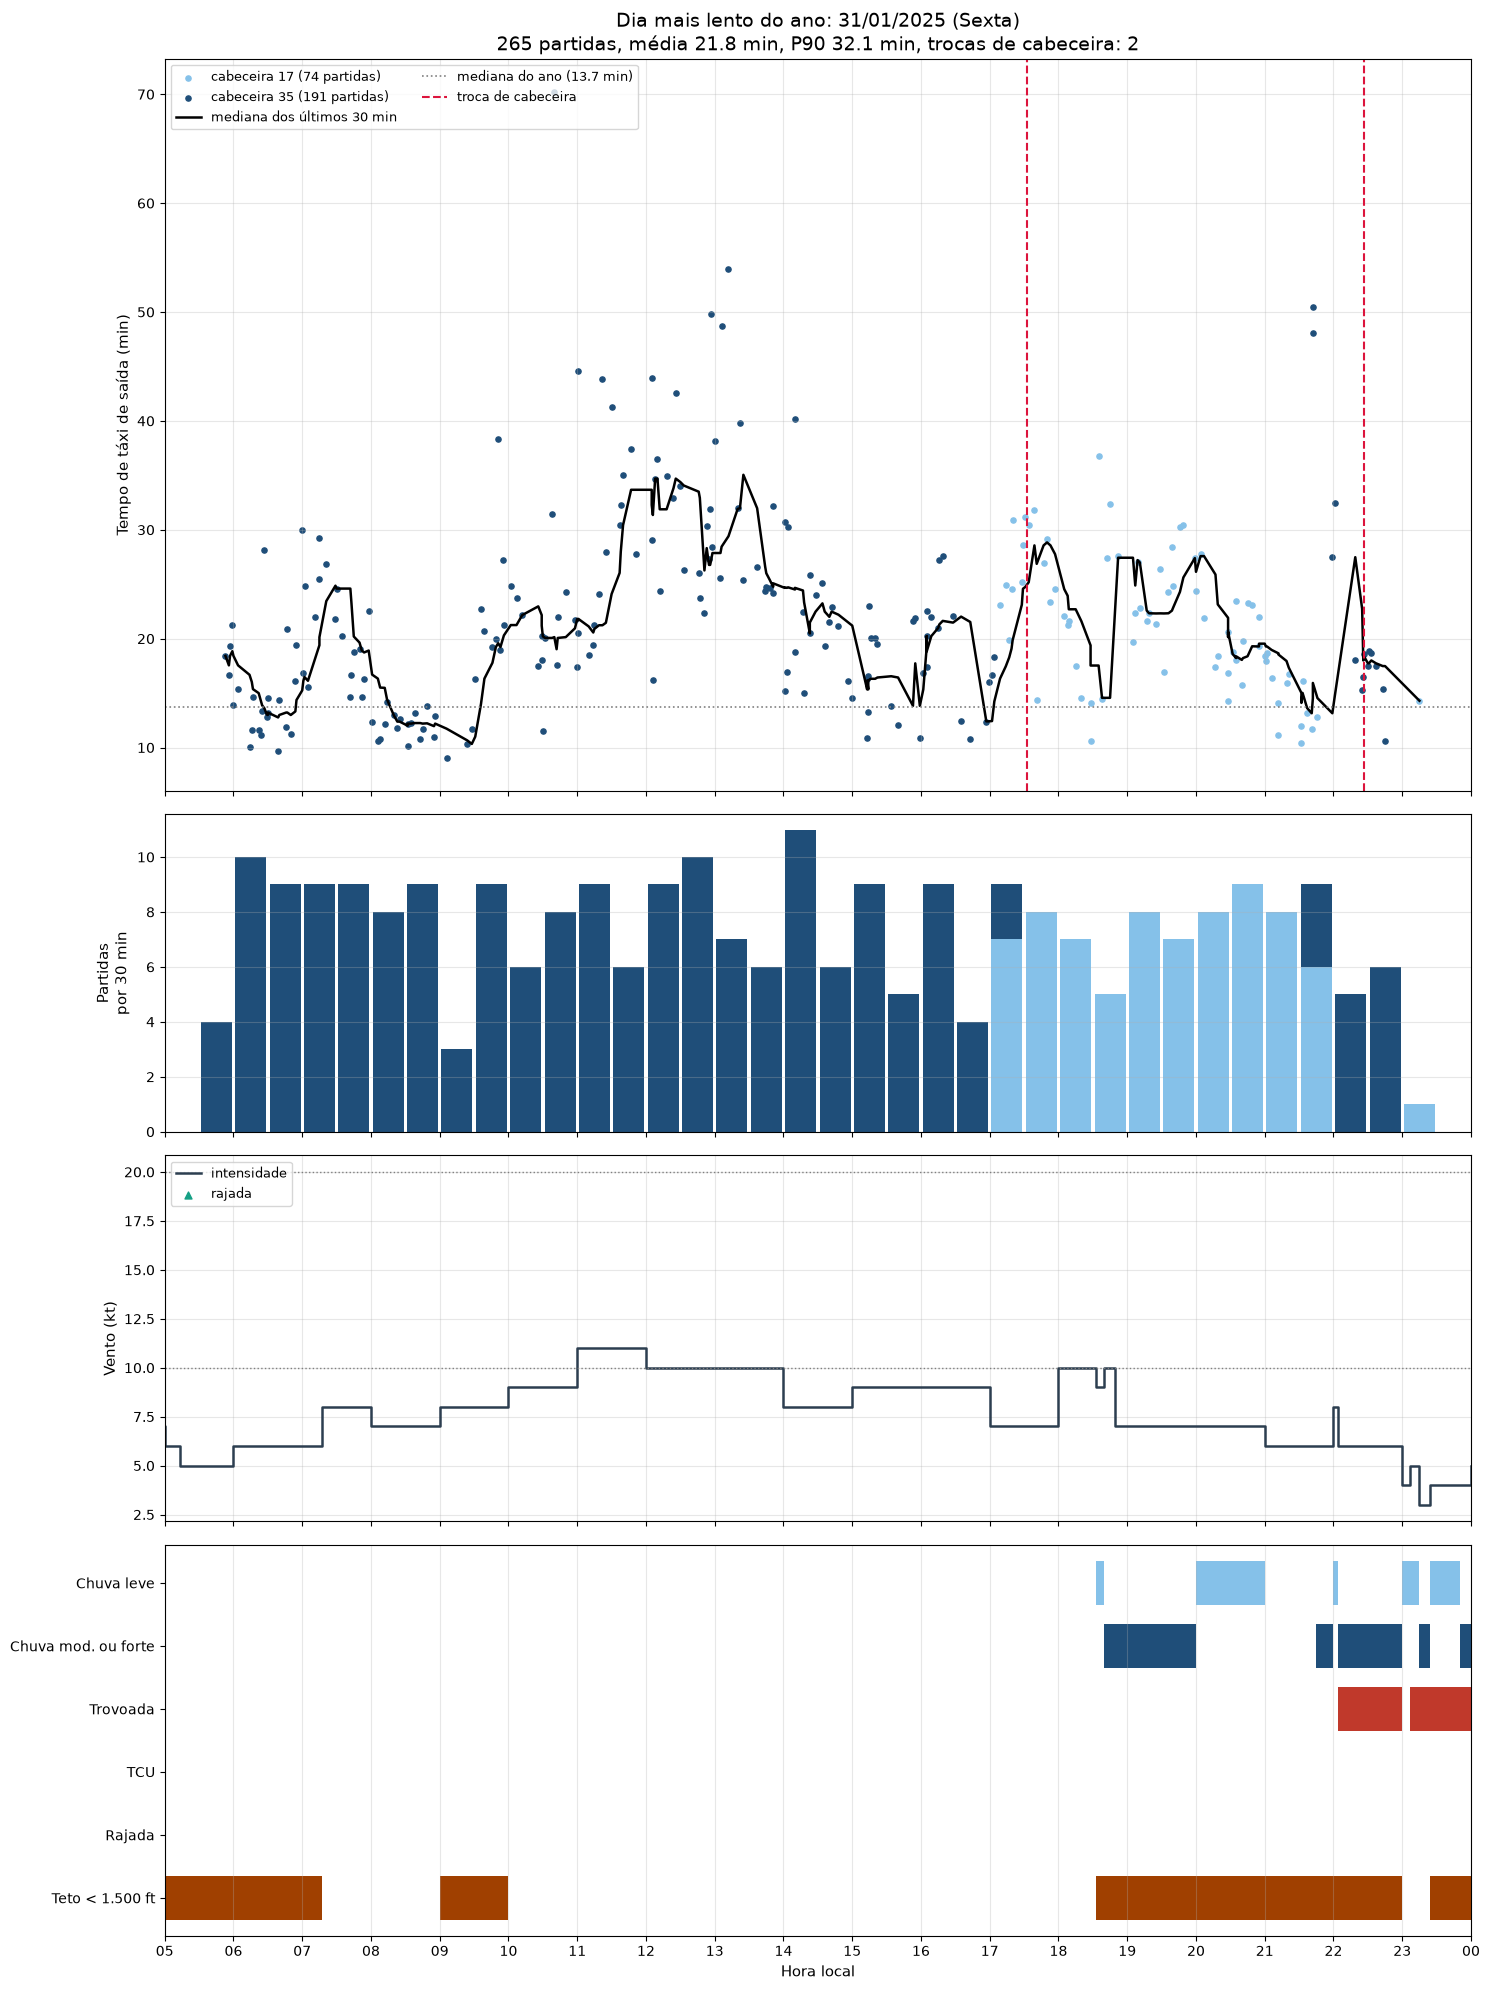

In [68]:
grafico_do_dia(DIA_LENTO, "Dia mais lento do ano")

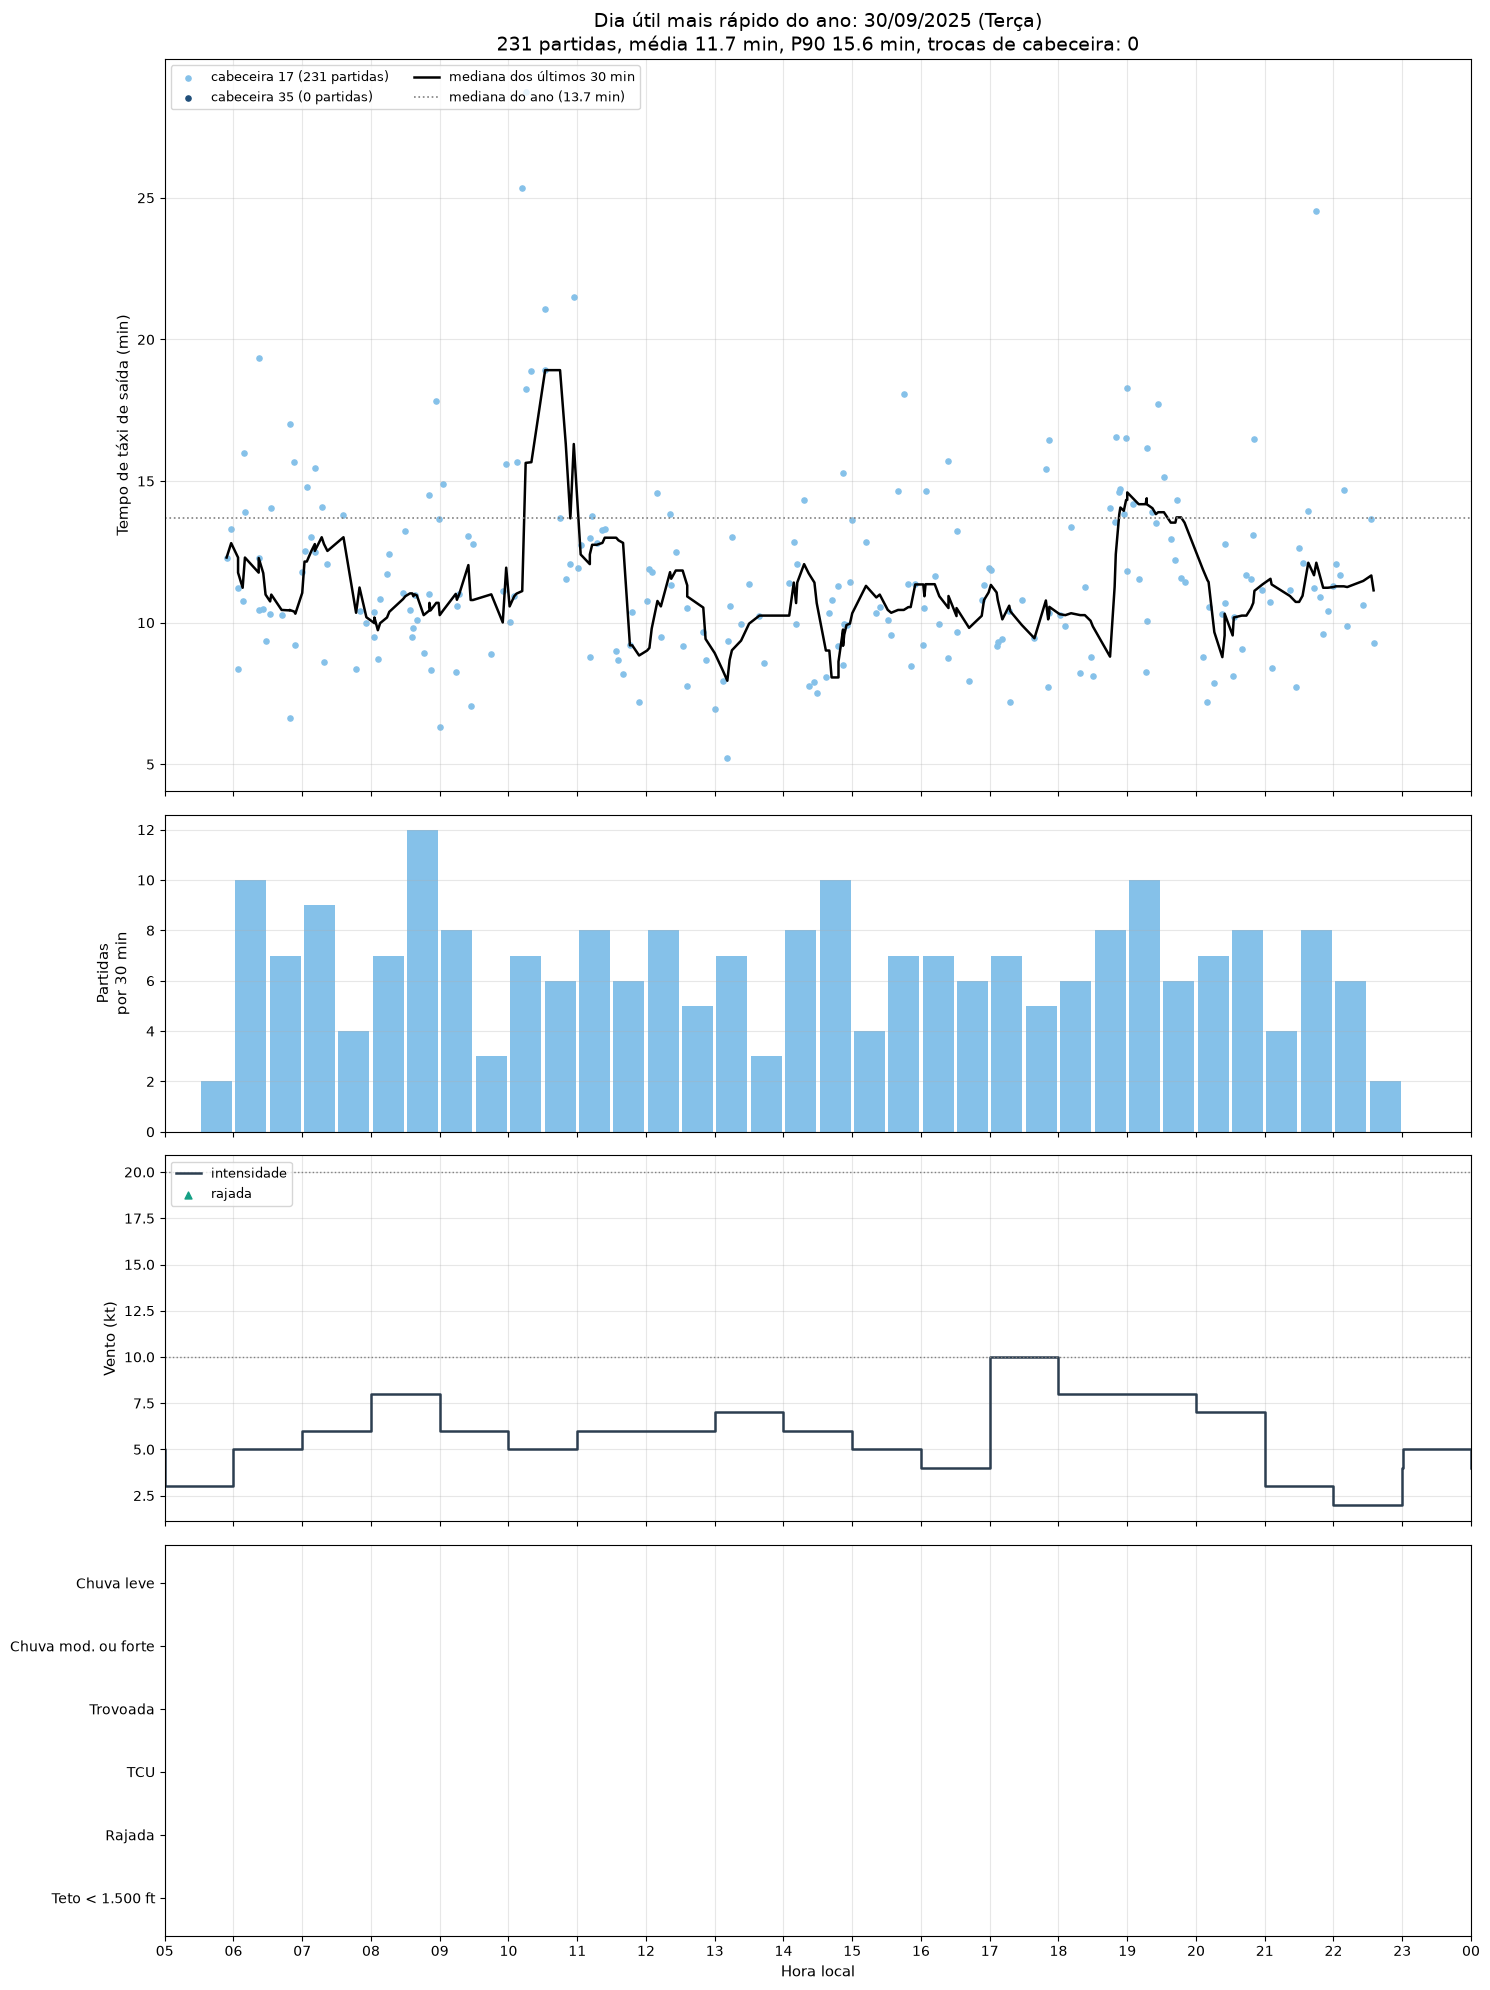

In [69]:
grafico_do_dia(DIA_RAPIDO, "Dia útil mais rápido do ano")

dia sorteado: 2025-11-03 (15.4 min em média)


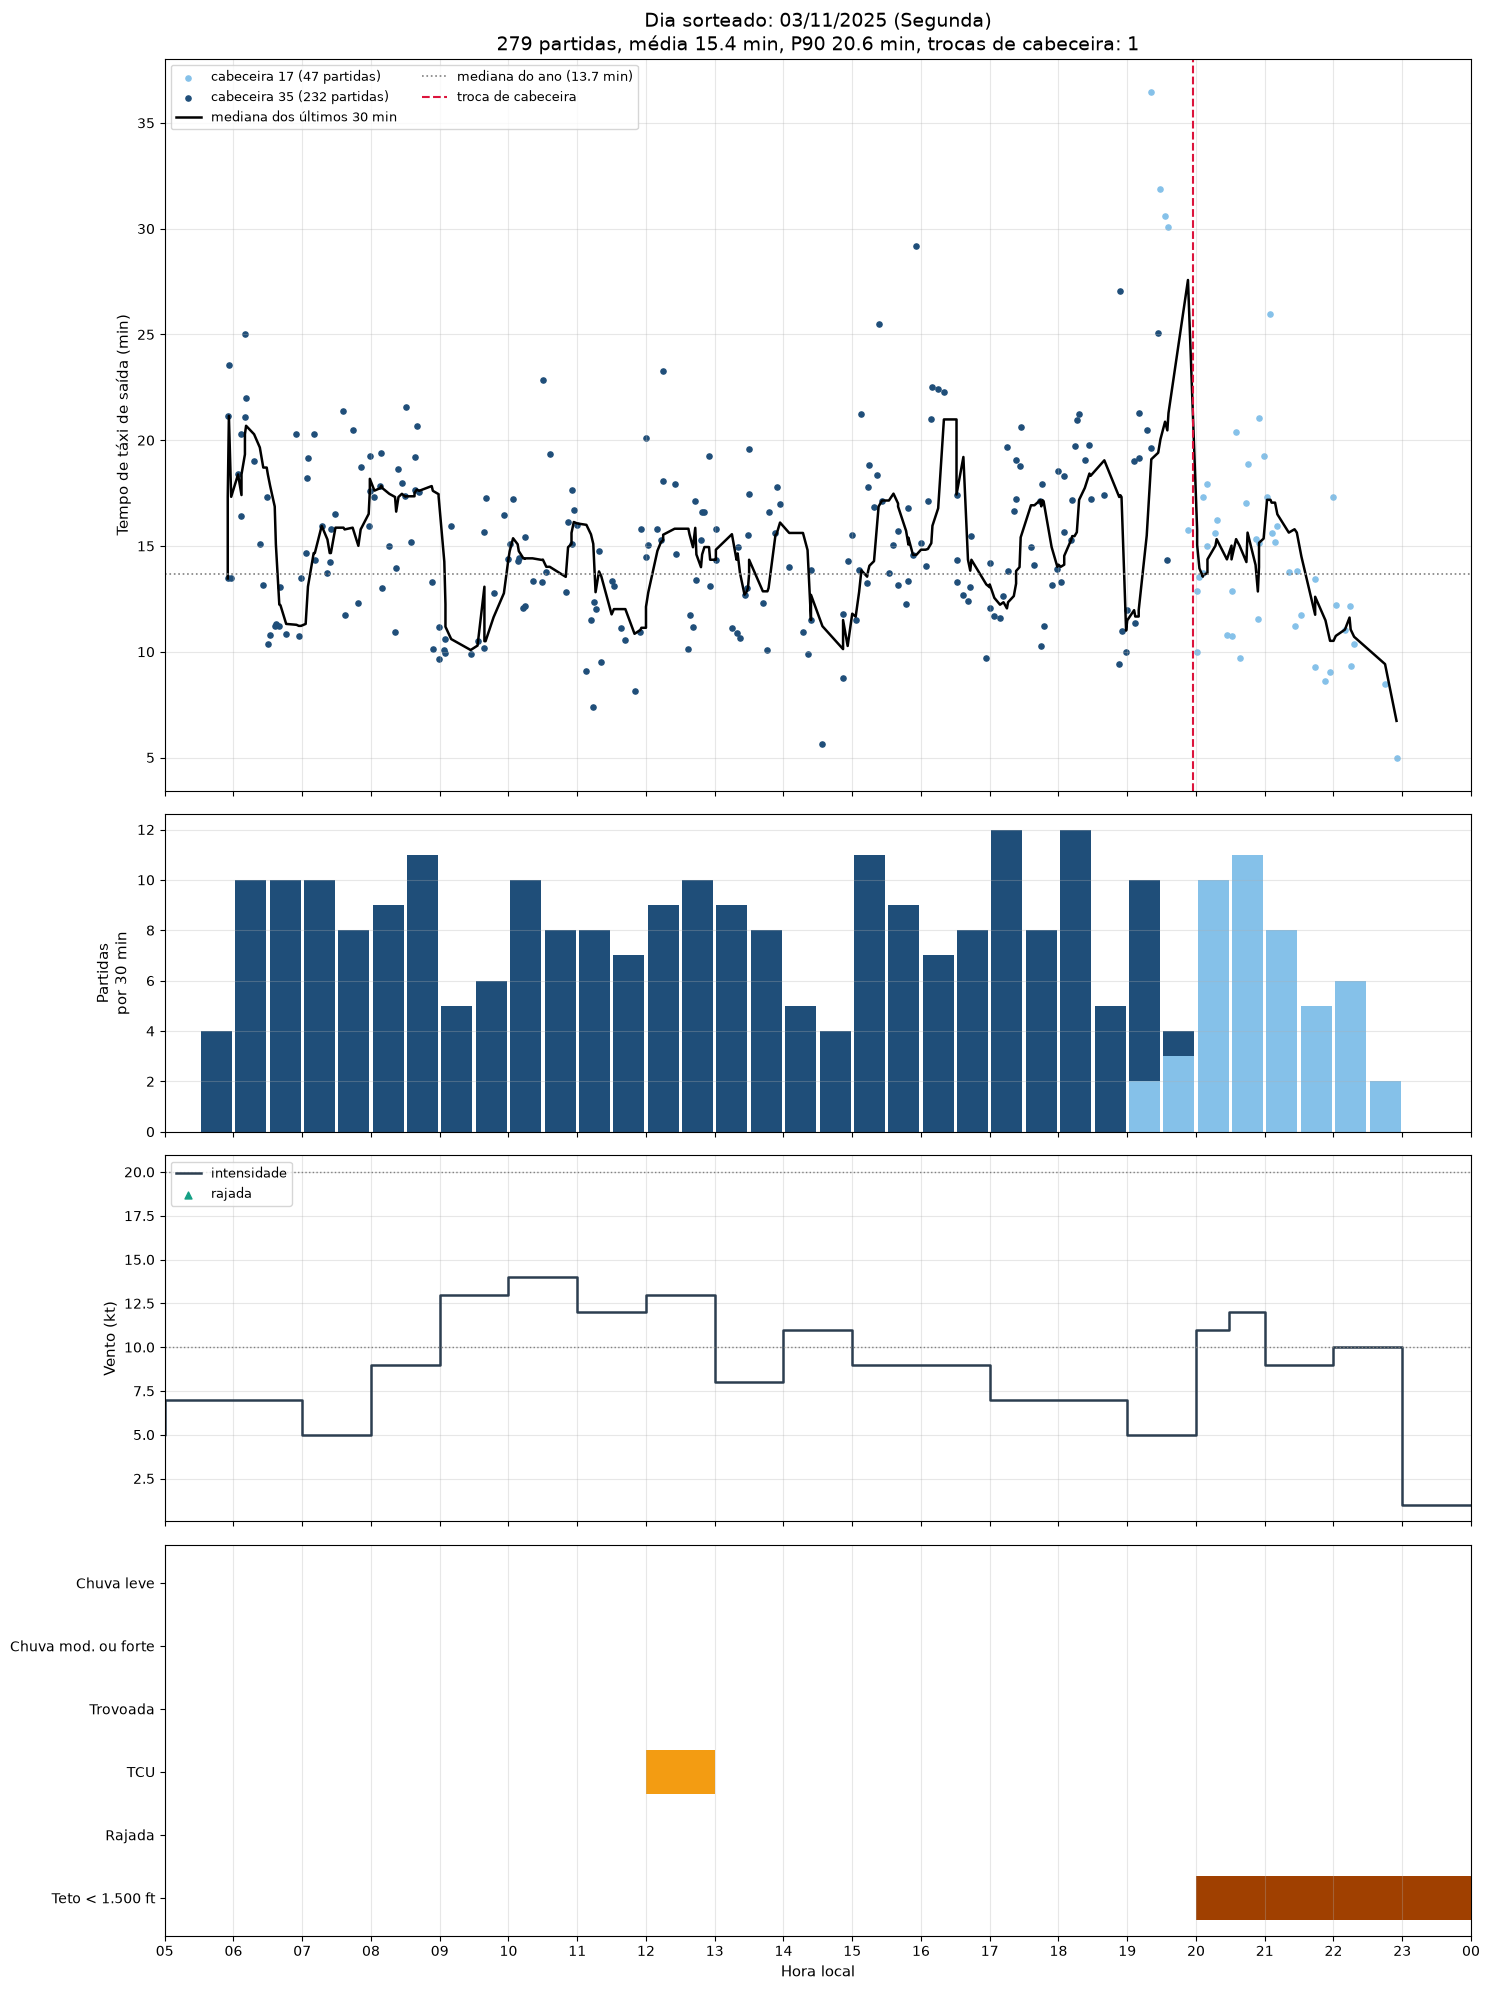

In [70]:
grafico_do_dia(None, "Dia sorteado")